# PSD Parameter Estimation Across an Extended 1D Linear PDE Library — Clean Master


For a linear PDE,
\[
\widehat u(k,t)=\widehat u(k,0)e^{\lambda(k)t},
\qquad
P(k,t)=P(k,0)e^{2\operatorname{Re}\lambda(k)t},
\]
hence for known elapsed time,
\[
\boxed{\operatorname{Re}\lambda(k)=\frac{1}{2t}\log\frac{P(k,t)}{P(k,0)}}.
\]

**Structural-identifiability controls:** advection and third-order dispersion are phase-only; linear loss identifies \(R-\eta\); and SH mixtures can share \(k^2/k^4\) powers with explicit diffusion/hyperdiffusion.

## 0. Imports and run controls

In [1]:
import os, math, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import linregress
from scipy.special import lambertw
from numpy.fft import fft, ifft, fftfreq
from IPython.display import display

import psd_synth.psd_1d as psd_1d_module
CONFIG_PATH=os.path.abspath("configs/default_1d.yaml")
RESULTS_DIR=os.path.join(os.environ.get("PSD_RESULTS_DIR","results"),"1d")
os.makedirs(RESULTS_DIR,exist_ok=True); os.chdir(RESULTS_DIR)
cfg=psd_1d_module.configure(CONFIG_PATH)
from psd_synth.psd_1d import *

np.random.seed(42)
plt.rcParams.update({"figure.dpi":110, "font.size":10})

print("1D grid:", nx, "points; dx =", dx_um, "um")


1D grid: 512 points; dx = 4.8828125 um


## 1. Elementary linear operator library

The nine elementary operators from the original notebook are all retained:

\[
\begin{aligned}
D u_{xx}&\to -Dk^2,\\
-cu_x&\to -ick,\\
-\nu u_{xxxx}&\to -\nu k^4,\\
-\kappa_{\rm SH}(1+\ell^2\partial_{xx})^2u
&\to-\kappa_{\rm SH}(1-\ell^2k^2)^2,\\
-D_f(-\partial_{xx})^{\alpha/2}u&\to-D_f|k|^\alpha,\\
-\beta_3u_{xxx}&\to+i\beta_3k^3,\\
+\mu_6u_{xxxxxx}&\to-\mu_6k^6,\\
-\eta u&\to-\eta,\\
\chi(G_\sigma*u-u)&\to\chi(e^{-\sigma^2k^2/2}-1).
\end{aligned}
\]

In [2]:
print("Elementary operators:", ELEMENTARY_NAMES)


Elementary operators: ['Diff', 'Adv', 'Hyper', 'SH', 'FracDiff', 'Disp', 'Sixth', 'Loss', 'Nonlocal']


## 2. Complete linear model library

In [3]:
assert len(MODEL_VARIANTS) == 53
print("Total first-order linear models:", len(MODEL_VARIANTS))
display(pd.DataFrame([
    {"Tag":tag,"Kind":spec["kind"],"Operators":spec["ops"],"True parameters":spec["true"]}
    for tag,spec in MODEL_LIBRARY.items()
]))


Total first-order linear models: 53


,Tag,Kind,Operators,True parameters
0,R+Diff,elementary,"(Diff,)","{'R': 0.65, 'D': 750.0}"
1,R+Adv,elementary,"(Adv,)","{'R': 0.65, 'c': 120.0}"
2,R+Hyper,elementary,"(Hyper,)","{'R': 0.65, 'nu': 200000.0}"
3,R+SH,elementary,"(SH,)","{'R': 1.25, 'ell': 22.0}"
4,R+FracDiff,elementary,"(FracDiff,)","{'R': 0.65, 'Df': 350.0, 'alpha': 1.5}"
5,R+Disp,elementary,"(Disp,)","{'R': 0.65, 'beta3': 80000.0}"
6,R+Sixth,elementary,"(Sixth,)","{'R': 0.65, 'mu6': 40000000.0}"
7,R+Loss,elementary,"(Loss,)","{'R': 0.65, 'eta': 0.2}"
8,R+Nonlocal,elementary,"(Nonlocal,)","{'R': 0.65, 'chi': 0.8, 'sigma': 45.0}"
9,R+Diff+Adv,pairwise,"(Diff, Adv)","{'R': 0.65, 'D': 750.0, 'c': 120.0}"


## 3. Special models retained from the original notebook

Telegraph and delay equations do not have the same one-branch first-order symbol structure and are therefore kept as special standalone models.

For Telegraph,
\[
u_{tt}+\tau^{-1}u_t=c_T^2u_{xx}+Ru,
\]
\[
\lambda^2+\tau^{-1}\lambda+c_T^2k^2-R=0.
\]

For delay diffusion,
\[
u_t=Ru(t-\tau)+Du_{xx},
\qquad
\lambda=Re^{-\lambda\tau}-Dk^2.
\]

In [4]:
display(pd.DataFrame(SPECIAL_MODELS).T)


,equation,true
R+Telegraph,u_tt + tau^{-1}u_t = cT^2 u_xx + R u,"{'R': 0.5, 'tau': 0.8, 'cT': 90.0}"
R+DelayDiff,u_t = R u(t-tau) + D u_xx,"{'R': 0.5, 'D': 500.0, 'tau': 0.5}"


## 4. Four periodic 1D initial conditions

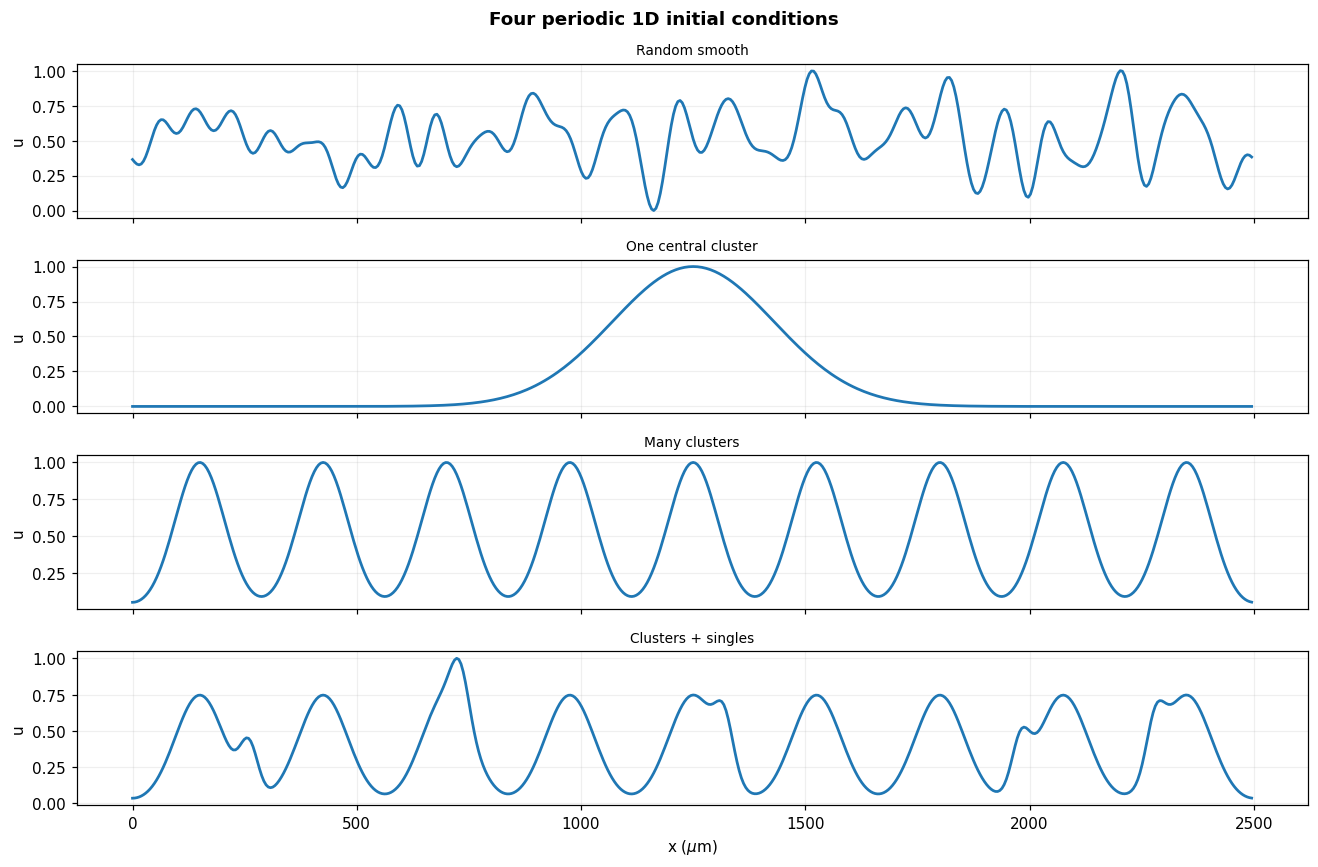

In [5]:
ICs=make_initial_conditions()

fig,axs=plt.subplots(4,1,figsize=(12,8),sharex=True)
for ax,(name,u0) in zip(axs,ICs.items()):
    ax.plot(x,u0,linewidth=1.8)
    ax.set_ylabel("u")
    ax.set_title(name,fontsize=9)
    ax.grid(alpha=.2)
axs[-1].set_xlabel(r"x ($\mu$m)")
fig.suptitle("Four periodic 1D initial conditions",fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Fourier symbols, identifiability, and exact linear solver

In [6]:
# psd_synth/psd_1d.py


## 6. 1D PSD utilities and known-time fitting

In [7]:
# psd_synth/psd_1d.py


## 7. Scenario 3: unknown elapsed time

With unknown \(t\),
\[
y(k)=\log[P_t/P_0]=2t\,\operatorname{Re}\lambda(k),
\]
so absolute rate coefficients are generally known only up to a common scale. The recovery below reports coefficient ratios or shape parameters and explicitly flags SH power-sharing.

For pure SH only, the fixed known \(\kappa_{\rm SH}\) supplies an absolute rate scale. If \(\kappa_{\rm SH}\) were unknown, that absolute-time recovery would no longer be available.

In [8]:
# psd_synth/psd_1d.py


## 8. Scenarios 1–5

In [9]:
# psd_synth/psd_1d.py


## 9. Detailed Scenario 5: 1D segmented reaction–diffusion \(D/R\)

For reaction–diffusion,
\[
u_t=Ru+Du_{xx},
\]
a single segment satisfies
\[
\log_{10}P_i(k,t)
=
\log_{10}P_i(k,0)
+\frac{2Rt}{\ln 10}
-\frac{2Dt}{\ln 10}k^2.
\]

Thus the observed \(k^2\) slope contains both the reaction–diffusion contribution and any local initial-condition spectral slope. Segmentation is therefore an **empirical bias-reduction test**, not a proof that the initial-condition bias averages to zero.

For the synthetic validation below, \(R\) and elapsed time are known, \(D\) is estimated from the local slope, and \(\log_{10}(D/R)\) is reported.

In [10]:
# psd_synth/psd_1d.py


## 10. Run all 53 linear models through all five scenarios

In [11]:
ALL_RESULTS={}
ALL_STACKS={}

for model_index,tag in enumerate(MODEL_VARIANTS,1):
    p=model_parameters(tag)
    print(f"[{model_index:02d}/{len(MODEL_VARIANTS)}] {tag}")

    stacks={ic:simulate_linear(u0,tag,p) for ic,u0 in ICs.items()}
    ALL_STACKS[tag]=stacks

    results={"tag":tag,"true":p,"S1":{},"S2":{},"S3":{},"S4":{},"S5":{}}

    for ic,stack in stacks.items():
        for scen,func in [("S1",scenario1),("S2",scenario2),("S3",scenario3),("S4",scenario4),("S5",scenario5)]:
            try:
                results[scen][ic]=func(stack,tag)
            except Exception as e:
                results[scen][ic]=None
                print("  ",ic,scen,"failed:",type(e).__name__,str(e)[:120])

    ALL_RESULTS[tag]=results

print("Finished",len(ALL_RESULTS),"linear models.")

[01/53] R+Diff


[02/53] R+Adv


[03/53] R+Hyper


[04/53] R+SH


[05/53] R+FracDiff


...

[50/53] R+Diff+Adv+Hyper+SH


[51/53] R+KSlin


[52/53] CHlin


[53/53] R+Mixed


Finished 53 linear models.


## 11. Optional per-model figures

In [12]:
if RUN_PER_MODEL_FIGURES:
    for tag,res in ALL_RESULTS.items():
        stacks=ALL_STACKS[tag]

        fig,axs=plt.subplots(4,1,figsize=(12,9),sharex=True)
        for ax,(ic,stack) in zip(axs,stacks.items()):
            for fid in FRAME_LIST:
                ax.plot(x,stack[fid],linewidth=1,label=f"t={times[fid]:.2f}")
            ax.set_title(ic); ax.set_ylabel("u"); ax.grid(alpha=.2)
        axs[0].legend(ncol=3,fontsize=7)
        axs[-1].set_xlabel(r"x ($\mu$m)")
        fig.suptitle(tag+" — linear evolution",fontweight="bold")
        plt.tight_layout(); plt.show()

        for scen in ("S1","S2","S3","S4"):
            fig,axs=plt.subplots(2,2,figsize=(12,9))
            for ax,(ic,rr) in zip(axs.ravel(),res[scen].items()):
                ax.set_title(ic); ax.grid(alpha=.2)
                if rr is None:
                    ax.text(.5,.5,"failed",ha="center",va="center",transform=ax.transAxes)
                    continue
                if scen in ("S1","S2"):
                    ax.scatter(rr["k"],rr["lambda"],s=12)
                    o=np.argsort(rr["k"]); ax.plot(rr["k"][o],rr["pred"][o],linewidth=2)
                    ax.set_ylabel(r"$\lambda(k)$")
                elif scen=="S3":
                    ax.scatter(rr["k"],rr["y"],s=12)
                    o=np.argsort(rr["k"]); ax.plot(rr["k"][o],rr["pred"][o],linewidth=2)
                    ax.set_ylabel(r"$\log(P_t/P_0)$")
                else:
                    ax.scatter(rr["k"],rr["logP"],s=12)
                    o=np.argsort(rr["k"]); ax.plot(rr["k"][o],rr["pred"][o],linewidth=2)
                    ax.set_ylabel(r"$\log P_{\rm norm}$")
                ax.set_xlabel("k")
            fig.suptitle(f"{tag} — {scen}",fontweight="bold")
            plt.tight_layout(); plt.show()

## 12. Scenario-5 reaction–diffusion segmentation sweep

,Initial condition,Grid,Median log10(D/R),True log10(D/R),Error,Good segments,Total fitted segments
0,Random smooth,2,NaN,3.0621,NaN,0,2
1,Random smooth,4,NaN,3.0621,NaN,0,4
2,Random smooth,6,2.6908,3.0621,-0.3714,1,6
3,Random smooth,8,2.0305,3.0621,-1.0316,3,8
4,Random smooth,10,2.1147,3.0621,-0.9474,3,10
5,Random smooth,12,NaN,3.0621,NaN,0,0
6,Random smooth,16,NaN,3.0621,NaN,0,0
7,One central cluster,2,NaN,3.0621,NaN,0,2
8,One central cluster,4,1.9594,3.0621,-1.1027,2,4
9,One central cluster,6,1.9238,3.0621,-1.1383,2,6


Best segmentation by initial condition:


,Initial condition,Grid,Median log10(D/R),True log10(D/R),Error,Good segments,Total fitted segments,AbsError
0,Clusters + singles,6,2.0623,3.0621,-0.9999,1,6,0.9999
1,One central cluster,10,1.9823,3.0621,-1.0799,10,10,1.0799
2,Random smooth,6,2.6908,3.0621,-0.3714,1,6,0.3714


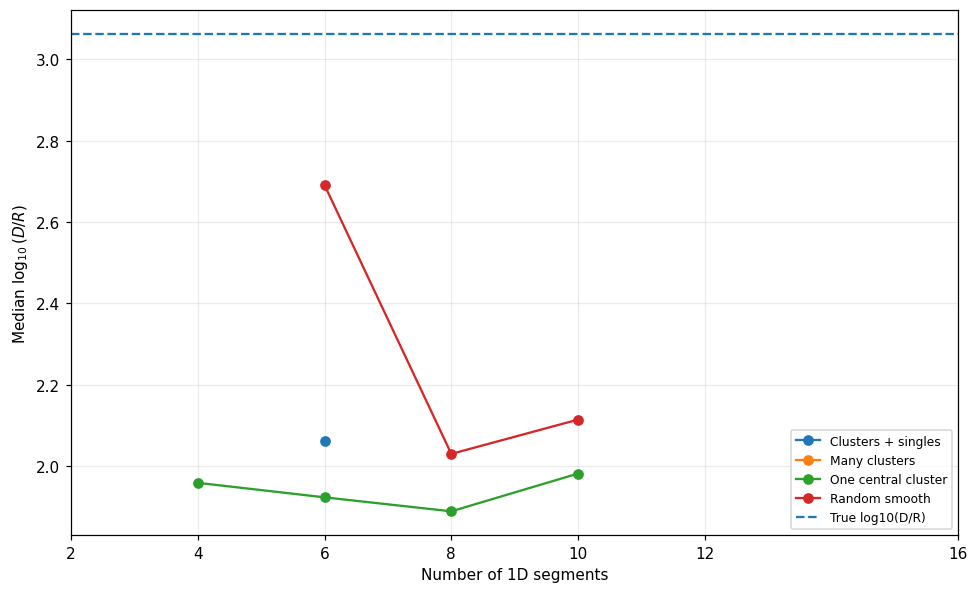

In [13]:
S5_RD_TAG="R+Diff"
R_TRUE=MODEL_LIBRARY[S5_RD_TAG]["true"]["R"]
D_TRUE=MODEL_LIBRARY[S5_RD_TAG]["true"]["D"]
TRUE_LOG10_DR=np.log10(D_TRUE/R_TRUE)
ELAPSED_S5=times[SNAP_FRAME]

rows=[]; S5_RD_DETAILS={}
for ic,stack in ALL_STACKS[S5_RD_TAG].items():
    img=stack[SNAP_FRAME]
    for grid_n in GRID_LIST:
        rr=fit_tiled_RD_1d(img,R_TRUE,ELAPSED_S5,grid_n,R2_MIN)
        S5_RD_DETAILS[(ic,grid_n)]=rr
        rows.append({
            "Initial condition":ic,
            "Grid":grid_n,
            "Median log10(D/R)":np.nan if rr is None else rr["median"],
            "True log10(D/R)":TRUE_LOG10_DR,
            "Error":np.nan if rr is None or not np.isfinite(rr["median"]) else rr["median"]-TRUE_LOG10_DR,
            "Good segments":0 if rr is None else rr["n_good"],
            "Total fitted segments":0 if rr is None else rr["n_total"],
        })

S5_RD_GRID_DF=pd.DataFrame(rows)
display(S5_RD_GRID_DF.round(4))

best=[]
for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    g=grp[np.isfinite(grp["Error"])].copy()
    if len(g):
        g["AbsError"]=np.abs(g["Error"])
        g=g.sort_values(["AbsError","Good segments"],ascending=[True,False])
        best.append(g.iloc[0])
S5_RD_BEST_DF=pd.DataFrame(best).reset_index(drop=True) if best else pd.DataFrame()
print("Best segmentation by initial condition:")
display(S5_RD_BEST_DF.round(4))

fig,ax=plt.subplots(figsize=(9,5.5))
for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    grp=grp.sort_values("Grid")
    ax.plot(grp["Grid"],grp["Median log10(D/R)"],marker="o",label=ic)
ax.axhline(TRUE_LOG10_DR,linestyle="--",linewidth=1.5,label="True log10(D/R)")
ax.set_xlabel("Number of 1D segments")
ax.set_ylabel(r"Median $\log_{10}(D/R)$")
ax.set_xticks(GRID_LIST); ax.grid(alpha=.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 13. Final master summary

In [14]:
MASTER_ROWS=[]
for tag,res in ALL_RESULTS.items():
    for scen in ("S1","S2","S3","S4","S5"):
        for ic in ICs:
            rr=res[scen].get(ic)
            row={
                "PDE":tag,
                "Operators":" + ".join(MODEL_LIBRARY[tag]["ops"]),
                "Scenario":scen,
                "Initial condition":ic,
                "True parameters":fmt_dict(res["true"]),
                "Recovered / metric":"",
                "R2":np.nan,
                "Median abs parameter error (%)":np.nan,
                "Good segments":np.nan,
                "Total segments":np.nan,
                "PSD-invisible":"; ".join(invisible_names(tag)),
                "Status":"",
            }

            if rr is None:
                row["Status"]="failed / unavailable"

            elif scen in ("S1","S2"):
                row["Recovered / metric"]=fmt_dict(rr.get("fit",{}))
                row["R2"]=rr.get("R2",np.nan)
                errs=[]
                for nm,est in rr.get("fit",{}).items():
                    tv=true_identifiable_value(tag,nm)
                    if np.isfinite(tv) and abs(tv)>1e-30:
                        errs.append(abs(relative_error(est,tv)))
                row["Median abs parameter error (%)"]=np.nanmedian(errs) if errs else np.nan
                row["Status"]="known-time PSD-symbol recovery"

            elif scen=="S3":
                row["Recovered / metric"]=fmt_dict(rr.get("recovered",{}))
                row["R2"]=rr.get("R2",np.nan)
                row["Status"]="unknown-time ratio / shape recovery"

            elif scen=="S4":
                row["Recovered / metric"]="shape coefficients="+np.array2string(np.asarray(rr.get("coef",[])),precision=4)
                row["R2"]=rr.get("R2",np.nan)
                row["Status"]="single-snapshot shape diagnostic only"

            elif scen=="S5":
                row["Recovered / metric"]=f"median accepted-segment metric={rr.get('median_metric',np.nan):.5g}"
                row["R2"]=rr.get("median_R2",np.nan)
                row["Good segments"]=rr.get("n_good",np.nan)
                row["Total segments"]=rr.get("n_total",np.nan)
                row["Status"]="segmented regional shape diagnostic"

            MASTER_ROWS.append(row)

MASTER_SUMMARY_DF=pd.DataFrame(MASTER_ROWS)
assert len(MASTER_SUMMARY_DF)==len(MODEL_LIBRARY)*5*len(ICs)

print(f"MASTER SUMMARY: {len(MODEL_LIBRARY)} PDEs x 5 scenarios x {len(ICs)} ICs = {len(MASTER_SUMMARY_DF)} rows")
display(MASTER_SUMMARY_DF)

MASTER_R2_MATRIX=(
    MASTER_SUMMARY_DF
    .pivot_table(index=["PDE","Initial condition"],columns="Scenario",values="R2",aggfunc="first")
    .reindex(columns=["S1","S2","S3","S4","S5"])
)
print("Compact R2 matrix:")
display(MASTER_R2_MATRIX.round(4))

PDE_SCENARIO_MEDIAN_R2=(
    MASTER_SUMMARY_DF
    .groupby(["PDE","Scenario"],as_index=False)["R2"].median()
    .pivot(index="PDE",columns="Scenario",values="R2")
    .reindex(columns=["S1","S2","S3","S4","S5"])
)
print("Median R2 across the four ICs:")
display(PDE_SCENARIO_MEDIAN_R2.round(4))

KNOWN_TIME_ERROR=(
    MASTER_SUMMARY_DF[MASTER_SUMMARY_DF["Scenario"].isin(["S1","S2"])]
    .pivot_table(index=["PDE","Initial condition"],columns="Scenario",
                 values="Median abs parameter error (%)",aggfunc="first")
    .reindex(columns=["S1","S2"])
)
print("Known-time parameter error (%):")
display(KNOWN_TIME_ERROR.round(3))

S3_RECOVERABILITY_DF=pd.DataFrame([
    {"PDE":tag,
     "Recoverable in S3":"; ".join(identifiable_combinations_S3(tag)),
     "PSD-invisible":"; ".join(invisible_names(tag))}
    for tag in MODEL_LIBRARY
])
print("Scenario-3 structural recoverability:")
display(S3_RECOVERABILITY_DF)

MASTER_SUMMARY_DF.to_csv("MASTER2_1D_ALL_PDEs_ALL_5_SCENARIOS_tidy.csv",index=False)
MASTER_R2_MATRIX.to_csv("MASTER2_1D_ALL_PDEs_R2_matrix.csv")
PDE_SCENARIO_MEDIAN_R2.to_csv("MASTER2_1D_PDE_scenario_median_R2.csv")
KNOWN_TIME_ERROR.to_csv("MASTER2_1D_known_time_parameter_error.csv")
S3_RECOVERABILITY_DF.to_csv("MASTER2_1D_S3_recoverability.csv",index=False)
S5_RD_GRID_DF.to_csv("MASTER2_1D_Scenario5_RD_grid_sweep.csv",index=False)
print("Saved all summary CSV files.")

MASTER SUMMARY: 53 PDEs x 5 scenarios x 4 ICs = 1060 rows


,PDE,Operators,Scenario,Initial condition,True parameters,Recovered / metric,R2,Median abs parameter error (%),Good segments,Total segments,PSD-invisible,Status
0,R+Diff,Diff,S1,Random smooth,R=0.65; D=750,R=0.65; D=750,1.000000,3.803544e-13,NaN,NaN,,known-time PSD-symbol recovery
1,R+Diff,Diff,S1,One central cluster,R=0.65; D=750,R=0.6517; D=751.39,0.999991,2.233941e-01,NaN,NaN,,known-time PSD-symbol recovery
2,R+Diff,Diff,S1,Many clusters,R=0.65; D=750,R=0.65; D=750,1.000000,3.974476e-09,NaN,NaN,,known-time PSD-symbol recovery
3,R+Diff,Diff,S1,Clusters + singles,R=0.65; D=750,R=0.65; D=750,1.000000,6.867304e-13,NaN,NaN,,known-time PSD-symbol recovery
4,R+Diff,Diff,S2,Random smooth,R=0.65; D=750,R=0.65; D=750,1.000000,2.237481e-13,NaN,NaN,,known-time PSD-symbol recovery
...,...,...,...,...,...,...,...,...,...,...,...,...
1055,R+Mixed,Diff + Adv + Disp + Hyper,S4,Clusters + singles,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,shape coefficients=[ 1.1902e+05 -6.4520e+03 8...,0.963841,NaN,NaN,NaN,c; beta3,single-snapshot shape diagnostic only
1056,R+Mixed,Diff + Adv + Disp + Hyper,S5,Random smooth,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,median accepted-segment metric=-604.36,0.943285,NaN,5.0,8.0,c; beta3,segmented regional shape diagnostic
1057,R+Mixed,Diff + Adv + Disp + Hyper,S5,One central cluster,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,median accepted-segment metric=-384.39,0.951665,NaN,8.0,8.0,c; beta3,segmented regional shape diagnostic
1058,R+Mixed,Diff + Adv + Disp + Hyper,S5,Many clusters,R=0.65; D=500; c=120; beta3=80000; nu=1e+05,median accepted-segment metric=-873.24,0.841909,NaN,7.0,8.0,c; beta3,segmented regional shape diagnostic


Compact R2 matrix:


Scenario                                  S1      S2      S3      S4      S5
PDE              Initial condition                                          
CHlin            Clusters + singles   1.0000  1.0000  1.0000  0.9372  0.9276
                 Many clusters        1.0000  1.0000  1.0000  0.9487  0.8584
                 One central cluster  1.0000  1.0000  1.0000  0.8502  0.9523
                 Random smooth        1.0000  1.0000  1.0000  0.9309  0.9475
R+Adv            Clusters + singles      NaN     NaN  0.0000  0.0000     NaN
...                                      ...     ...     ...     ...     ...
R+Sixth+Loss     Random smooth        1.0000  1.0000  1.0000  0.9370  0.9556
R+Sixth+Nonlocal Clusters + singles   1.0000  1.0000  0.9989  0.9454  0.9404
                 Many clusters        1.0000  1.0000  0.9989  0.9467  0.9369
                 One central cluster  0.9677  0.9706  0.9707  0.9250  0.9847
                 Random smooth        1.0000  1.0000  0.9989  0.9385  0.9489

[212 rows x 5 columns]

Median R2 across the four ICs:


...

Known-time parameter error (%):


Scenario                                  S1      S2
PDE              Initial condition                  
CHlin            Clusters + singles    0.000   0.000
                 Many clusters         0.000   0.000
                 One central cluster   0.128   0.099
                 Random smooth         0.000   0.000
R+Adv            Clusters + singles    0.000   0.000
...                                      ...     ...
R+Sixth+Loss     Random smooth         0.000   0.000
R+Sixth+Nonlocal Clusters + singles    0.000   0.000
                 Many clusters         0.000   0.000
                 One central cluster  62.421  60.068
                 Random smooth         0.000   0.000

[212 rows x 2 columns]

Scenario-3 structural recoverability:


,PDE,Recoverable in S3,PSD-invisible
0,R+Diff,D/(R),
1,R+Adv,nothing: constant-only real symbol,c
2,R+Hyper,nu/(R),
3,R+SH,ell; R; 2*dt (requires known fixed kappa_SH),
4,R+FracDiff,alpha; Df/(R),
5,R+Disp,nothing: constant-only real symbol,beta3
6,R+Sixth,mu6/(R),
7,R+Loss,nothing: constant-only real symbol,
8,R+Nonlocal,sigma; chi/(R),
9,R+Diff+Adv,D/(R),c


Saved all summary CSV files.


## 14. Interpretation notes

- **S1:** full time series recovers \(\mathrm{Re}\lambda(k)\) from temporal slopes.
- **S2:** two known-time frames recover \(\mathrm{Re}\lambda(k)\) from the PSD ratio.
- **S3:** unknown elapsed time generally leaves coefficient ratios and shape parameters.
- **Advection:** \(c\) is phase-only and cannot be recovered from PSD magnitude.
- **Third-order dispersion:** \(\beta_3\) is also phase-only.
- **Linear loss:** only \(R-\eta\) is visible to the linear PSD.
- **SH:** \(\kappa_{\rm SH}=1\) is treated as known. If it is unknown, absolute-time recovery from pure SH is no longer valid.
- **SH mixtures:** explicit diffusion and hyperdiffusion share the SH \(k^2/k^4\) powers; effective coefficients are reported when primitives are not structurally separable.
- **S4:** an arbitrary single snapshot is a spectral-shape diagnostic, not absolute parameter recovery.
- **S5:** segmentation is an empirical regional-bias-reduction approach. Accepted-segment summaries use only segments with \(R^2\ge0.80\).
- **Cross-scenario \(R^2\):** S1–S3, S4, and S5 fit different statistical objects; their \(R^2\) values should not be interpreted as identical measures of identifiability.


# 14. Complete five-scenario plotting for every PDE

This section adds the missing visualization layer. For every PDE, it generates a compact **five-scenario summary figure** across all four initial conditions.

The five panels are interpreted differently:

- **S1:** full-time-series recovery of \(\mathrm{Re}\lambda(k)\)
- **S2:** two-frame, known-time recovery of \(\mathrm{Re}\lambda(k)\)
- **S3:** unknown-time identifiable ratios / shape recovery
- **S4:** single-snapshot spectral-shape diagnostic
- **S5:** 1D segmented regional diagnostic using only accepted segments in the summary

The \(R^2\) values are shown for fit quality, but they should not be interpreted as identical statistical quantities across all five scenarios.


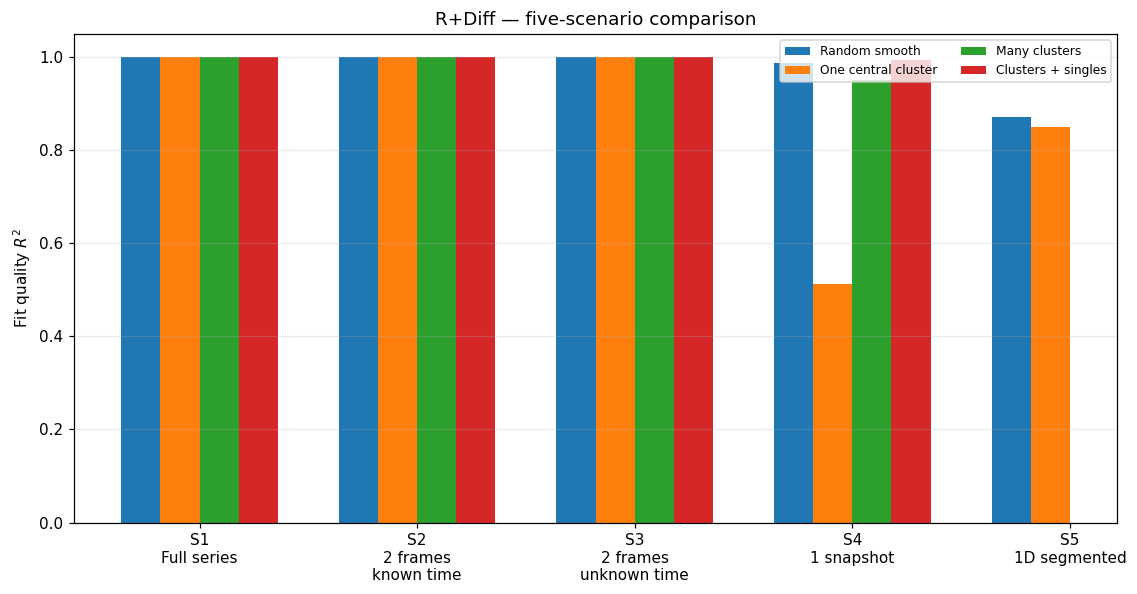

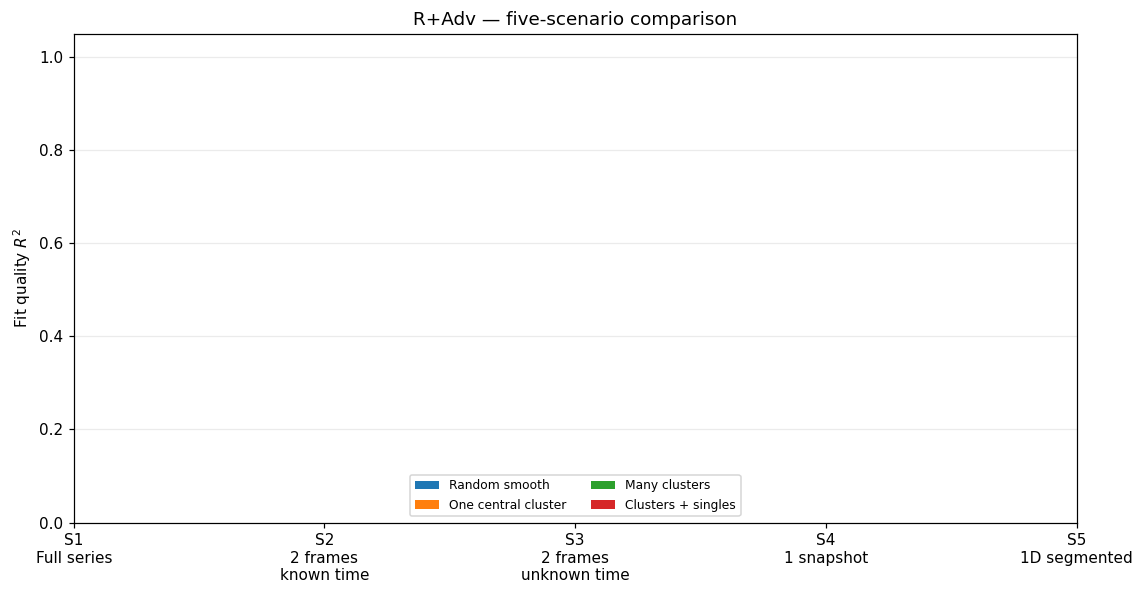

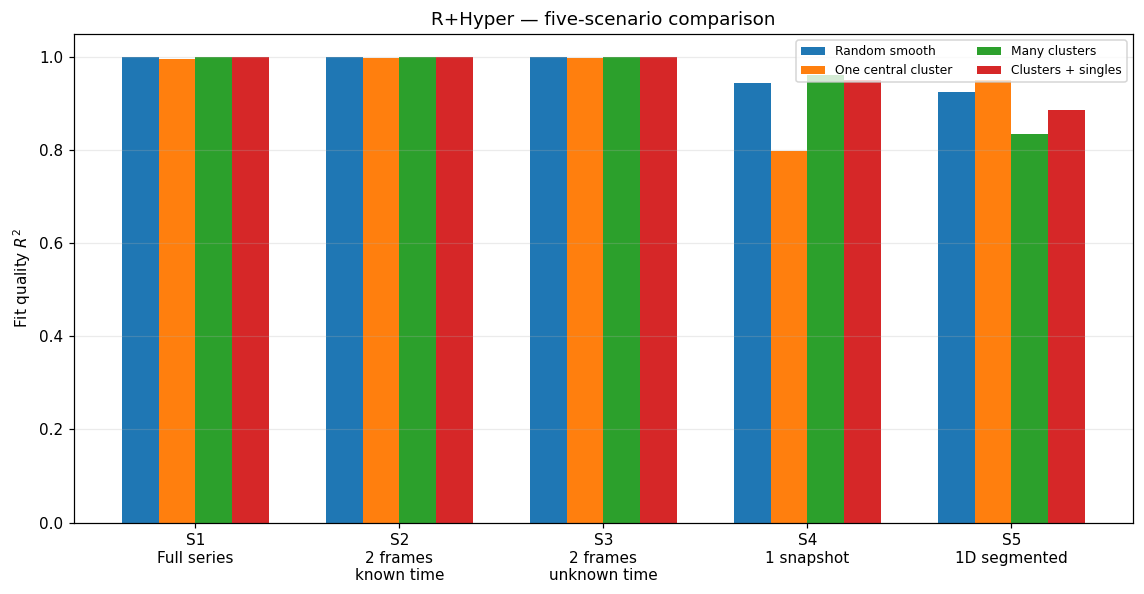

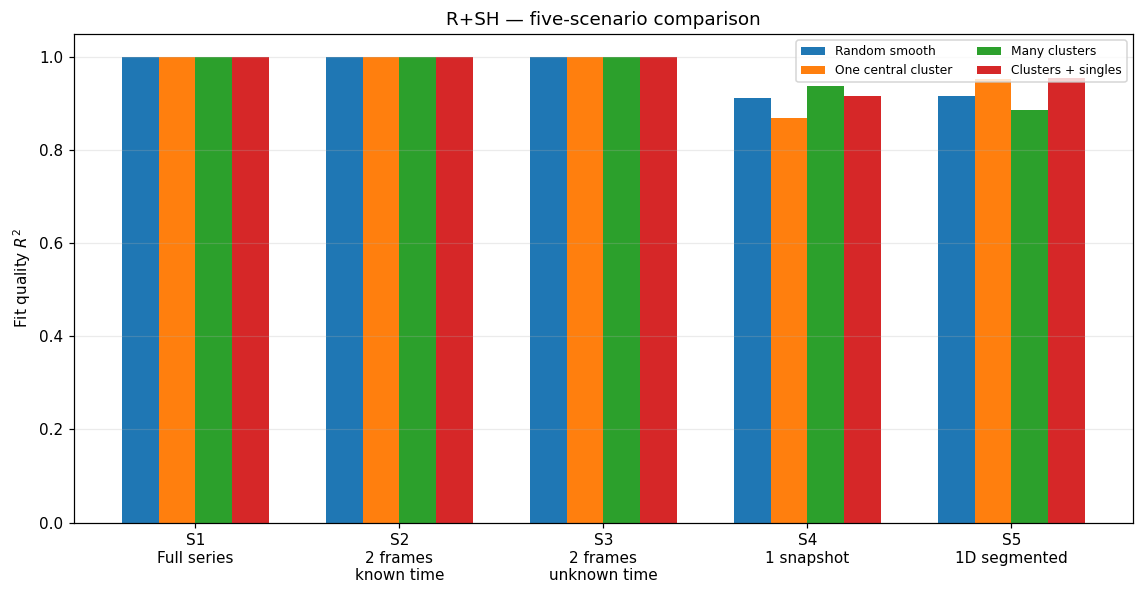

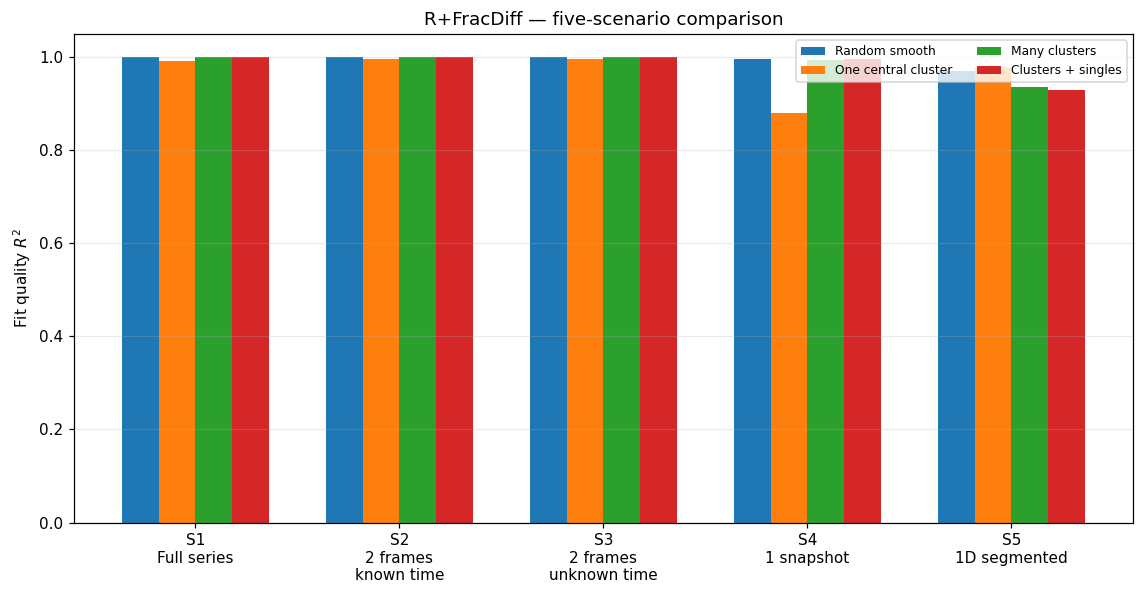

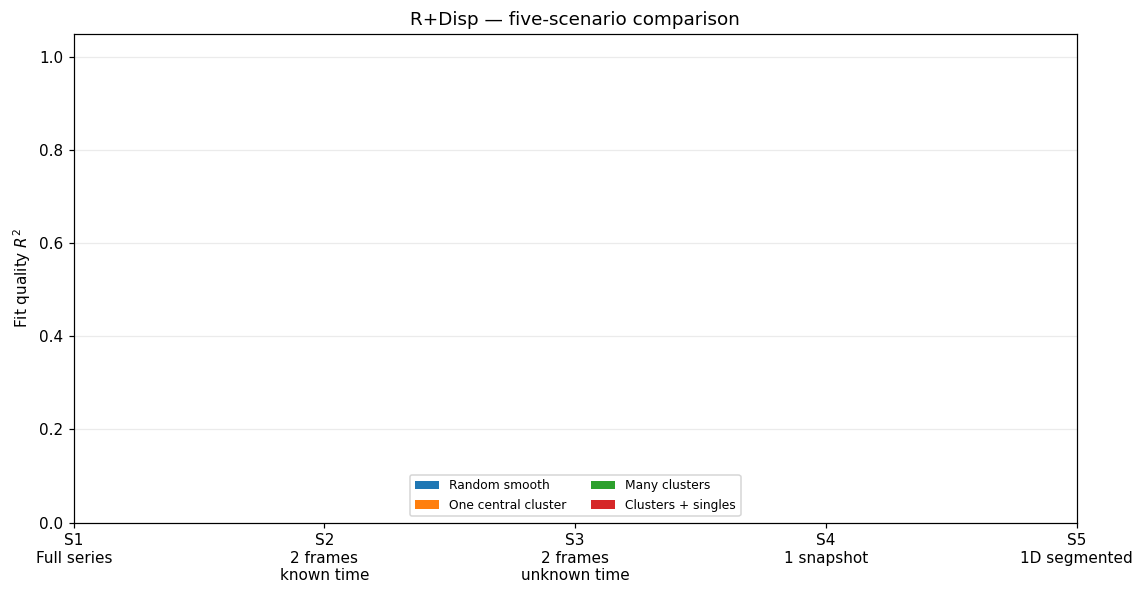

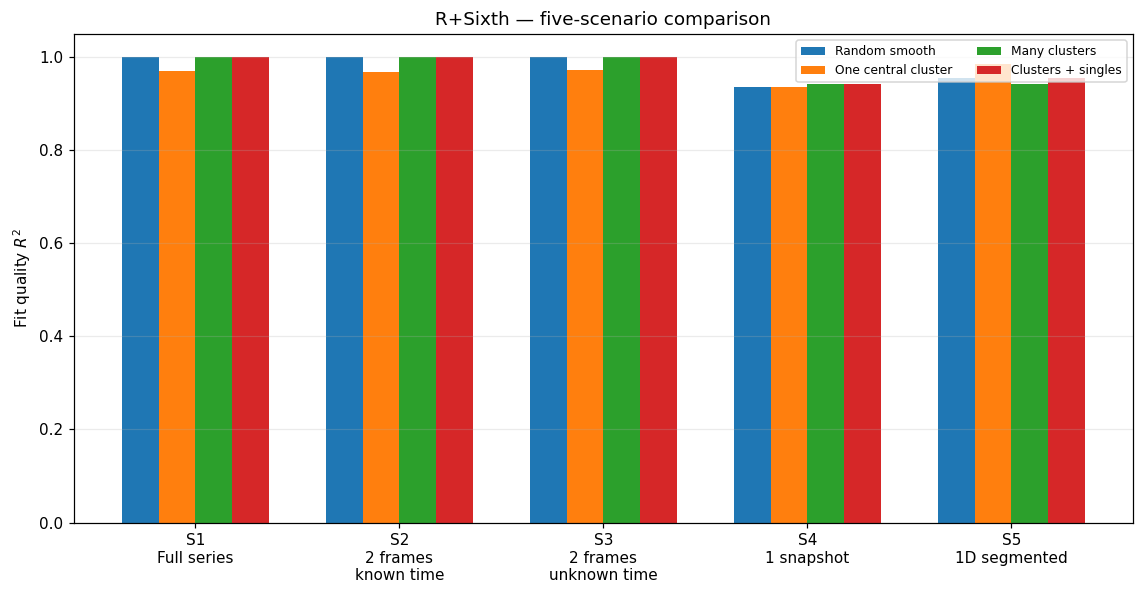

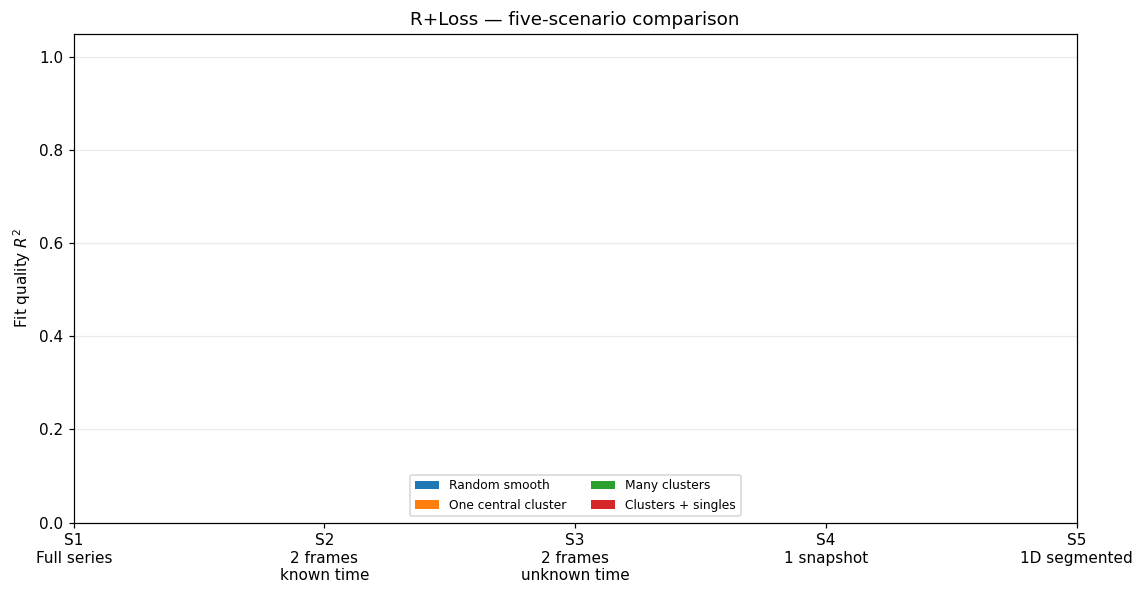

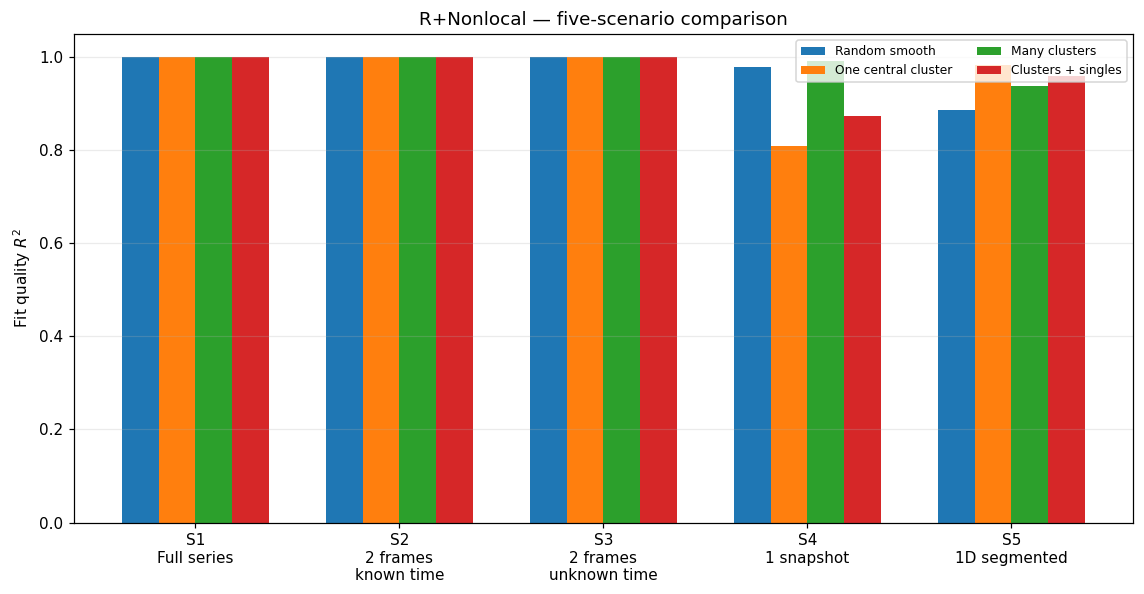

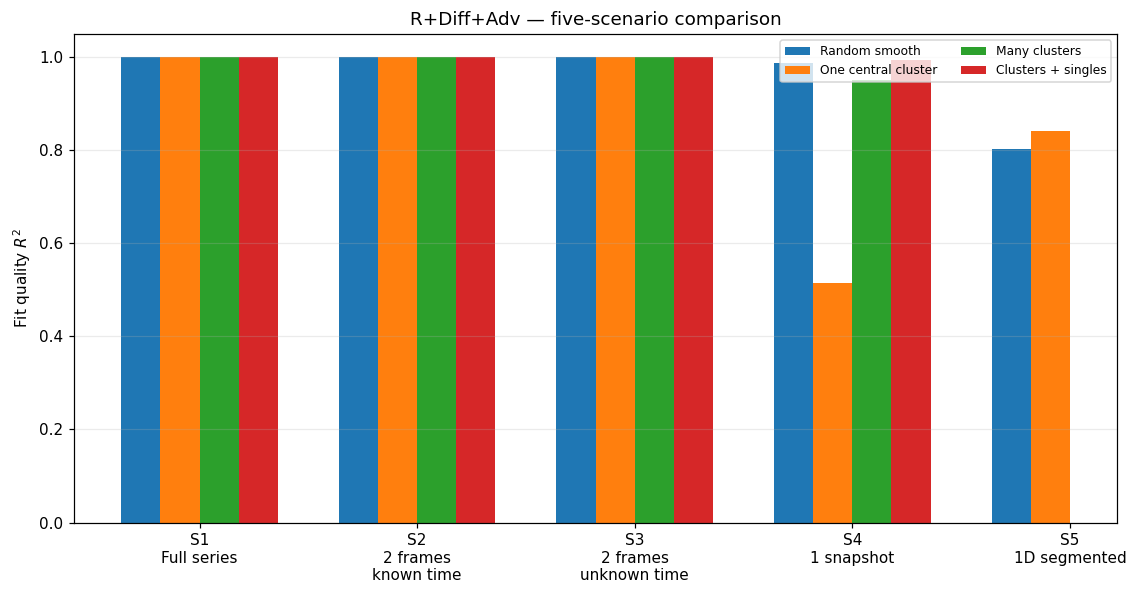

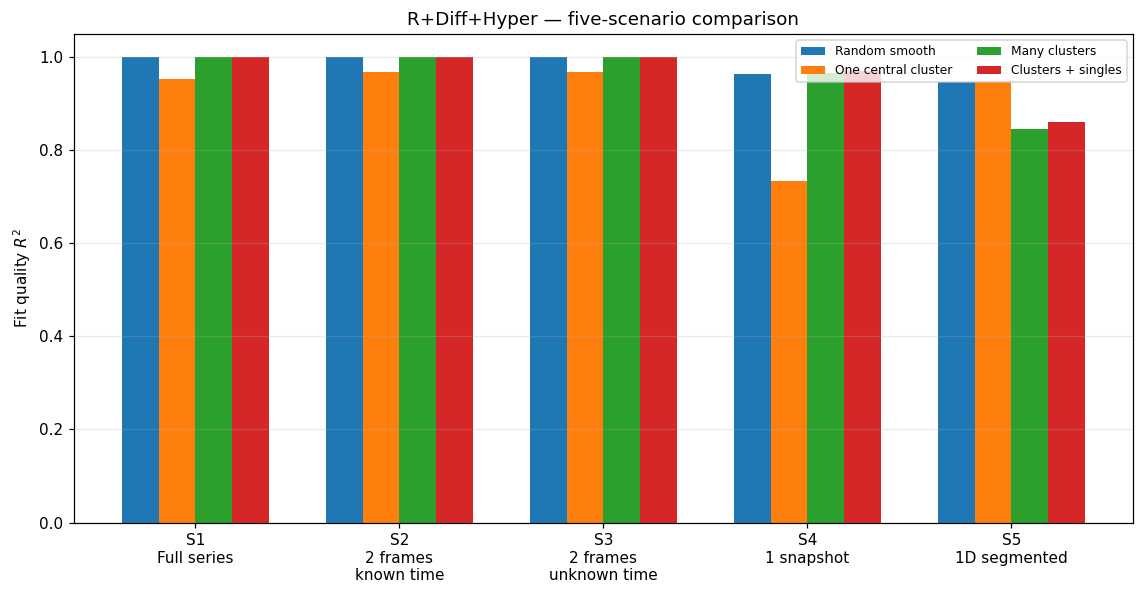

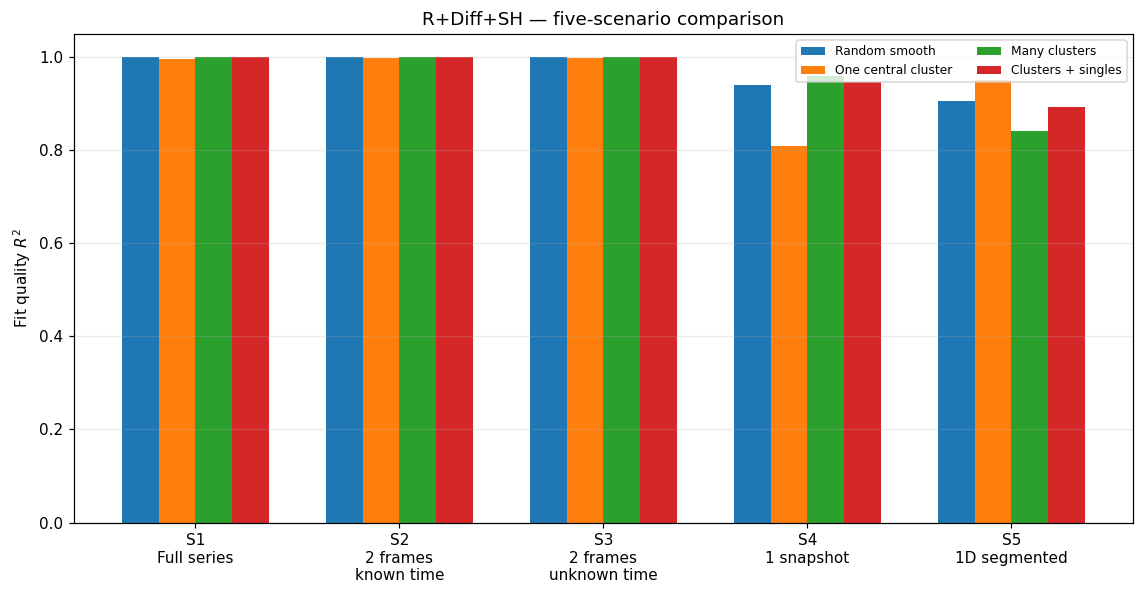

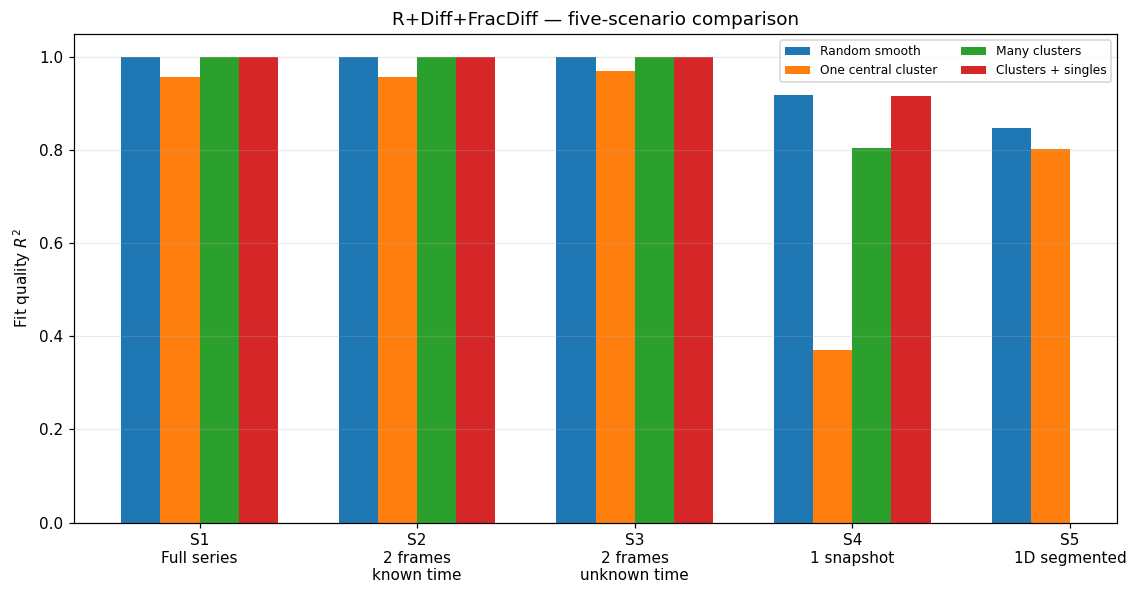

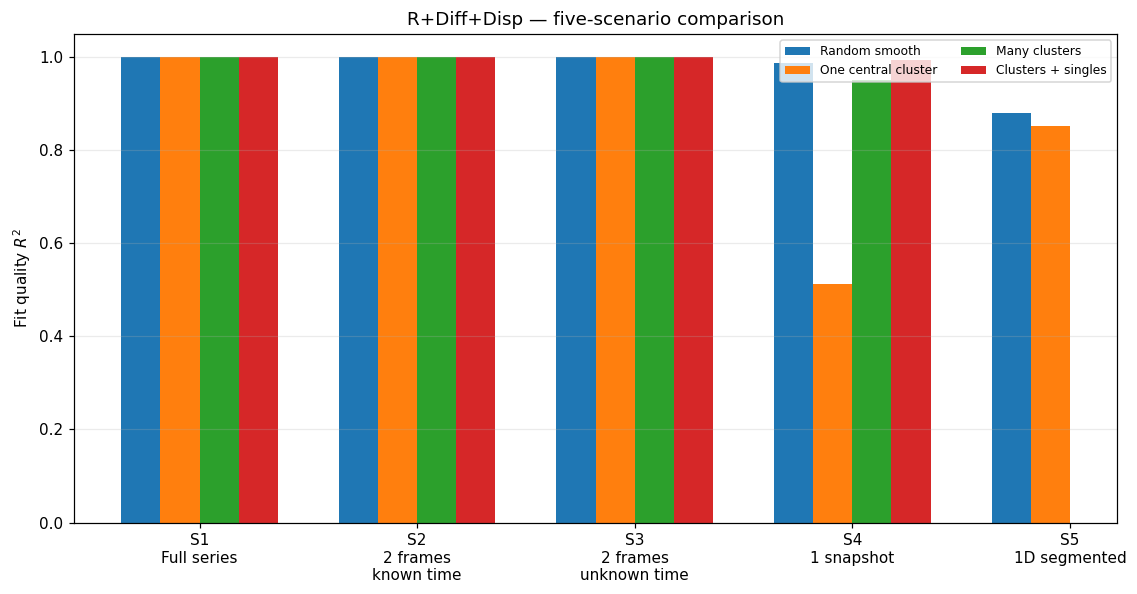

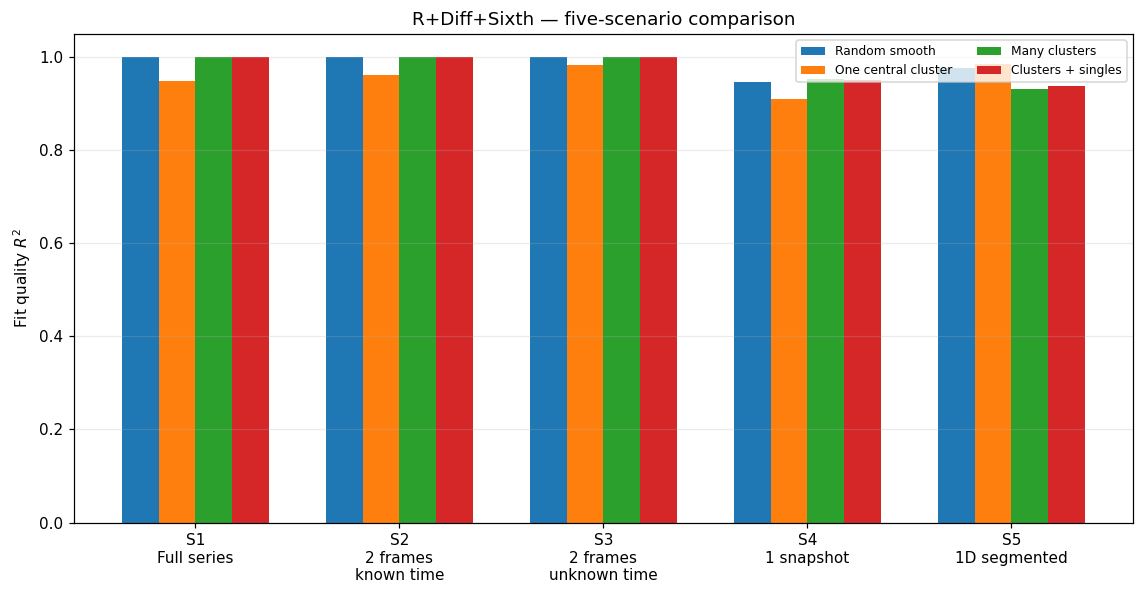

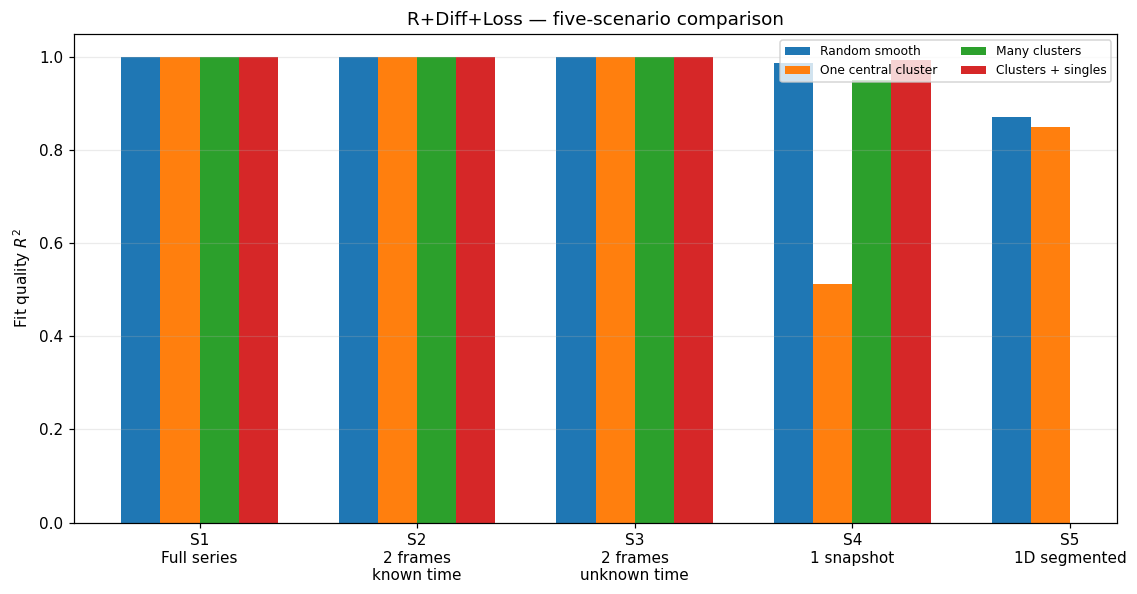

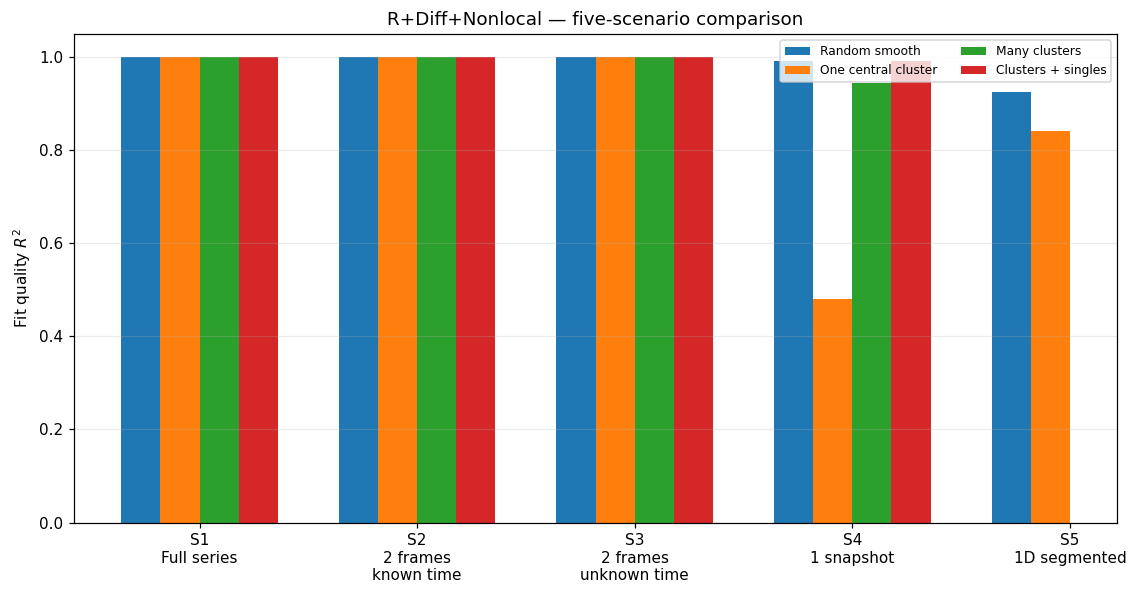

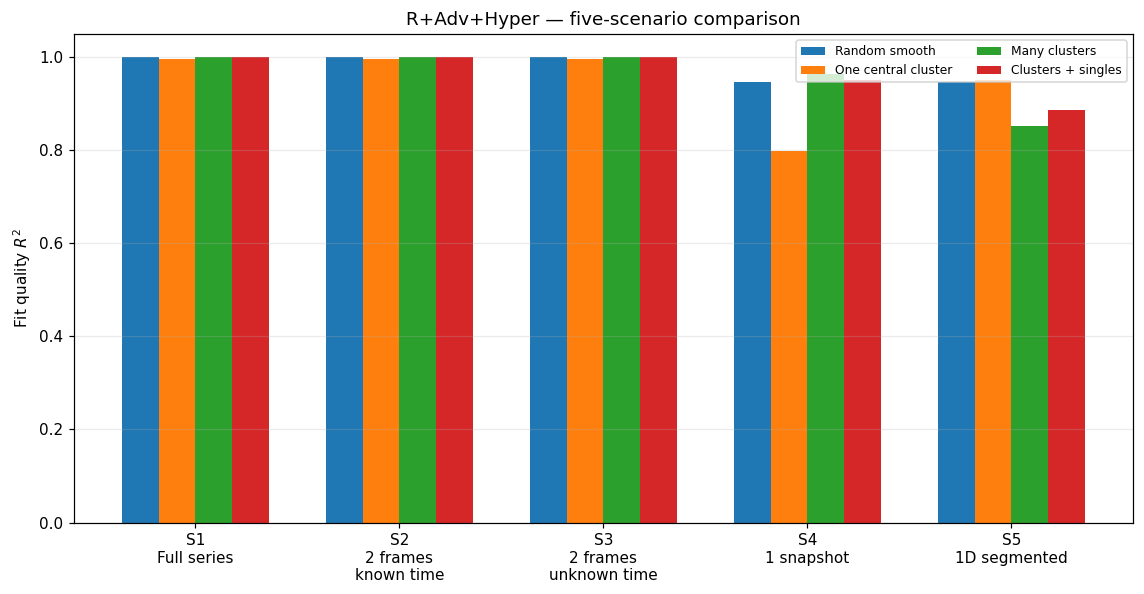

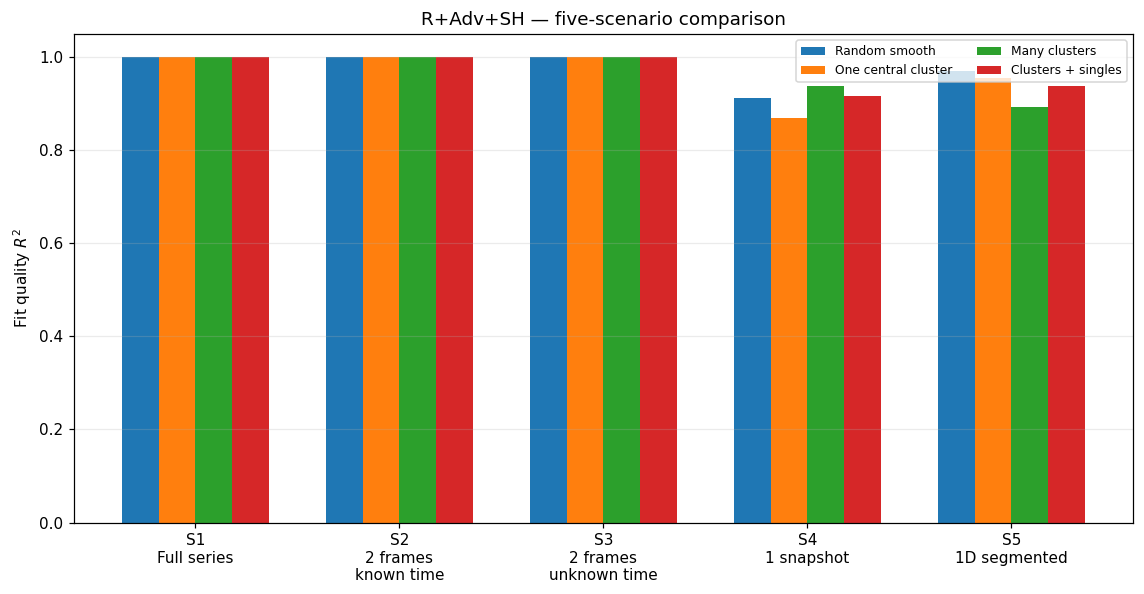

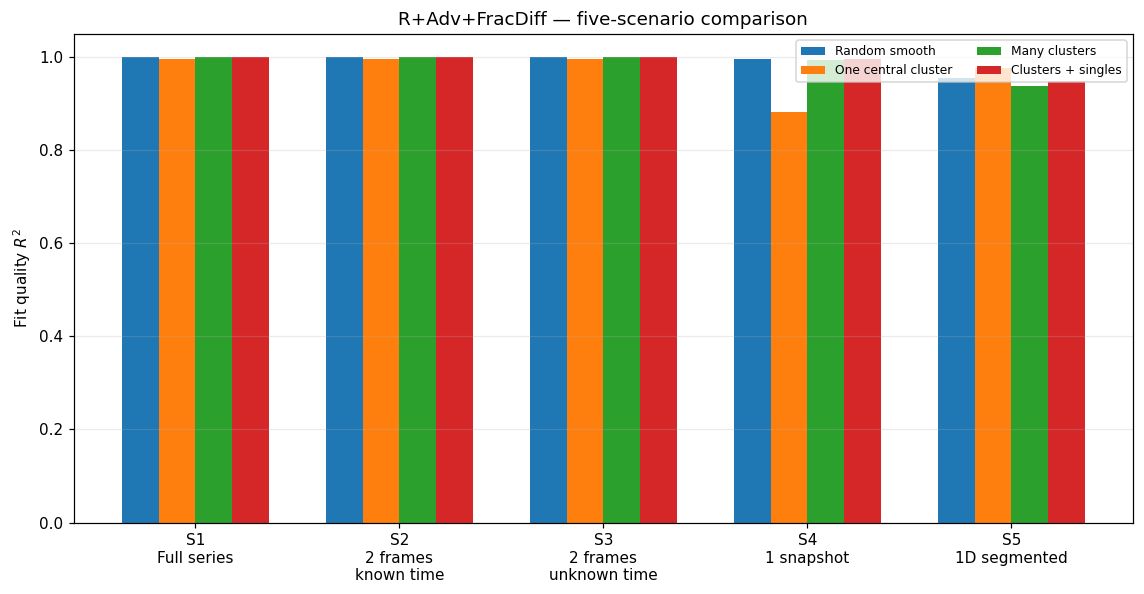

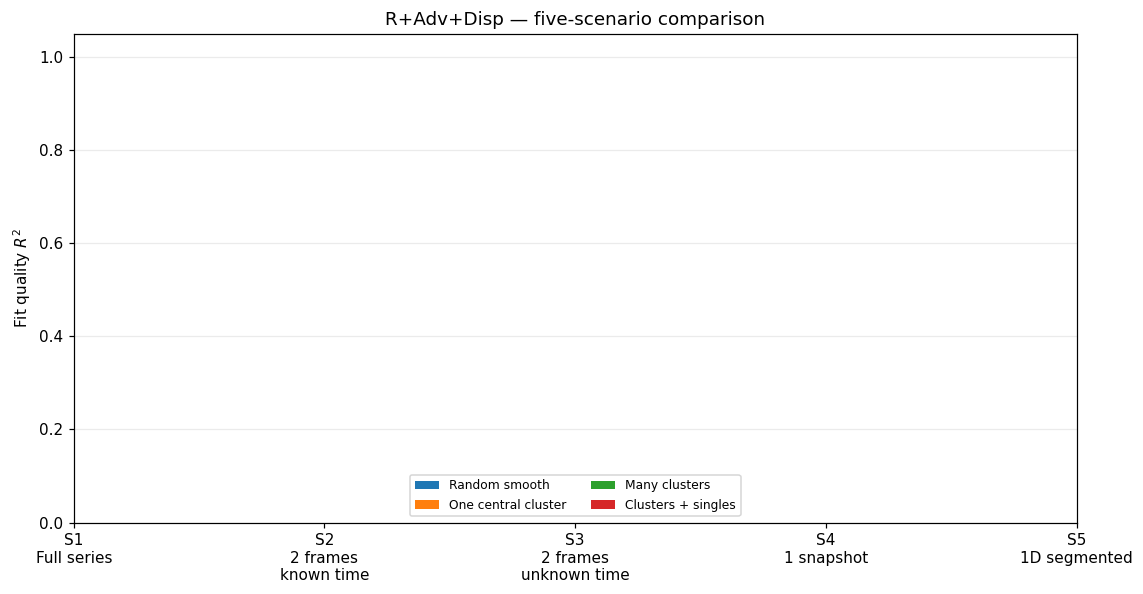

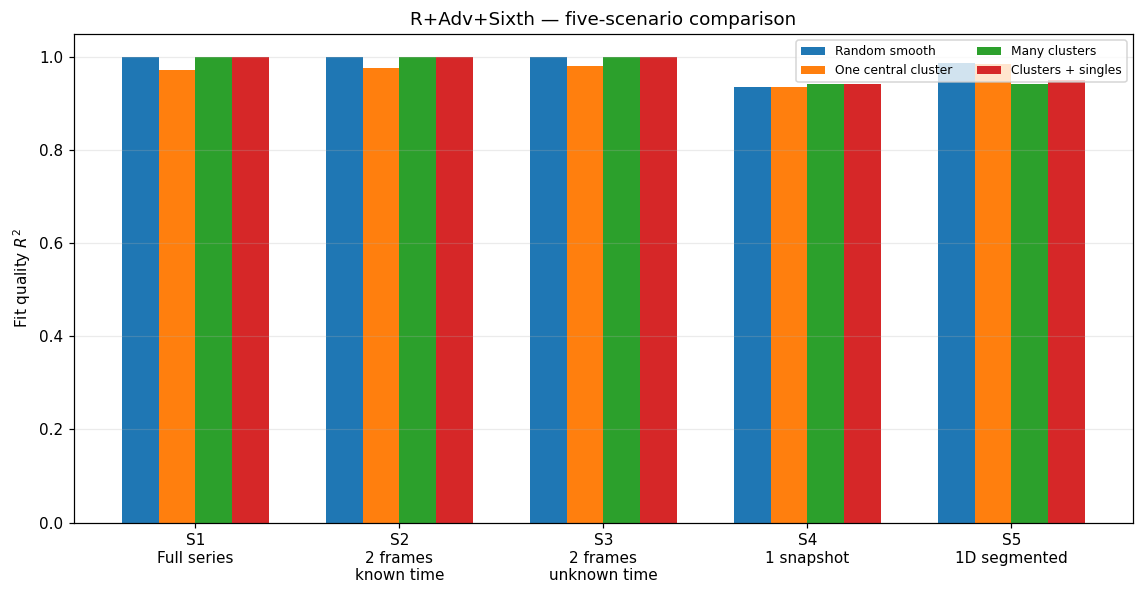

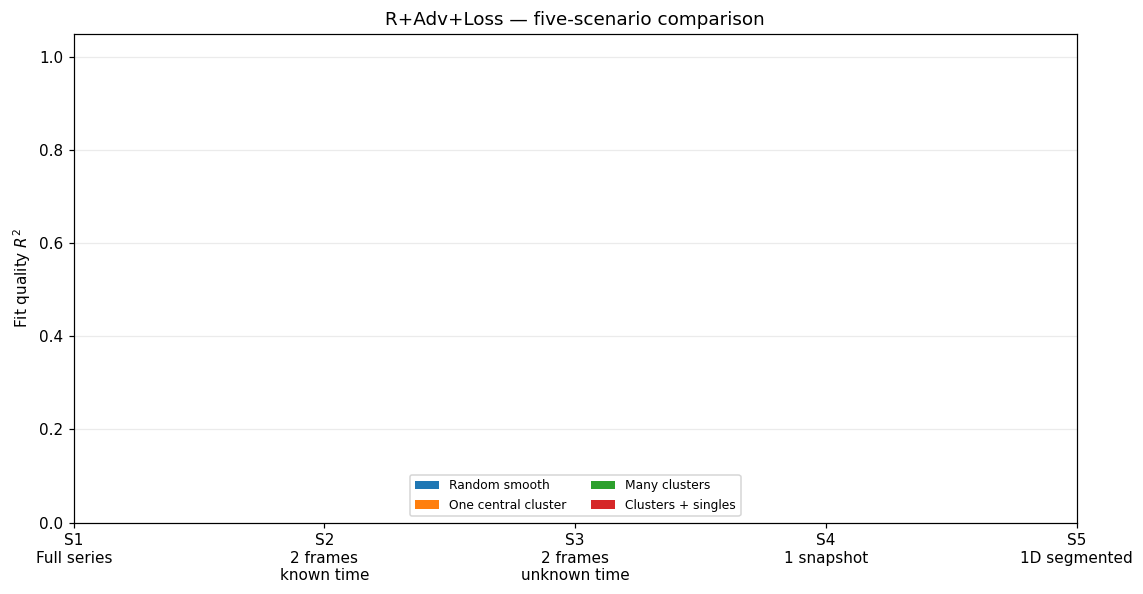

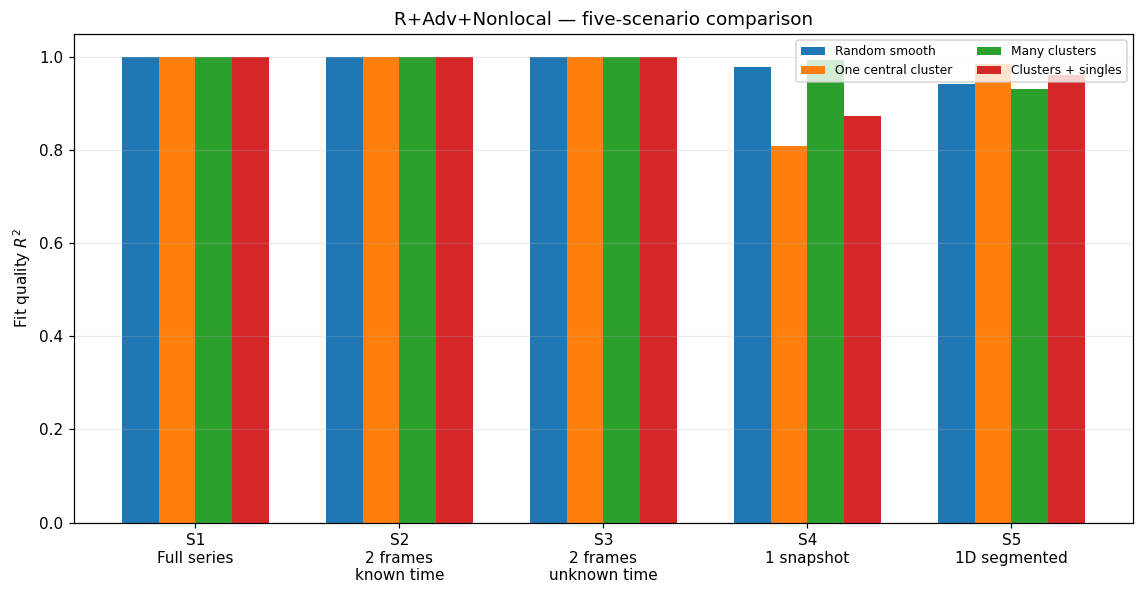

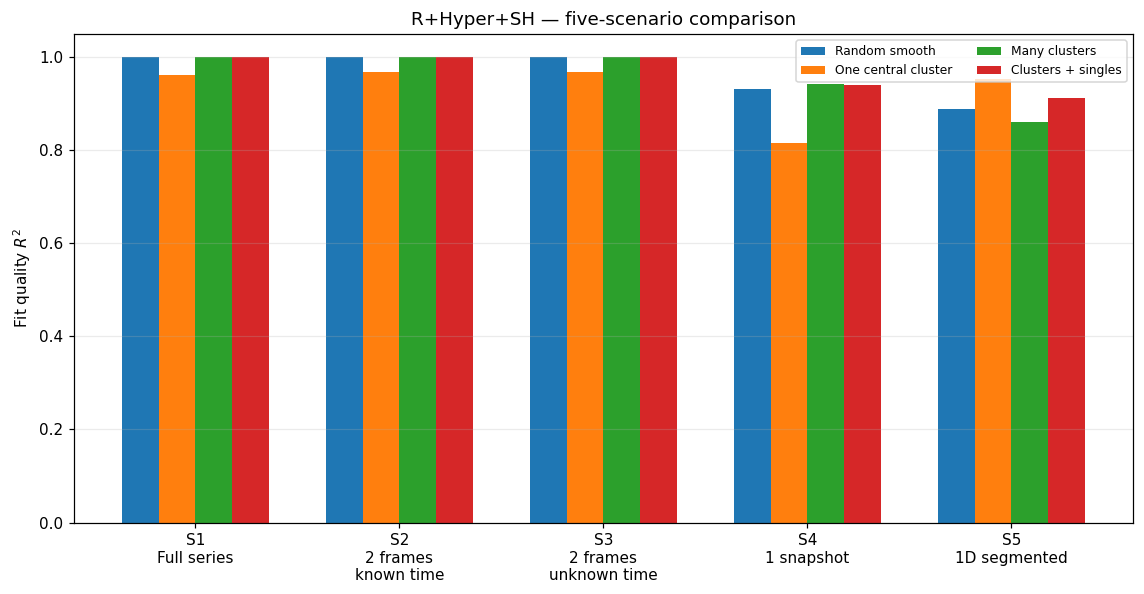

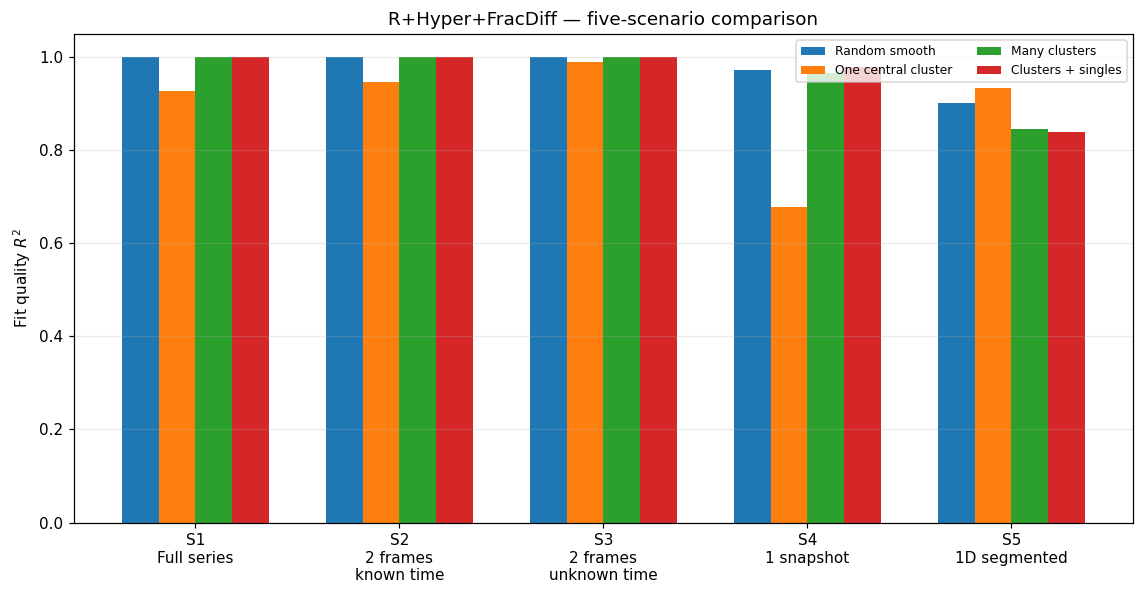

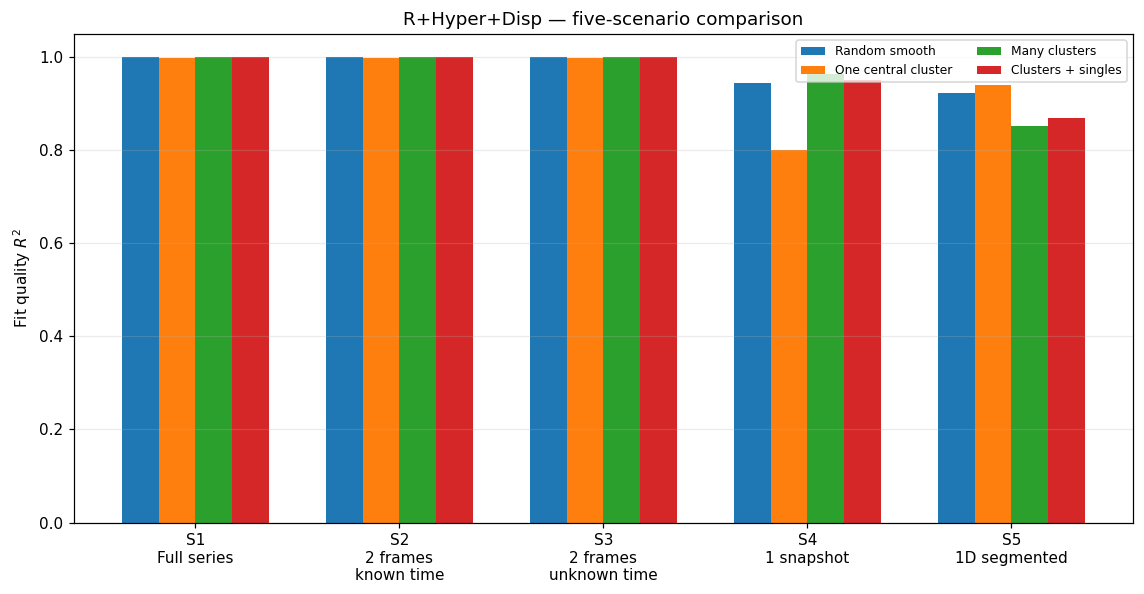

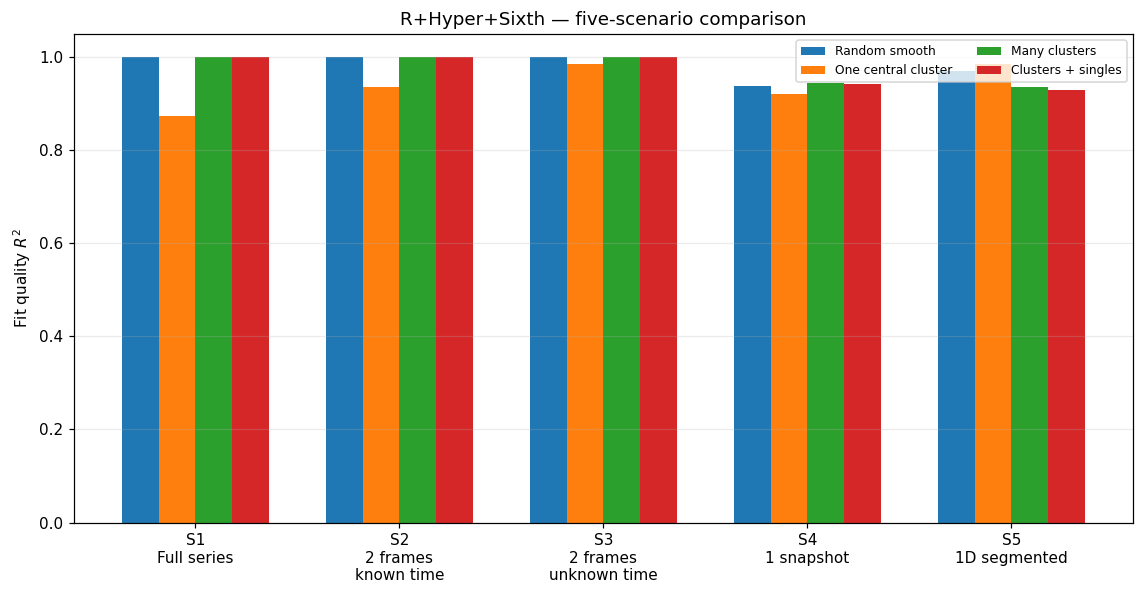

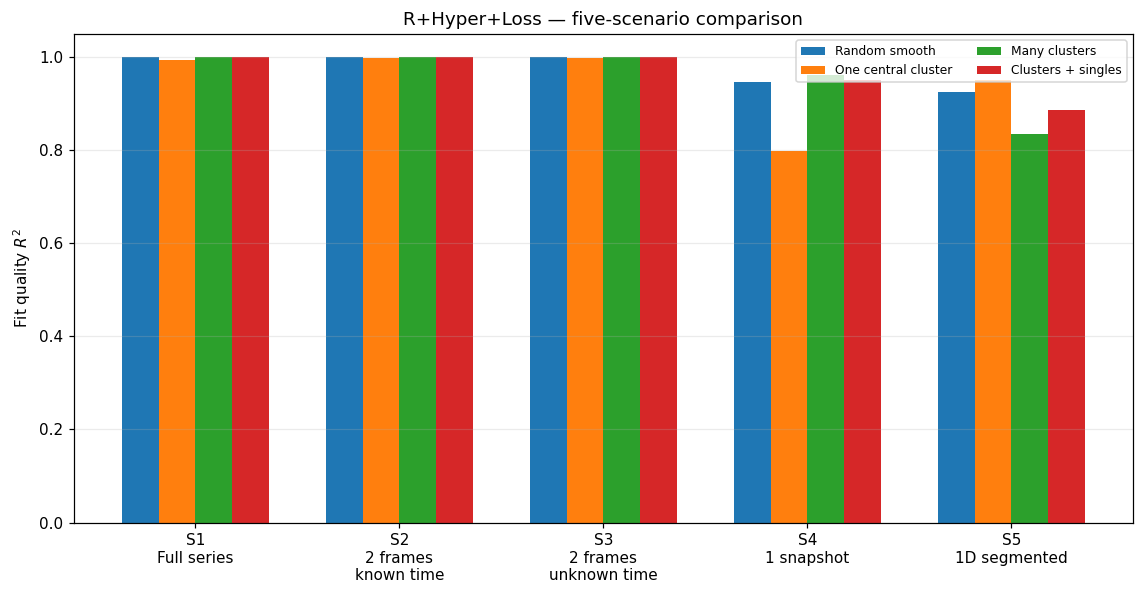

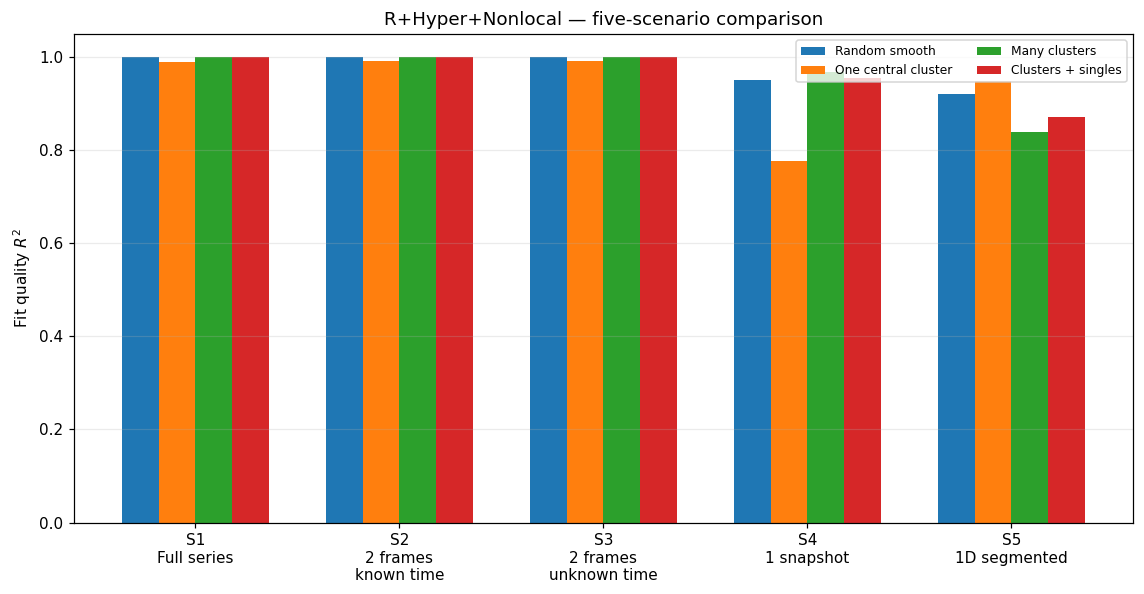

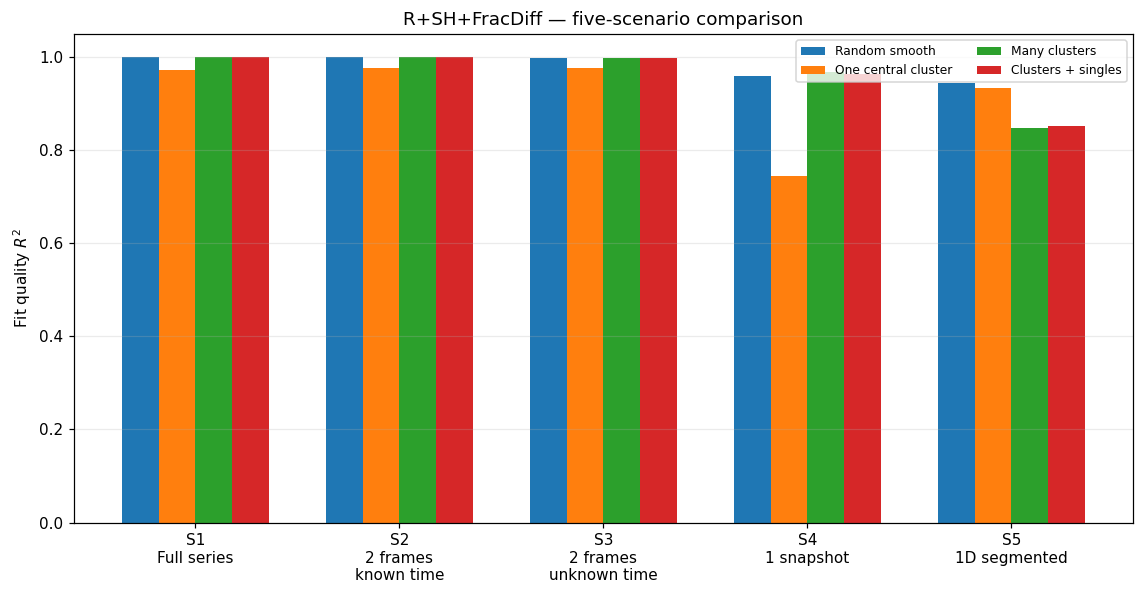

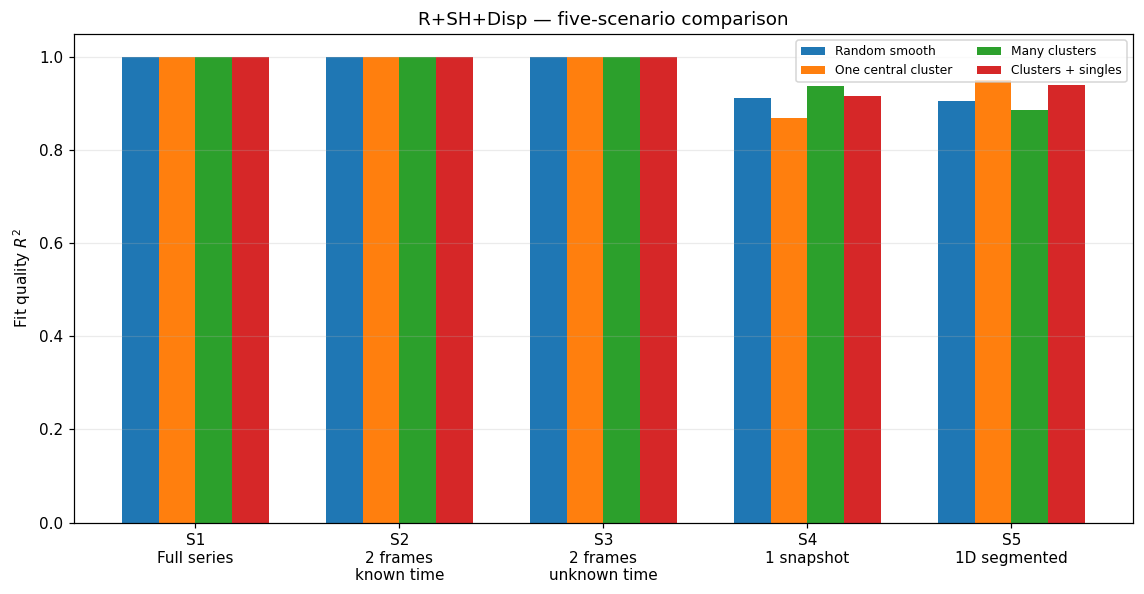

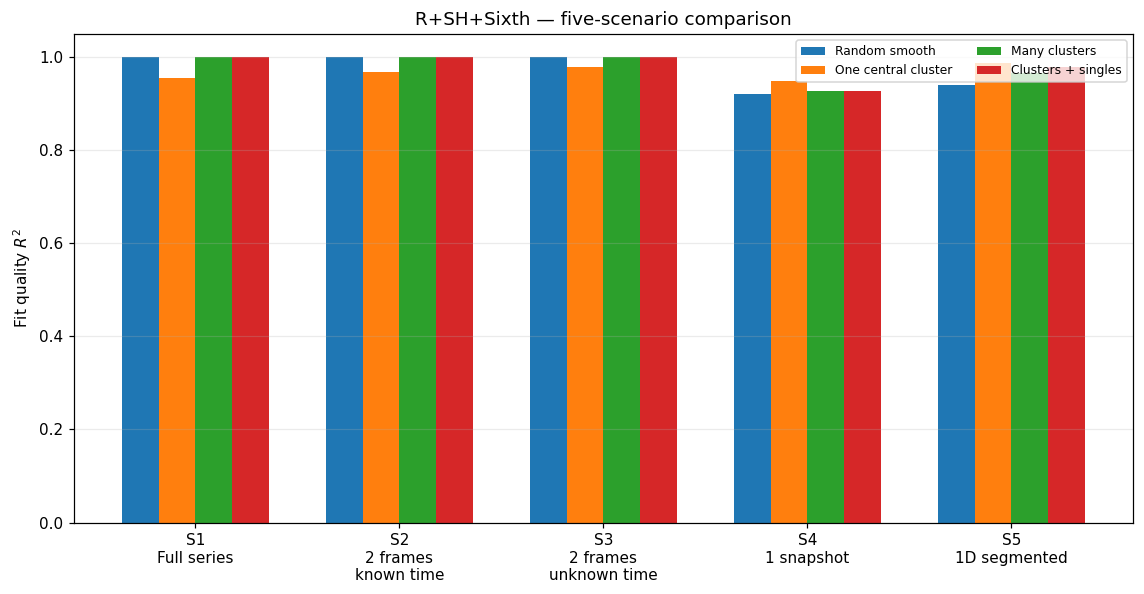

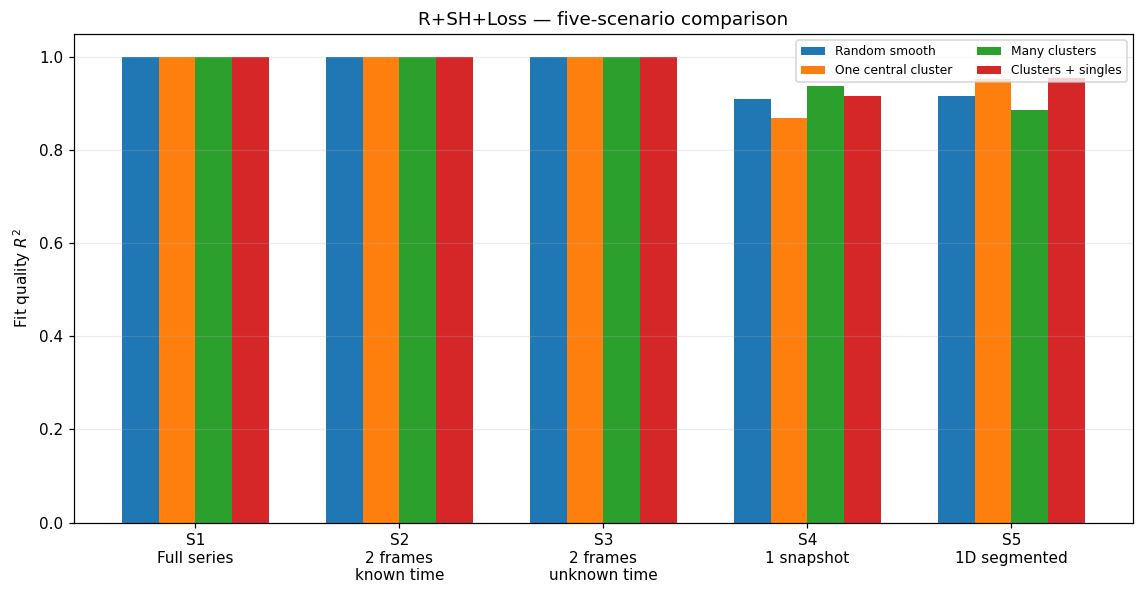

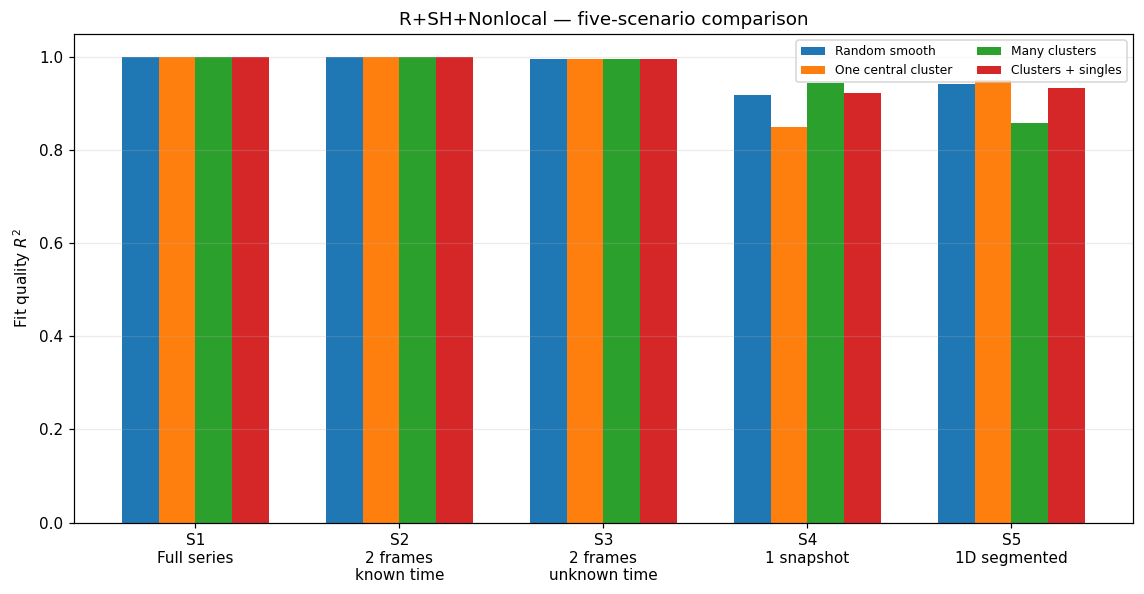

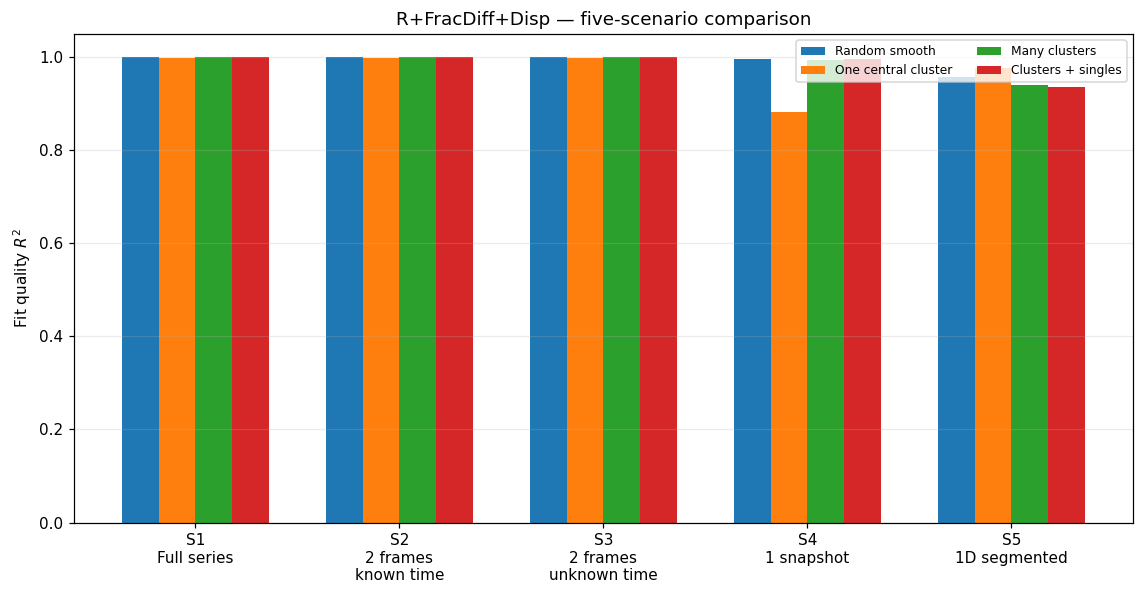

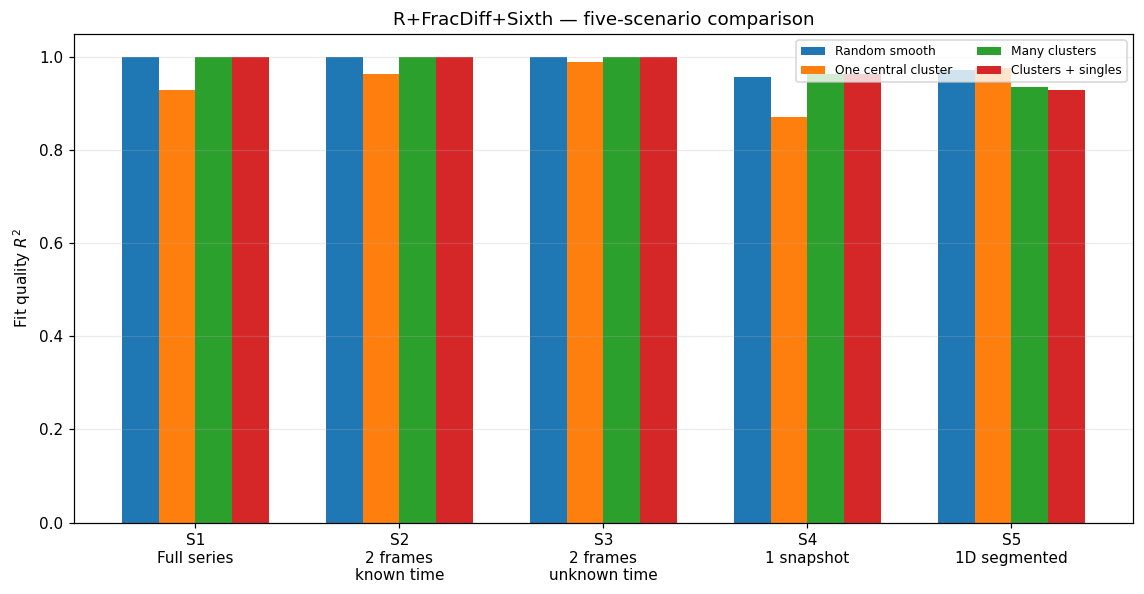

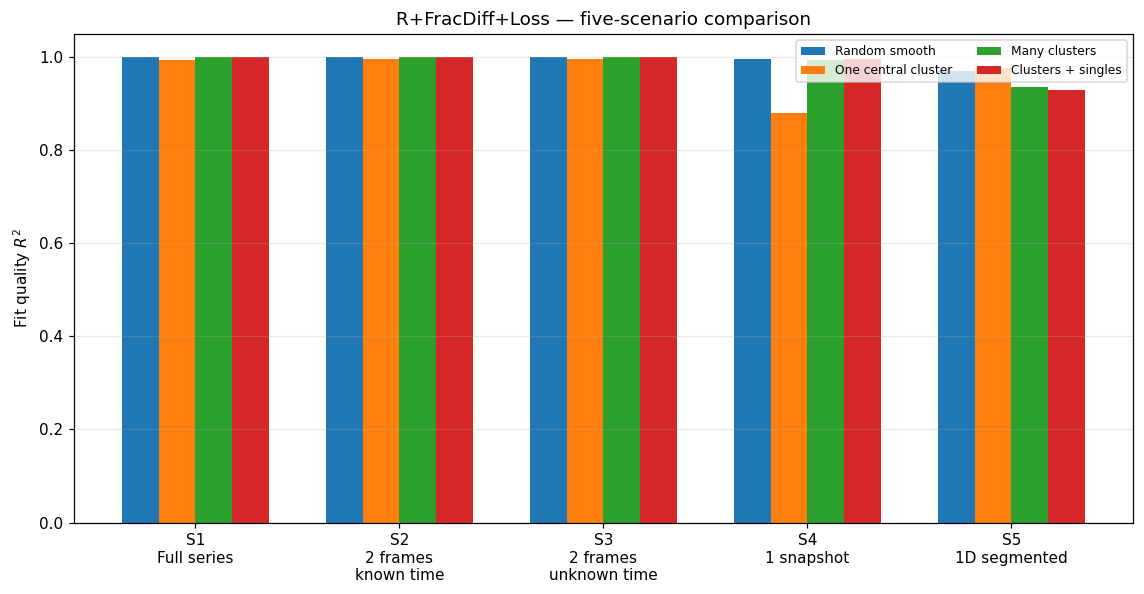

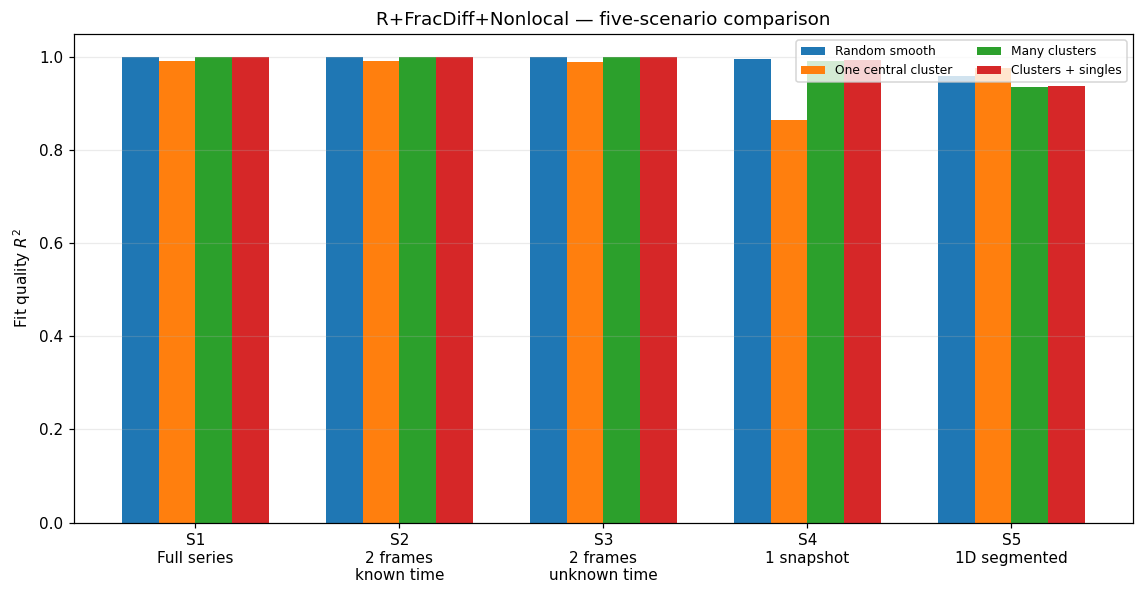

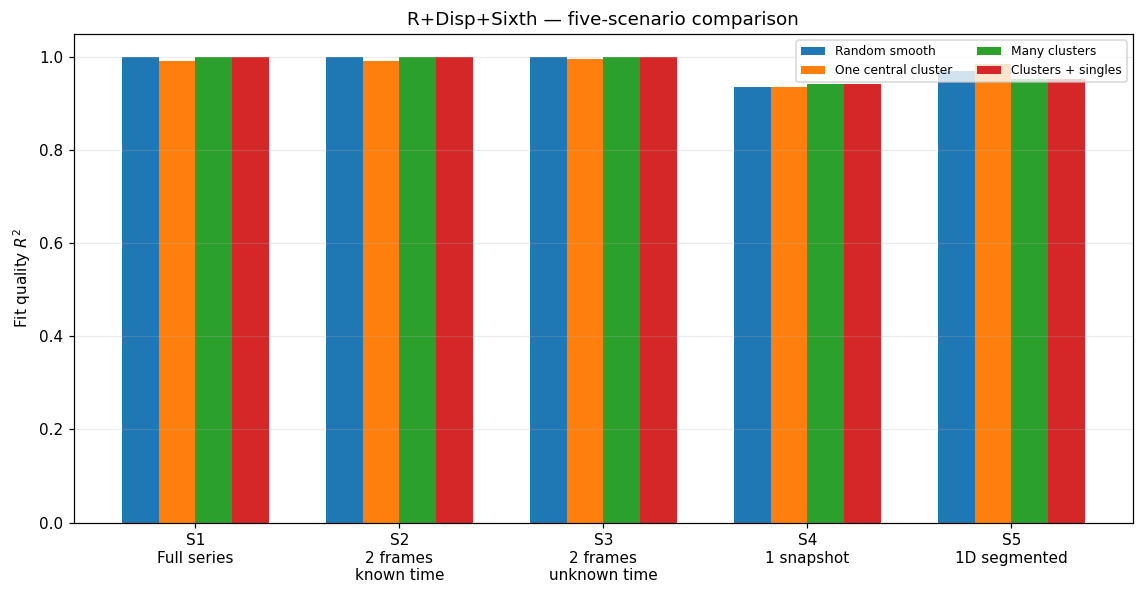

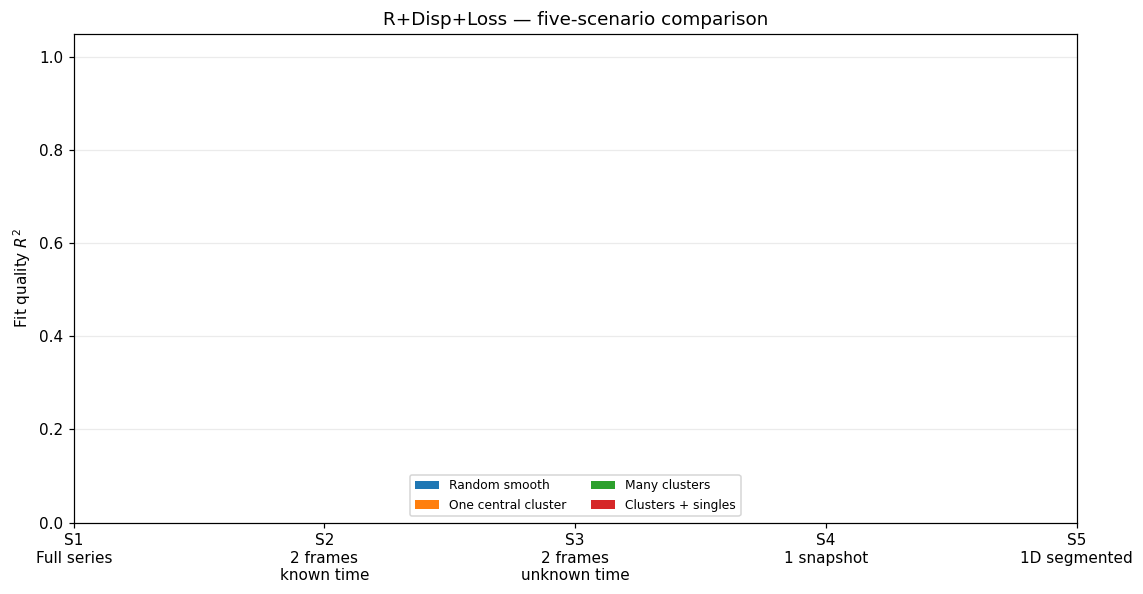

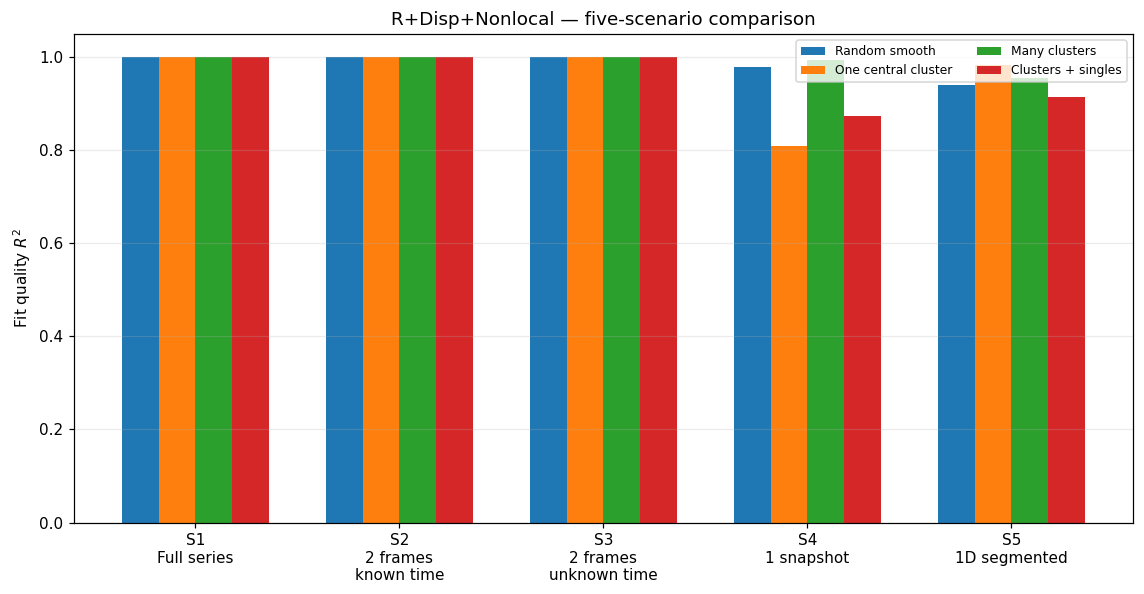

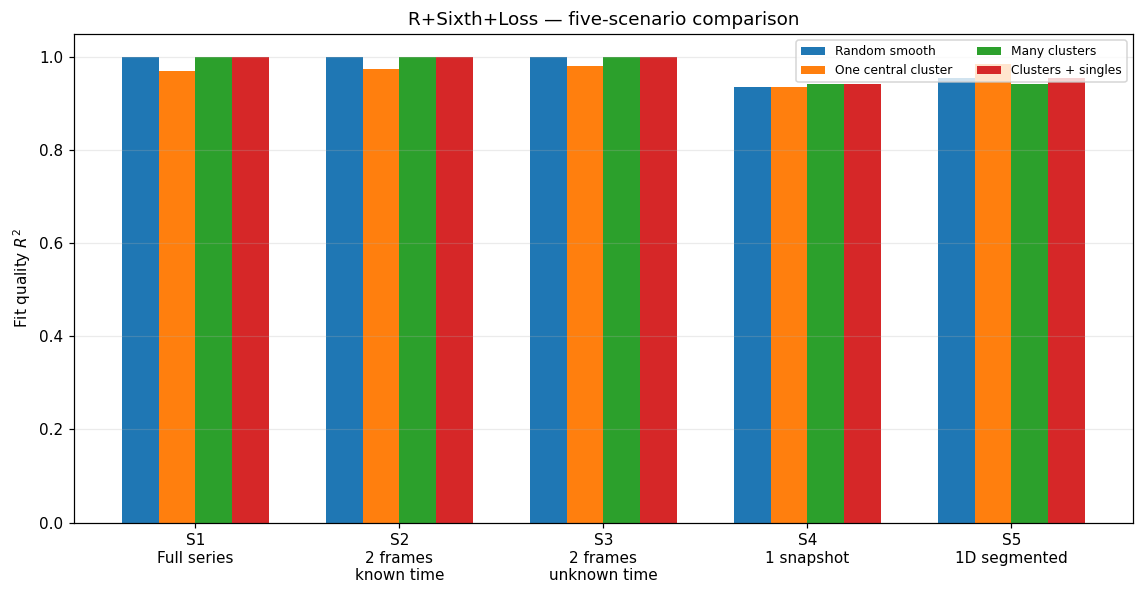

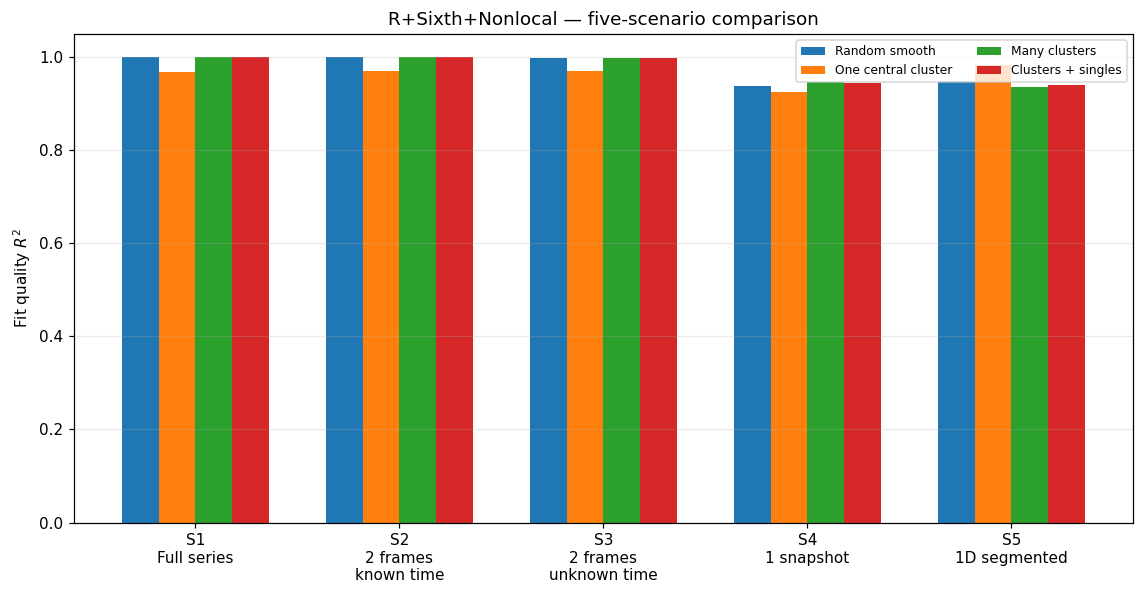

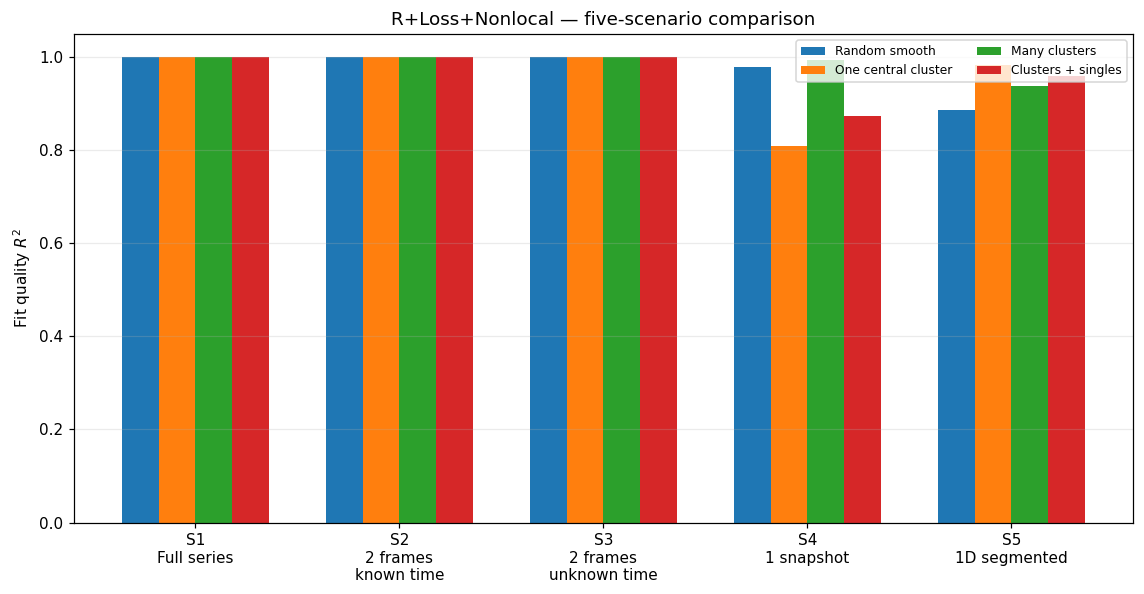

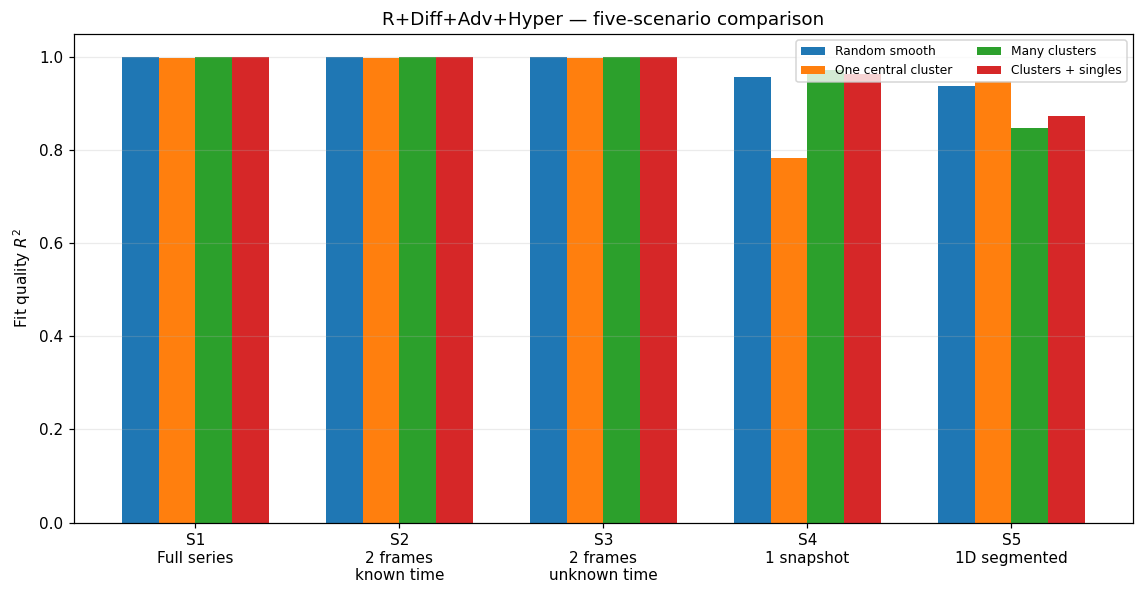

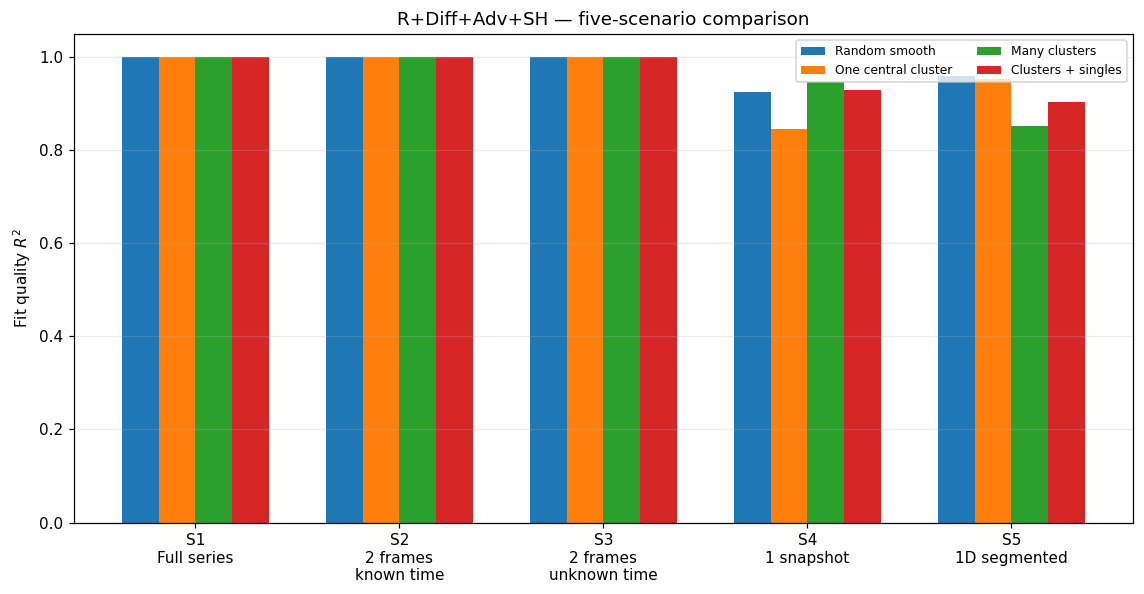

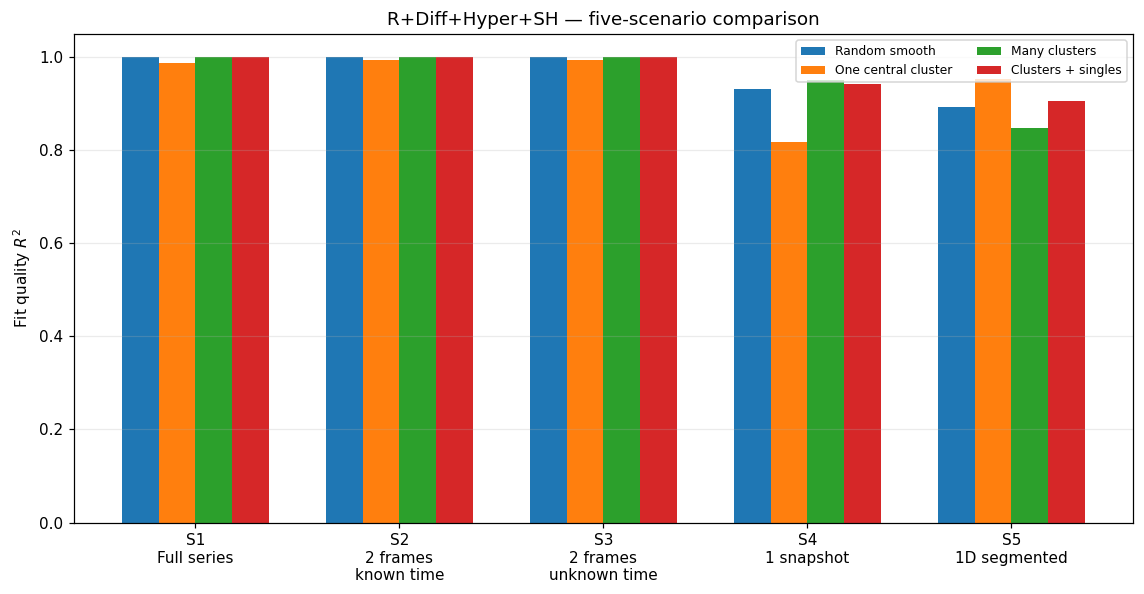

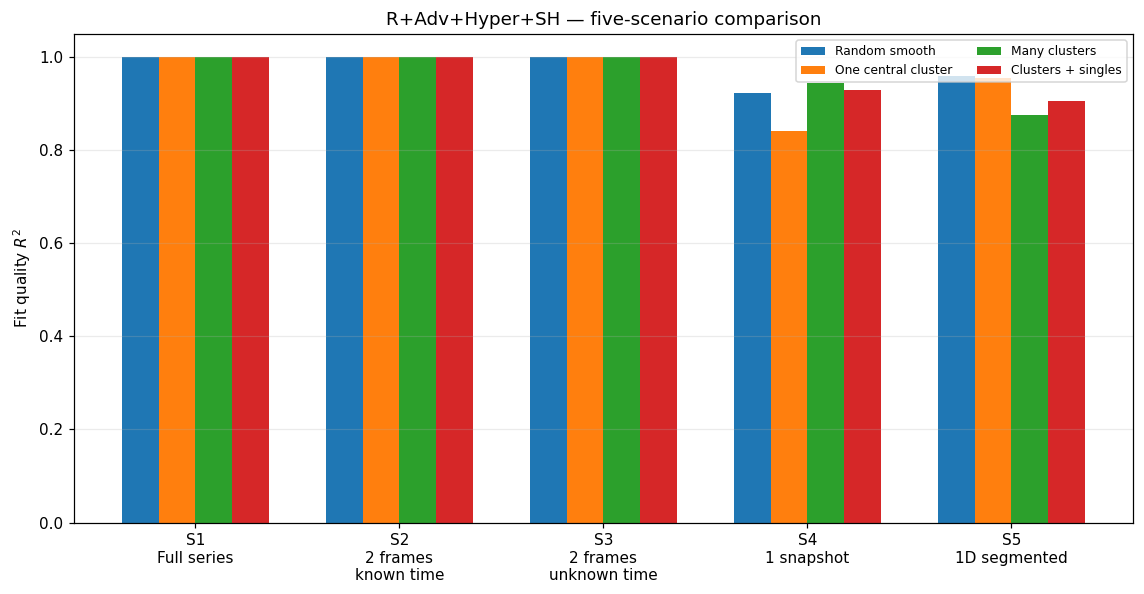

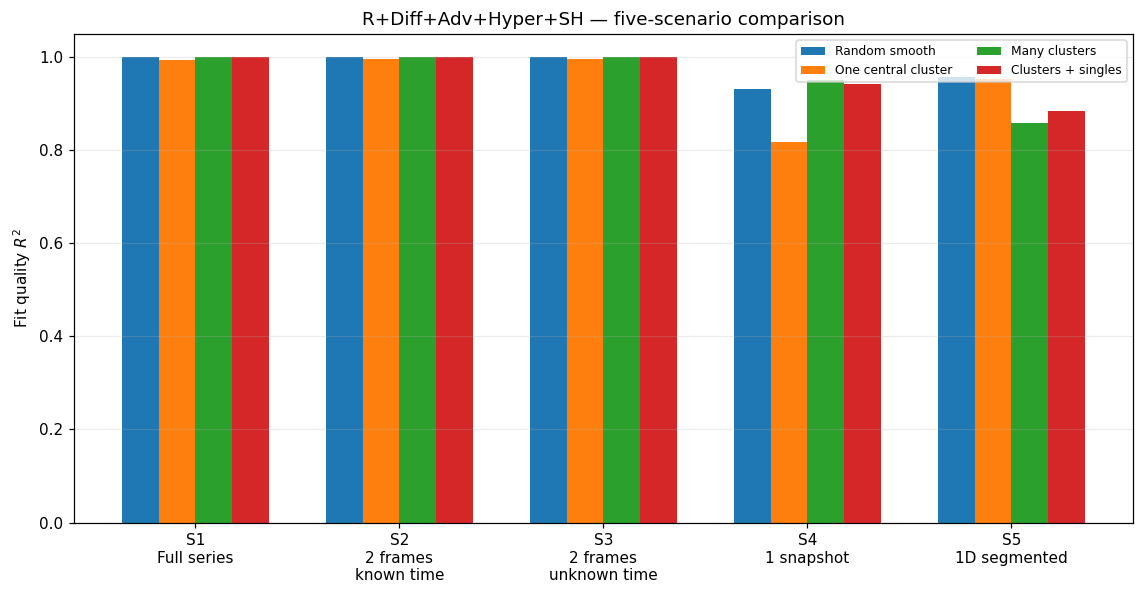

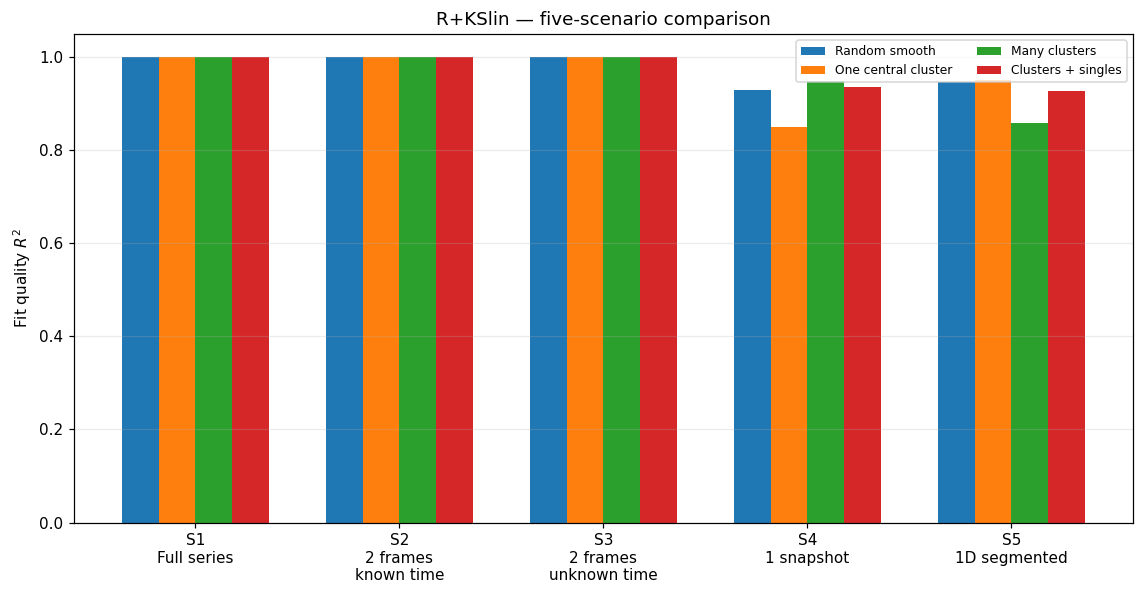

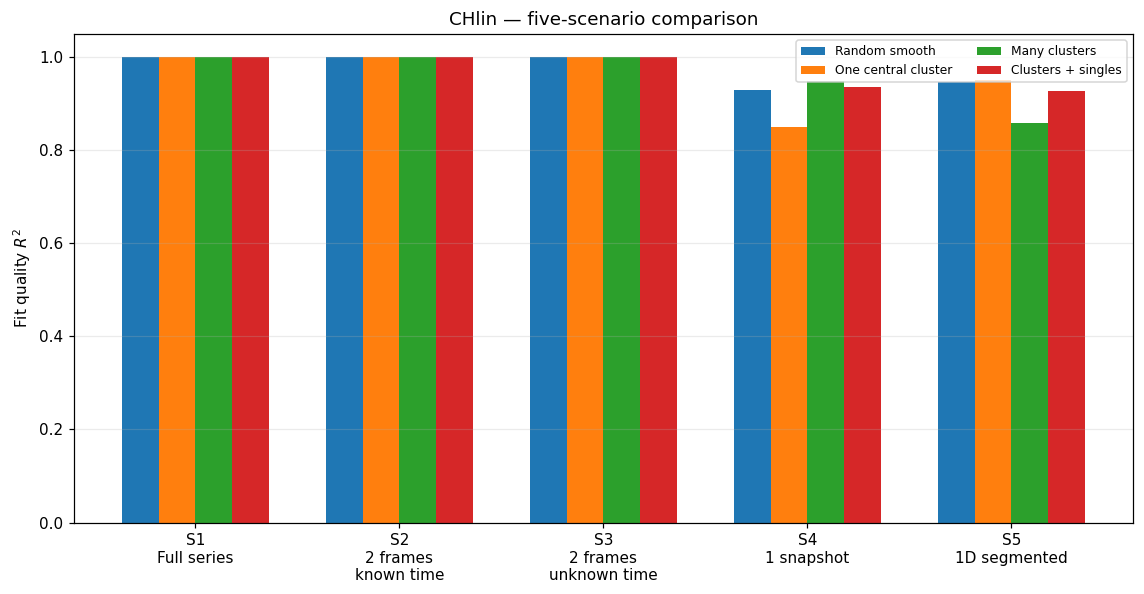

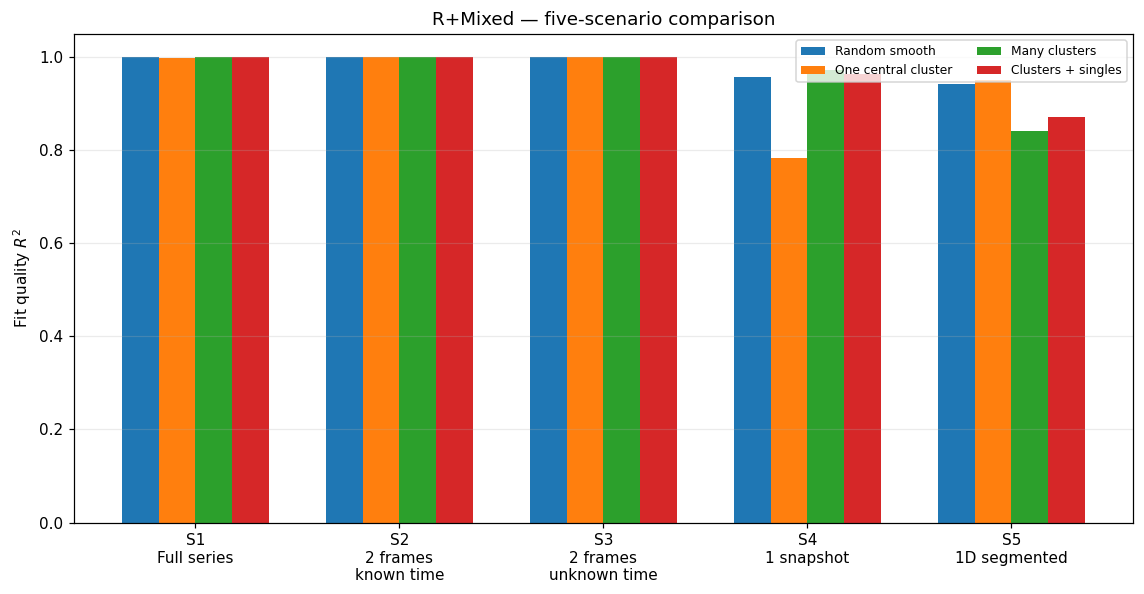

Generated five-scenario comparison plots for 53 PDEs.


In [15]:

# ============================================================
# COMPLETE 5-SCENARIO PLOTS FOR EVERY PDE
# ============================================================

FIVE_SCENARIO_R2_TABLES = {}

for tag,res in ALL_RESULTS.items():
    ic_names = list(ICs.keys())
    scen_names = ["S1","S2","S3","S4","S5"]

    table = np.full((len(ic_names),len(scen_names)),np.nan)

    for i,ic in enumerate(ic_names):
        for j,scen in enumerate(["S1","S2","S3","S4"]):
            rr = res[scen].get(ic)
            if rr is not None and "R2" in rr:
                table[i,j] = rr["R2"]

        rr5 = res["S5"].get(ic)
        if rr5 is not None:
            # IMPORTANT: accepted-segment median only
            table[i,4] = rr5.get("median_R2",np.nan)

    FIVE_SCENARIO_R2_TABLES[tag] = pd.DataFrame(
        table,
        index=ic_names,
        columns=scen_names
    )

    fig,ax = plt.subplots(figsize=(10.5,5.5))

    xloc = np.arange(len(scen_names))
    width = 0.18
    offsets = np.linspace(-1.5*width,1.5*width,len(ic_names))

    for off,ic in zip(offsets,ic_names):
        vals = FIVE_SCENARIO_R2_TABLES[tag].loc[ic].values
        ax.bar(xloc+off,vals,width,label=ic)

    ax.set_xticks(xloc)
    ax.set_xticklabels([
        "S1\nFull series",
        "S2\n2 frames\nknown time",
        "S3\n2 frames\nunknown time",
        "S4\n1 snapshot",
        "S5\n1D segmented"
    ])
    ax.set_ylim(0,1.05)
    ax.set_ylabel(r"Fit quality $R^2$")
    ax.set_title(f"{tag} — five-scenario comparison")
    ax.grid(axis="y",alpha=.25)
    ax.legend(fontsize=8,ncol=2)

    plt.tight_layout()

    if SAVE_FIGURES:
        safe = tag.replace("+","_").replace("/","_")
        fig.savefig(
            os.path.join(FIG_DIR,f"{safe}_five_scenarios.png"),
            dpi=180,bbox_inches="tight"
        )

    plt.show()

print("Generated five-scenario comparison plots for",len(FIVE_SCENARIO_R2_TABLES),"PDEs.")



# 15. Final comparison plots across all PDEs

These plots summarize the entire model library after the individual PDE analyses are complete.

They include:

1. theoretical PSD-visible dispersion signatures;
2. median S1/S2 parameter-recovery error;
3. median \(R^2\) across all four ICs for S1–S5;
4. scenario-specific heatmaps;
5. identifiability / recoverability map;
6. Scenario-5 accepted-segment fraction;
7. Scenario-5 detailed reaction–diffusion grid sweep;
8. overall ranking summaries, separated by scenario so unlike \(R^2\) definitions are not mixed into one score.


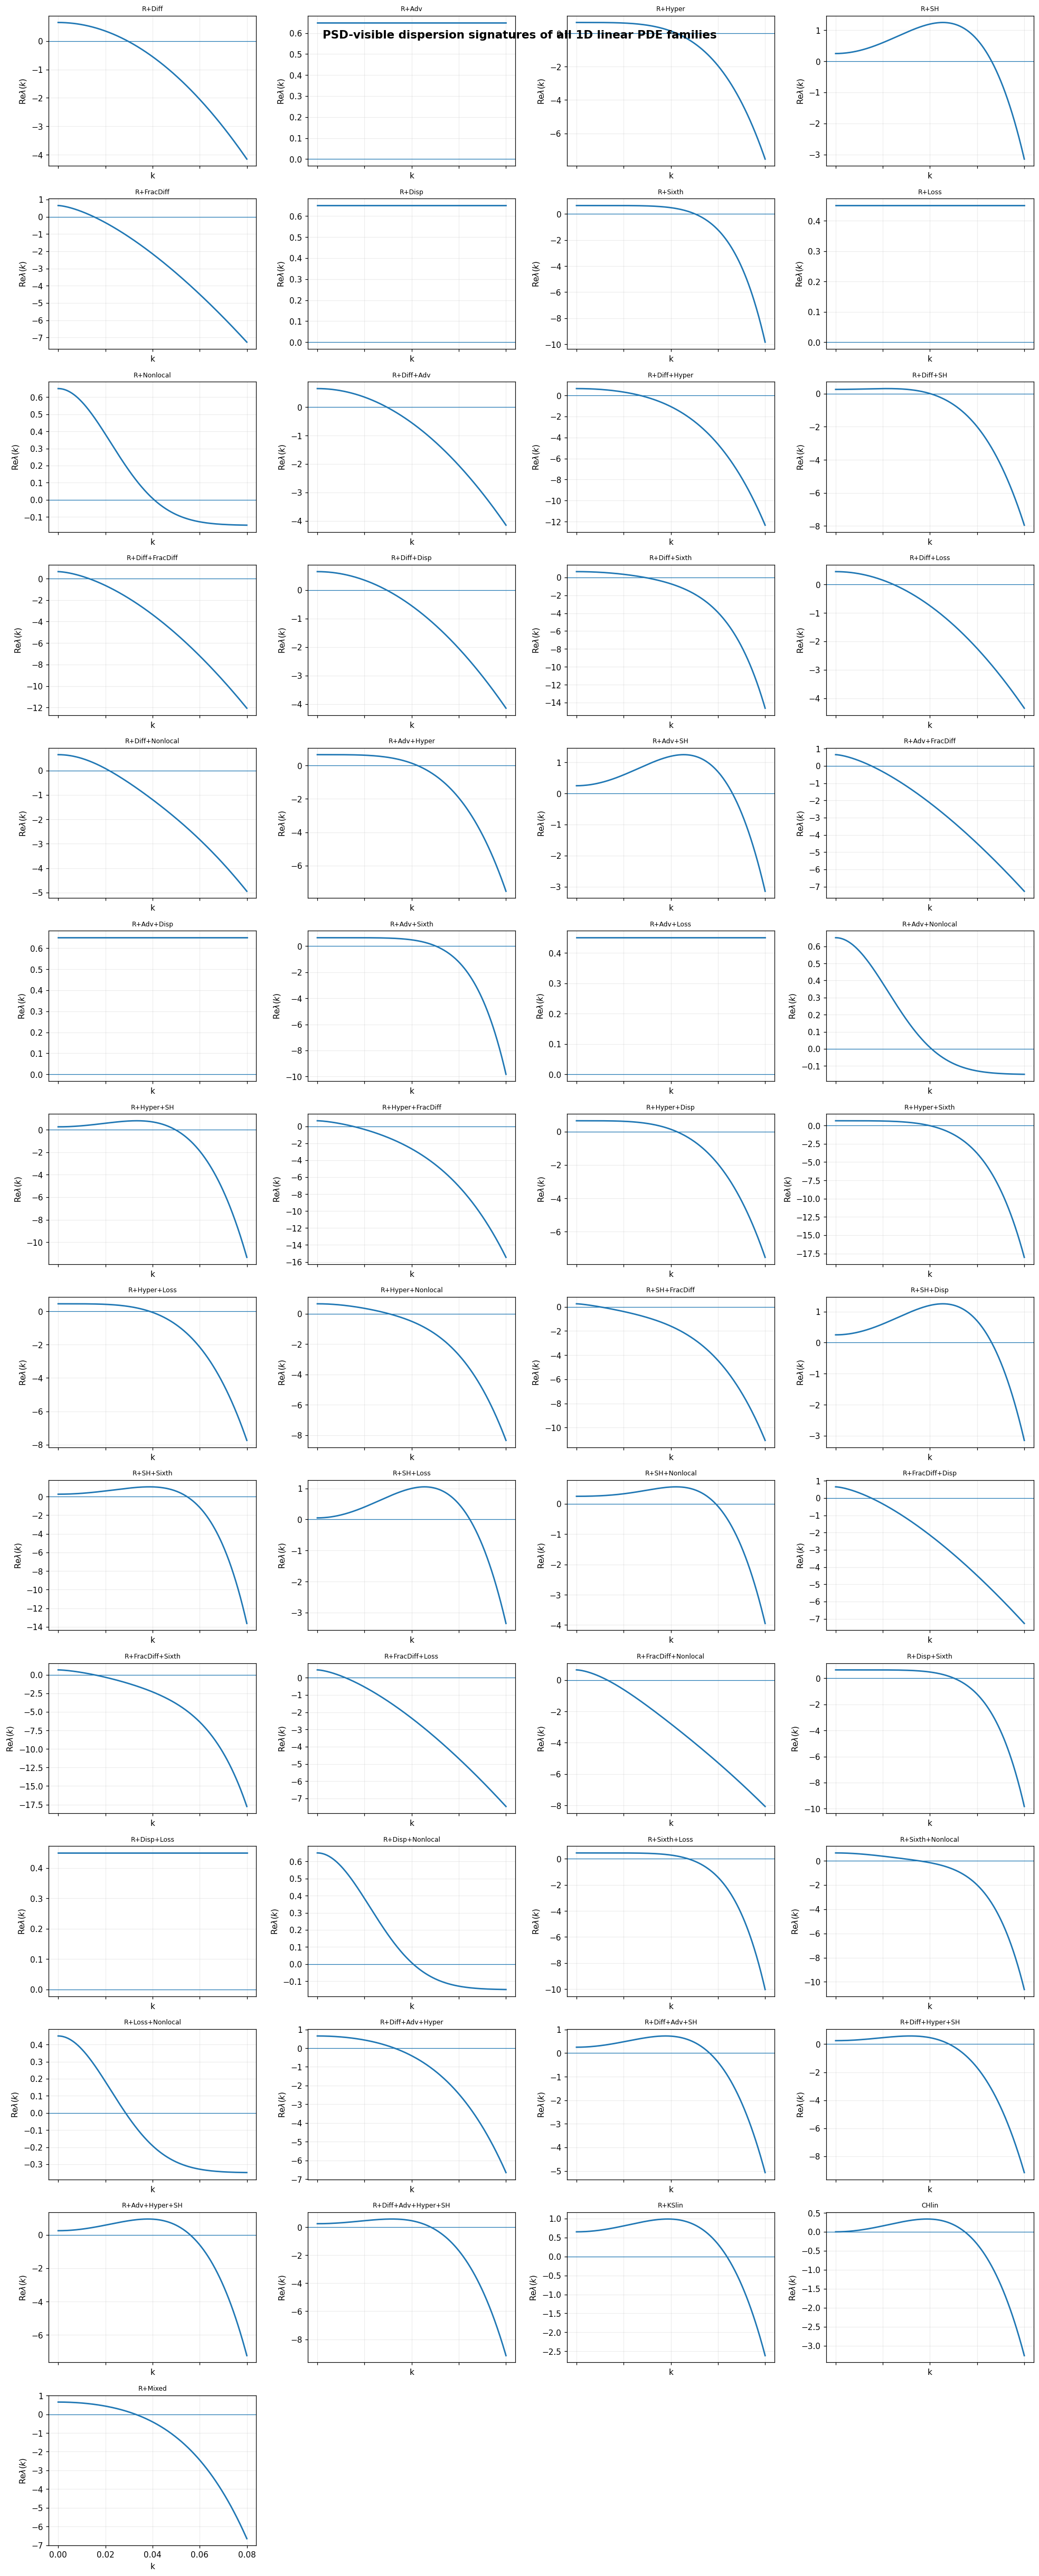

In [16]:

# ============================================================
# FINAL COMPARISON 1 — THEORETICAL PSD-VISIBLE SYMBOLS
# ============================================================

n_models = len(MODEL_LIBRARY)
ncols = 4
nrows = int(np.ceil(n_models/ncols))

fig,axs = plt.subplots(nrows,ncols,figsize=(18,3.2*nrows),sharex=True)
axs = np.atleast_1d(axs).ravel()

kplot = np.linspace(0,0.08,500)

for ax,(tag,spec) in zip(axs,MODEL_LIBRARY.items()):
    p = spec["true"]
    ax.plot(kplot,real_symbol(kplot,tag,p),linewidth=1.8)
    ax.axhline(0,linewidth=.8)
    ax.set_title(tag,fontsize=8)
    ax.set_xlabel("k")
    ax.set_ylabel(r"$\mathrm{Re}\lambda(k)$")
    ax.grid(alpha=.22)

for ax in axs[n_models:]:
    ax.axis("off")

fig.suptitle(
    "PSD-visible dispersion signatures of all 1D linear PDE families",
    fontsize=14,fontweight="bold"
)
plt.tight_layout()
plt.show()


,PDE,Scenario,MedianAbsPercentError,MeanAbsPercentError
0,R+Diff,S1,1.639293e-09,0.055849
1,R+Diff,S2,1.012237e-09,0.048078
2,R+Adv,S1,5.491334e-12,0.000049
3,R+Adv,S2,6.439294e-12,0.000149
4,R+Hyper,S1,5.801672e-08,0.605304
...,...,...,...,...
101,R+KSlin,S2,7.179214e-10,0.010457
102,CHlin,S1,2.102788e-09,0.032113
103,CHlin,S2,1.719960e-09,0.024768
104,R+Mixed,S1,5.587204e-09,1.347393


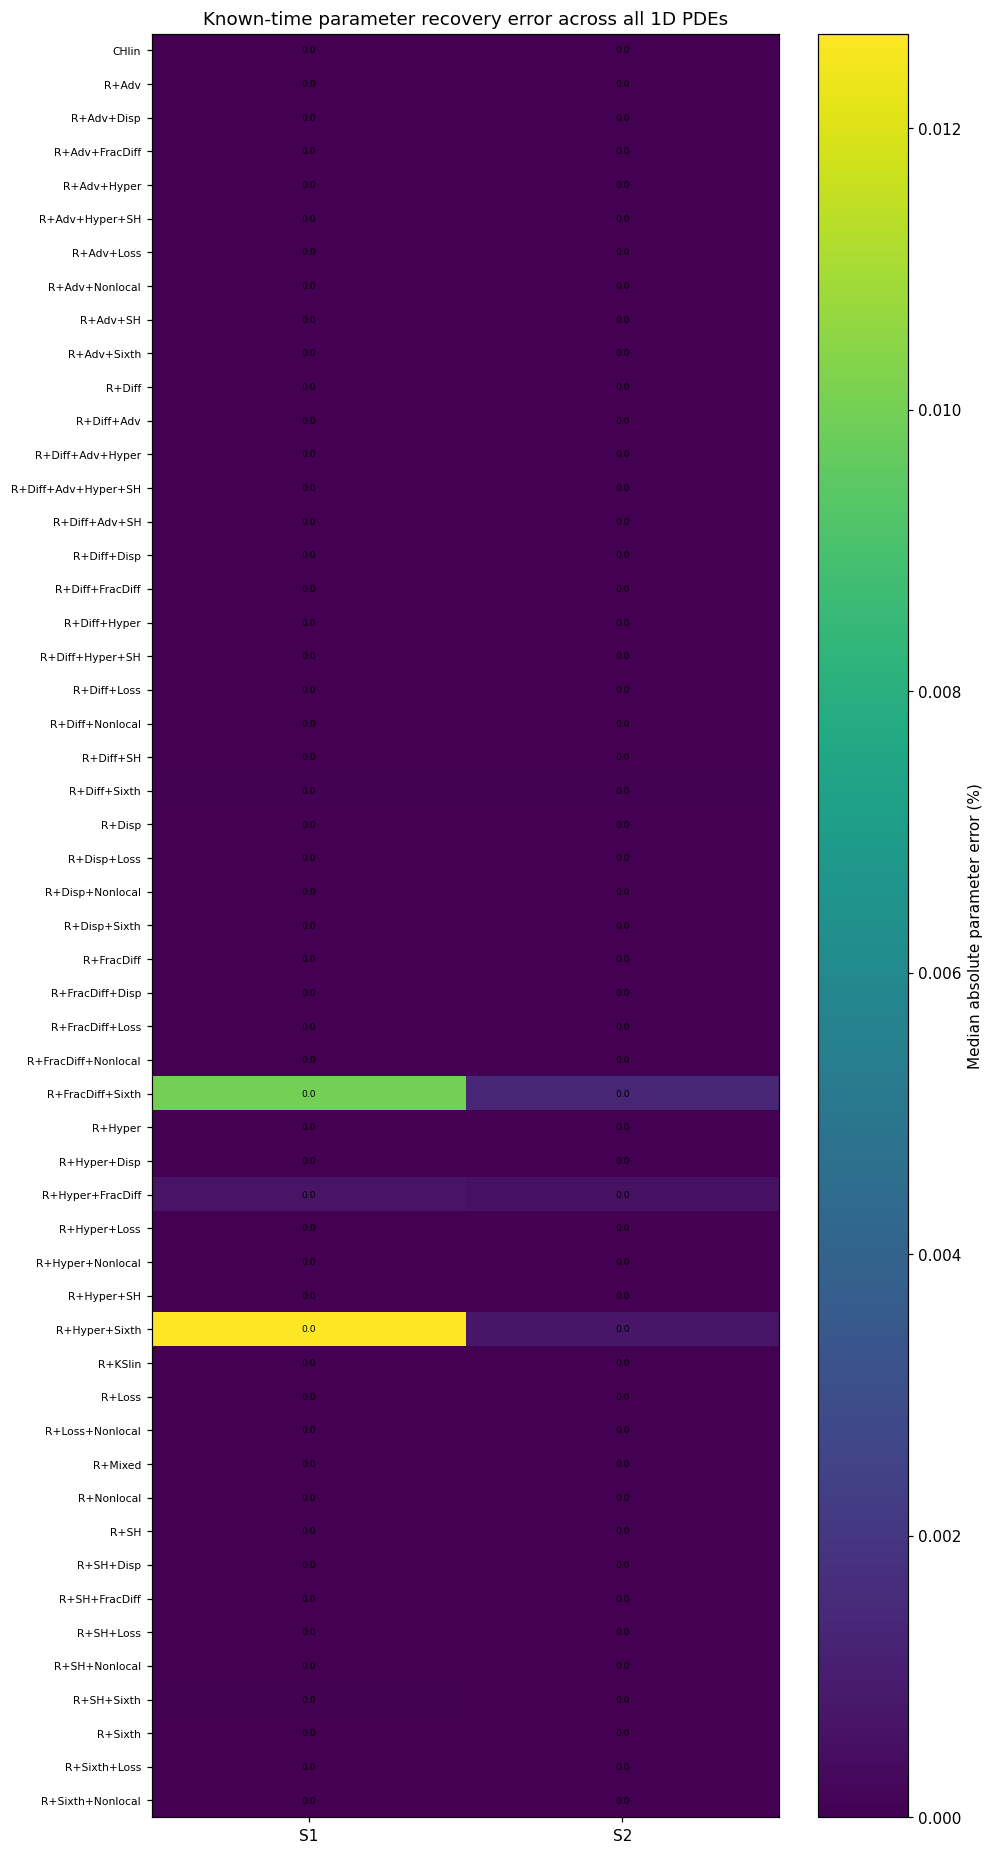

In [17]:

# ============================================================
# FINAL COMPARISON 2 — S1 / S2 PARAMETER RECOVERY ERROR
# ============================================================

err_rows=[]

for tag,res in ALL_RESULTS.items():
    for scen in ("S1","S2"):
        errs=[]

        for ic,rr in res[scen].items():
            if rr is None:
                continue

            for pname,est in rr.get("fit",{}).items():
                tv = true_identifiable_value(tag,pname)

                if np.isfinite(tv) and abs(tv)>1e-30:
                    errs.append(abs(relative_error(est,tv)))

        err_rows.append({
            "PDE":tag,
            "Scenario":scen,
            "MedianAbsPercentError":np.nanmedian(errs) if errs else np.nan,
            "MeanAbsPercentError":np.nanmean(errs) if errs else np.nan,
        })

PARAM_ERROR_DF = pd.DataFrame(err_rows)
display(PARAM_ERROR_DF)

pivot = PARAM_ERROR_DF.pivot(
    index="PDE",
    columns="Scenario",
    values="MedianAbsPercentError"
).reindex(columns=["S1","S2"])

fig,ax = plt.subplots(figsize=(9,max(10,.32*len(pivot))))
im = ax.imshow(pivot.values,aspect="auto")

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index,fontsize=7)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v=pivot.iloc[i,j]
        if np.isfinite(v):
            ax.text(j,i,f"{v:.1f}",ha="center",va="center",fontsize=6)

fig.colorbar(im,ax=ax,label="Median absolute parameter error (%)")
ax.set_title("Known-time parameter recovery error across all 1D PDEs")
plt.tight_layout()
plt.show()


Scenario,S1,S2,S3,S4,S5
PDE,,,,,
CHlin,1.0,1.0,1.0000,0.9341,0.9376
R+Adv,NaN,NaN,0.0000,0.0000,NaN
R+Adv+Disp,NaN,NaN,0.0000,0.0000,NaN
R+Adv+FracDiff,1.0,1.0,1.0000,0.9949,0.9517
R+Adv+Hyper,1.0,1.0,1.0000,0.9484,0.9170
R+Adv+Hyper+SH,1.0,1.0,1.0000,0.9266,0.9304
R+Adv+Loss,NaN,NaN,0.0000,0.0000,NaN
R+Adv+Nonlocal,1.0,1.0,1.0000,0.9273,0.9527
R+Adv+SH,1.0,1.0,1.0000,0.9145,0.9467


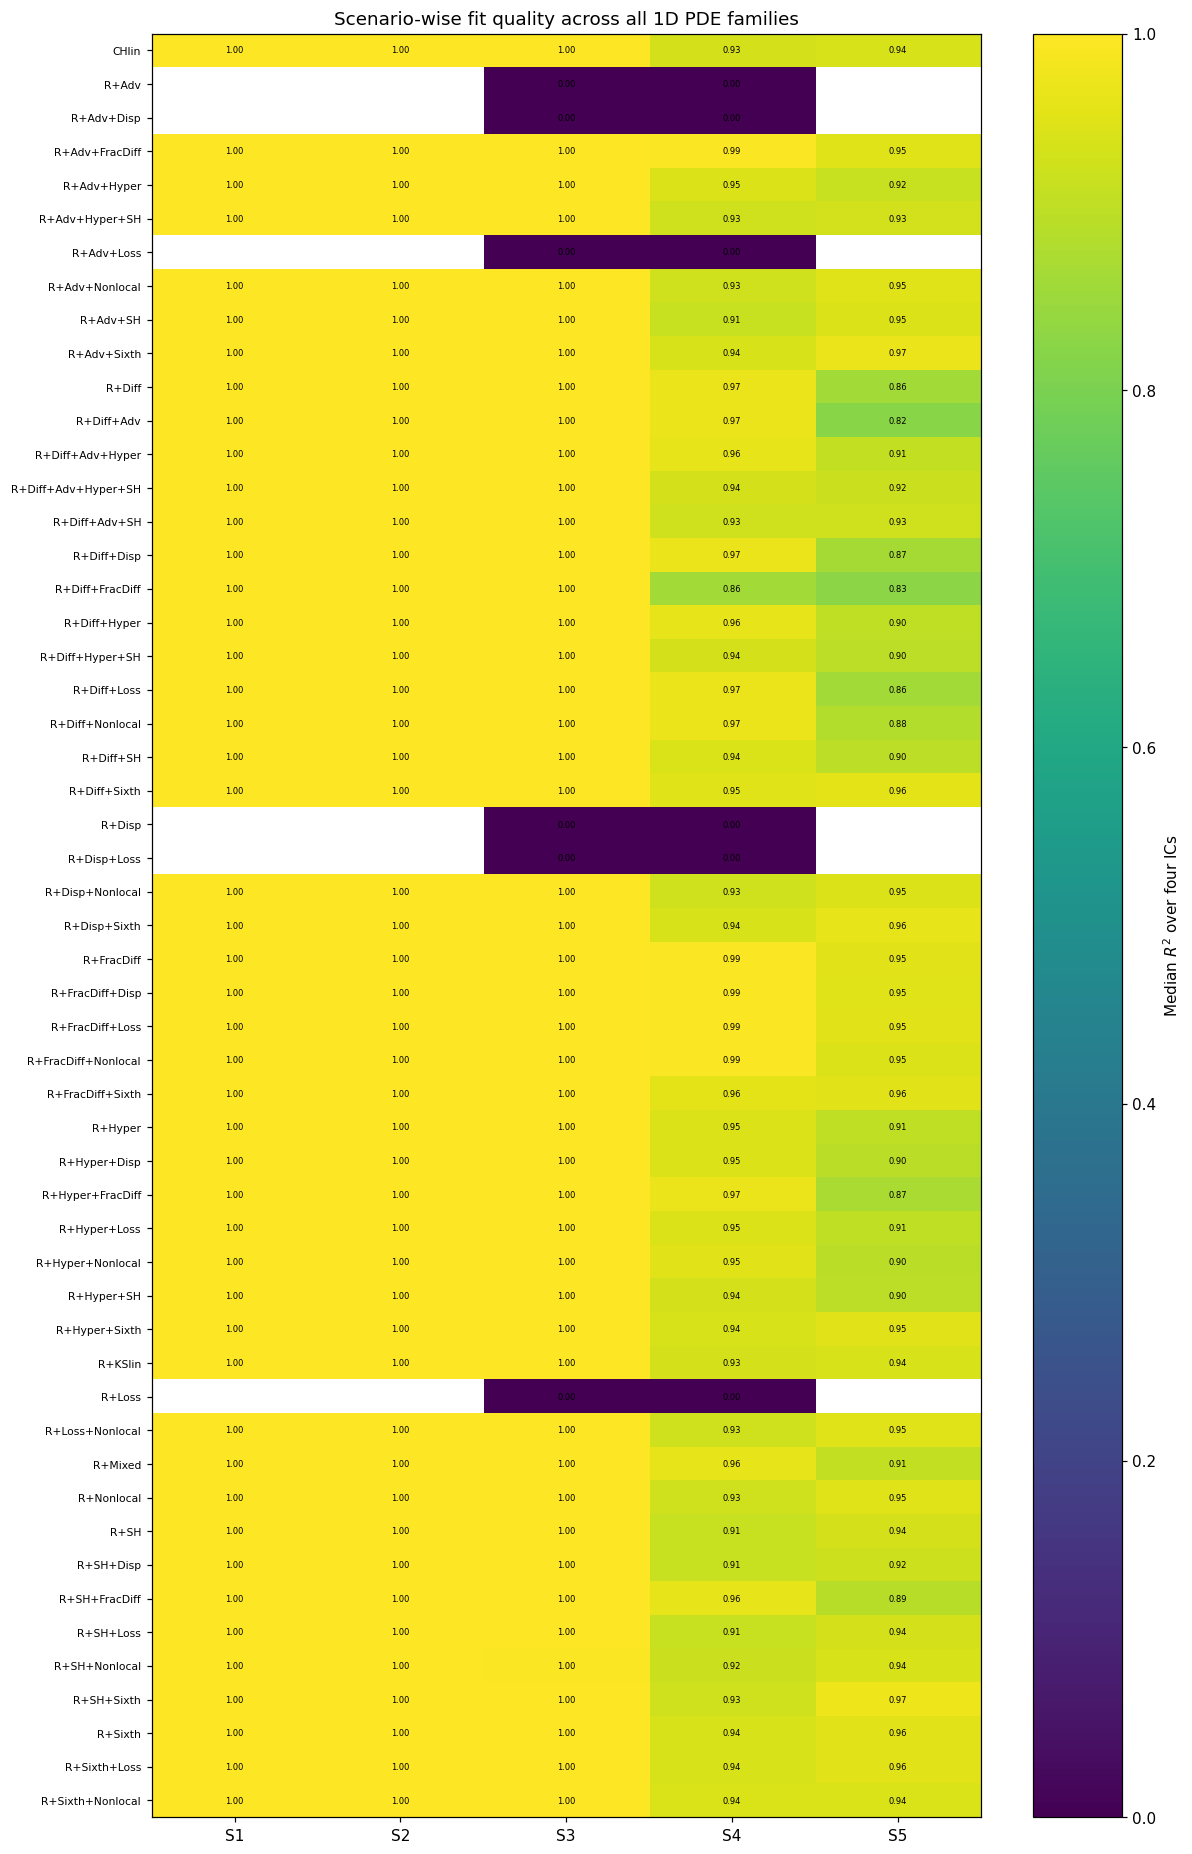

In [18]:

# ============================================================
# FINAL COMPARISON 3 — MEDIAN R2 ACROSS THE FOUR ICs
# ============================================================

R2_MEDIAN_FULL = (
    MASTER_SUMMARY_DF
    .groupby(["PDE","Scenario"],as_index=False)["R2"]
    .median()
    .pivot(index="PDE",columns="Scenario",values="R2")
    .reindex(columns=["S1","S2","S3","S4","S5"])
)

display(R2_MEDIAN_FULL.round(4))

fig,ax = plt.subplots(figsize=(11,max(10,.32*len(R2_MEDIAN_FULL))))
im = ax.imshow(R2_MEDIAN_FULL.values,aspect="auto",vmin=0,vmax=1)

ax.set_xticks(np.arange(5))
ax.set_xticklabels(["S1","S2","S3","S4","S5"])
ax.set_yticks(np.arange(len(R2_MEDIAN_FULL.index)))
ax.set_yticklabels(R2_MEDIAN_FULL.index,fontsize=7)

for i in range(R2_MEDIAN_FULL.shape[0]):
    for j in range(R2_MEDIAN_FULL.shape[1]):
        v=R2_MEDIAN_FULL.iloc[i,j]
        if np.isfinite(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=5.5)

fig.colorbar(im,ax=ax,label=r"Median $R^2$ over four ICs")
ax.set_title("Scenario-wise fit quality across all 1D PDE families")
plt.tight_layout()
plt.show()


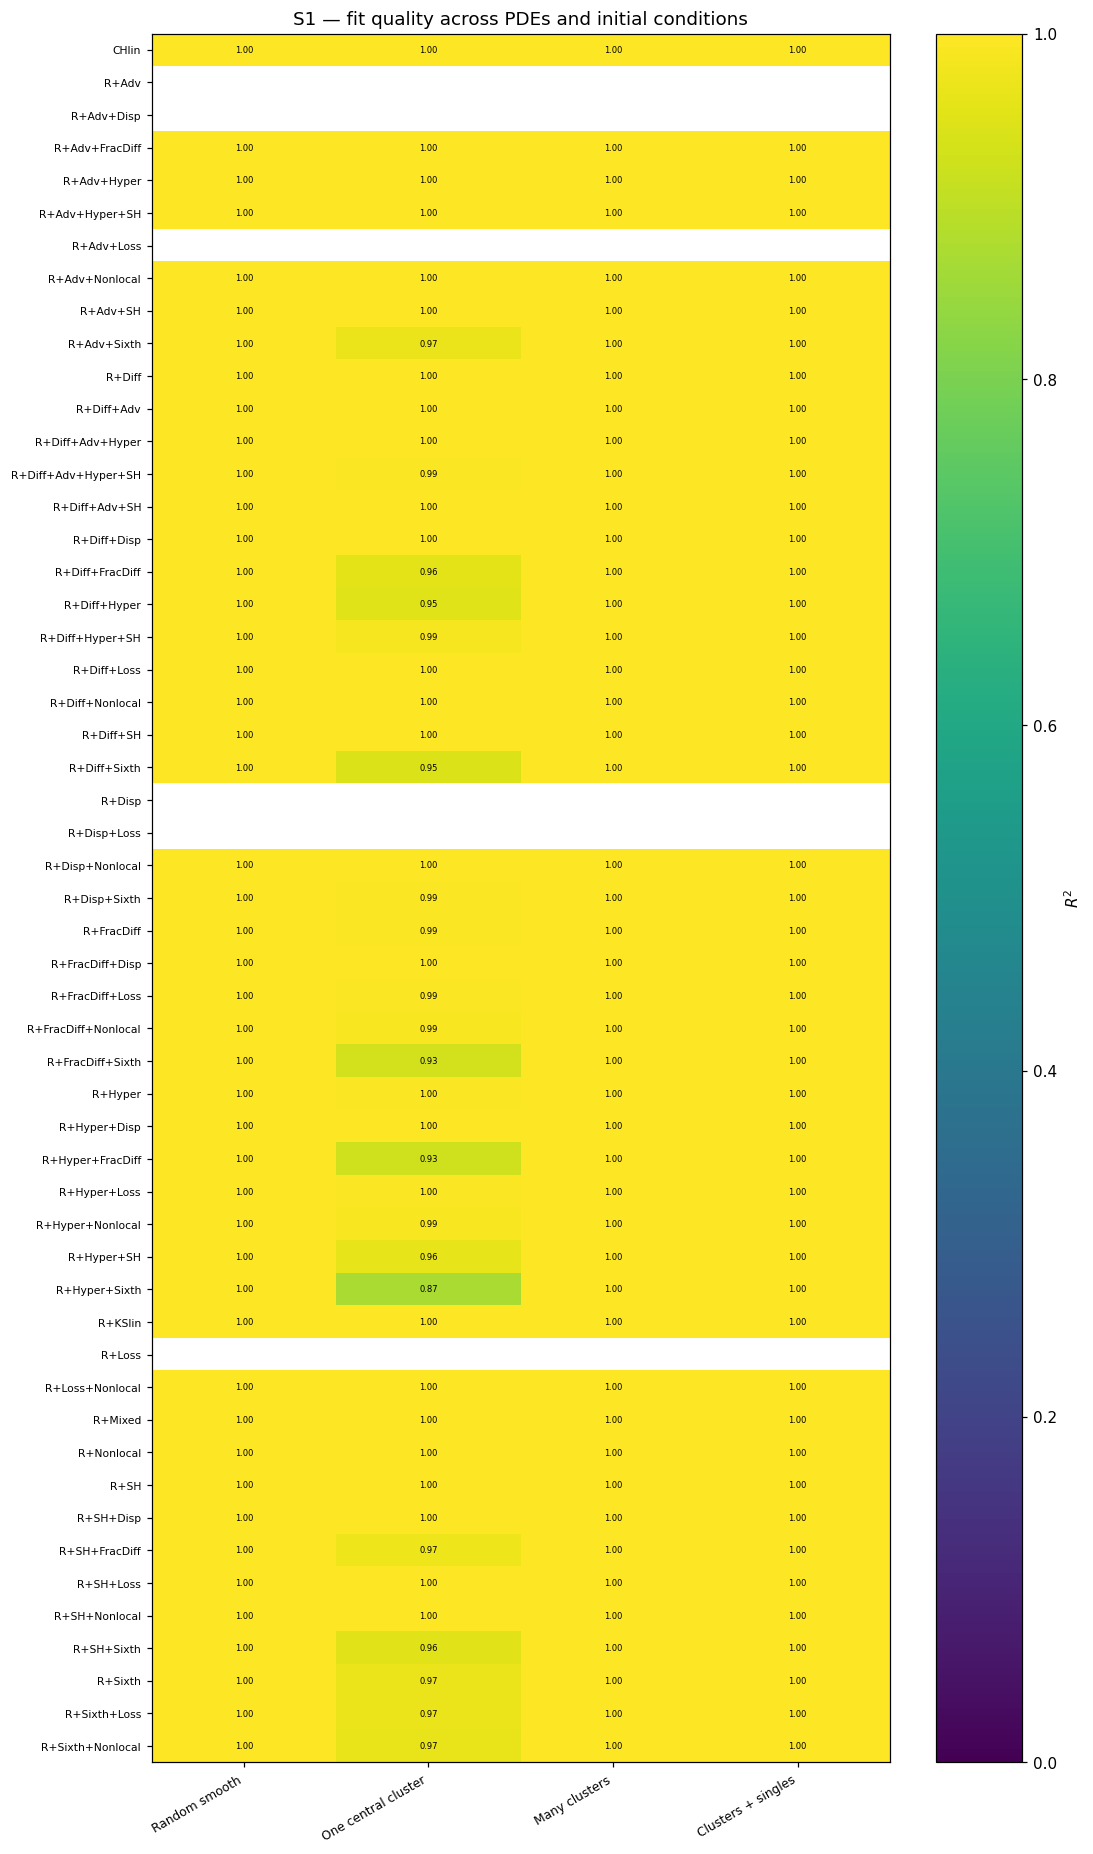

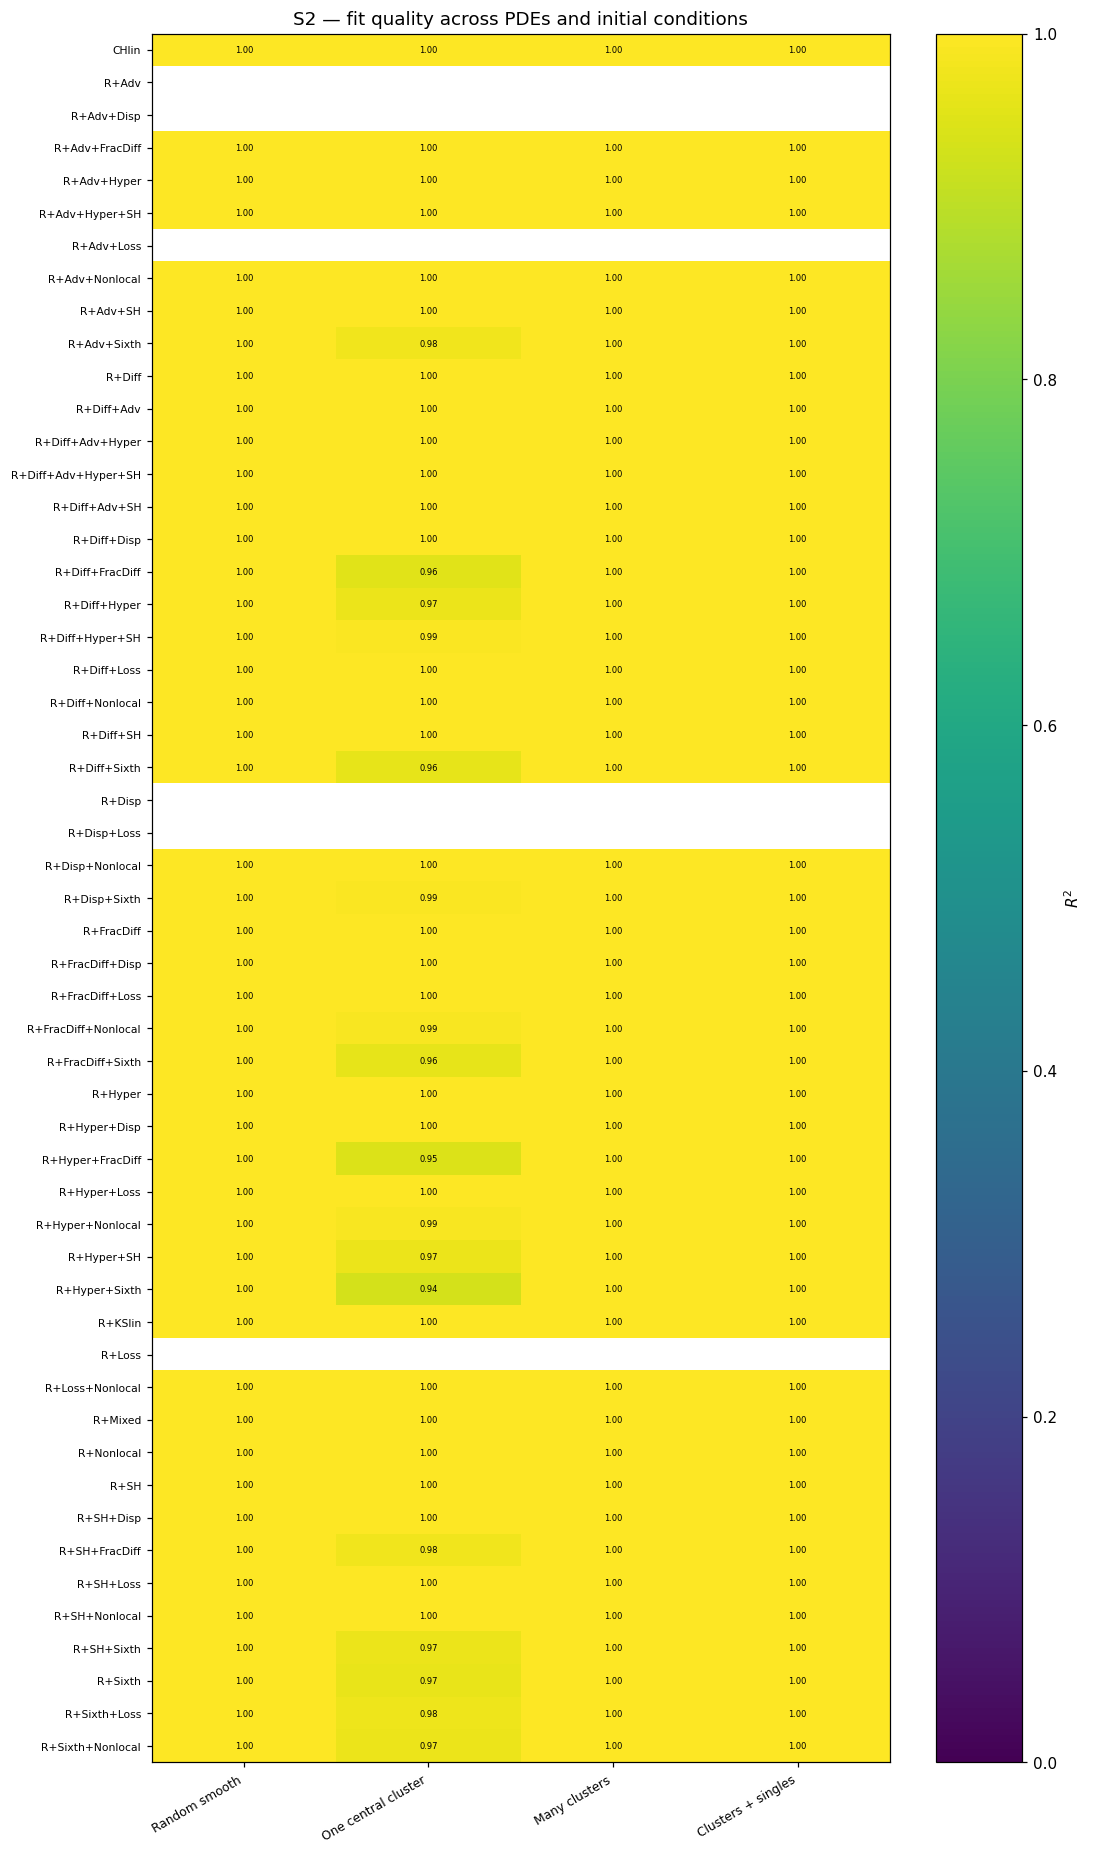

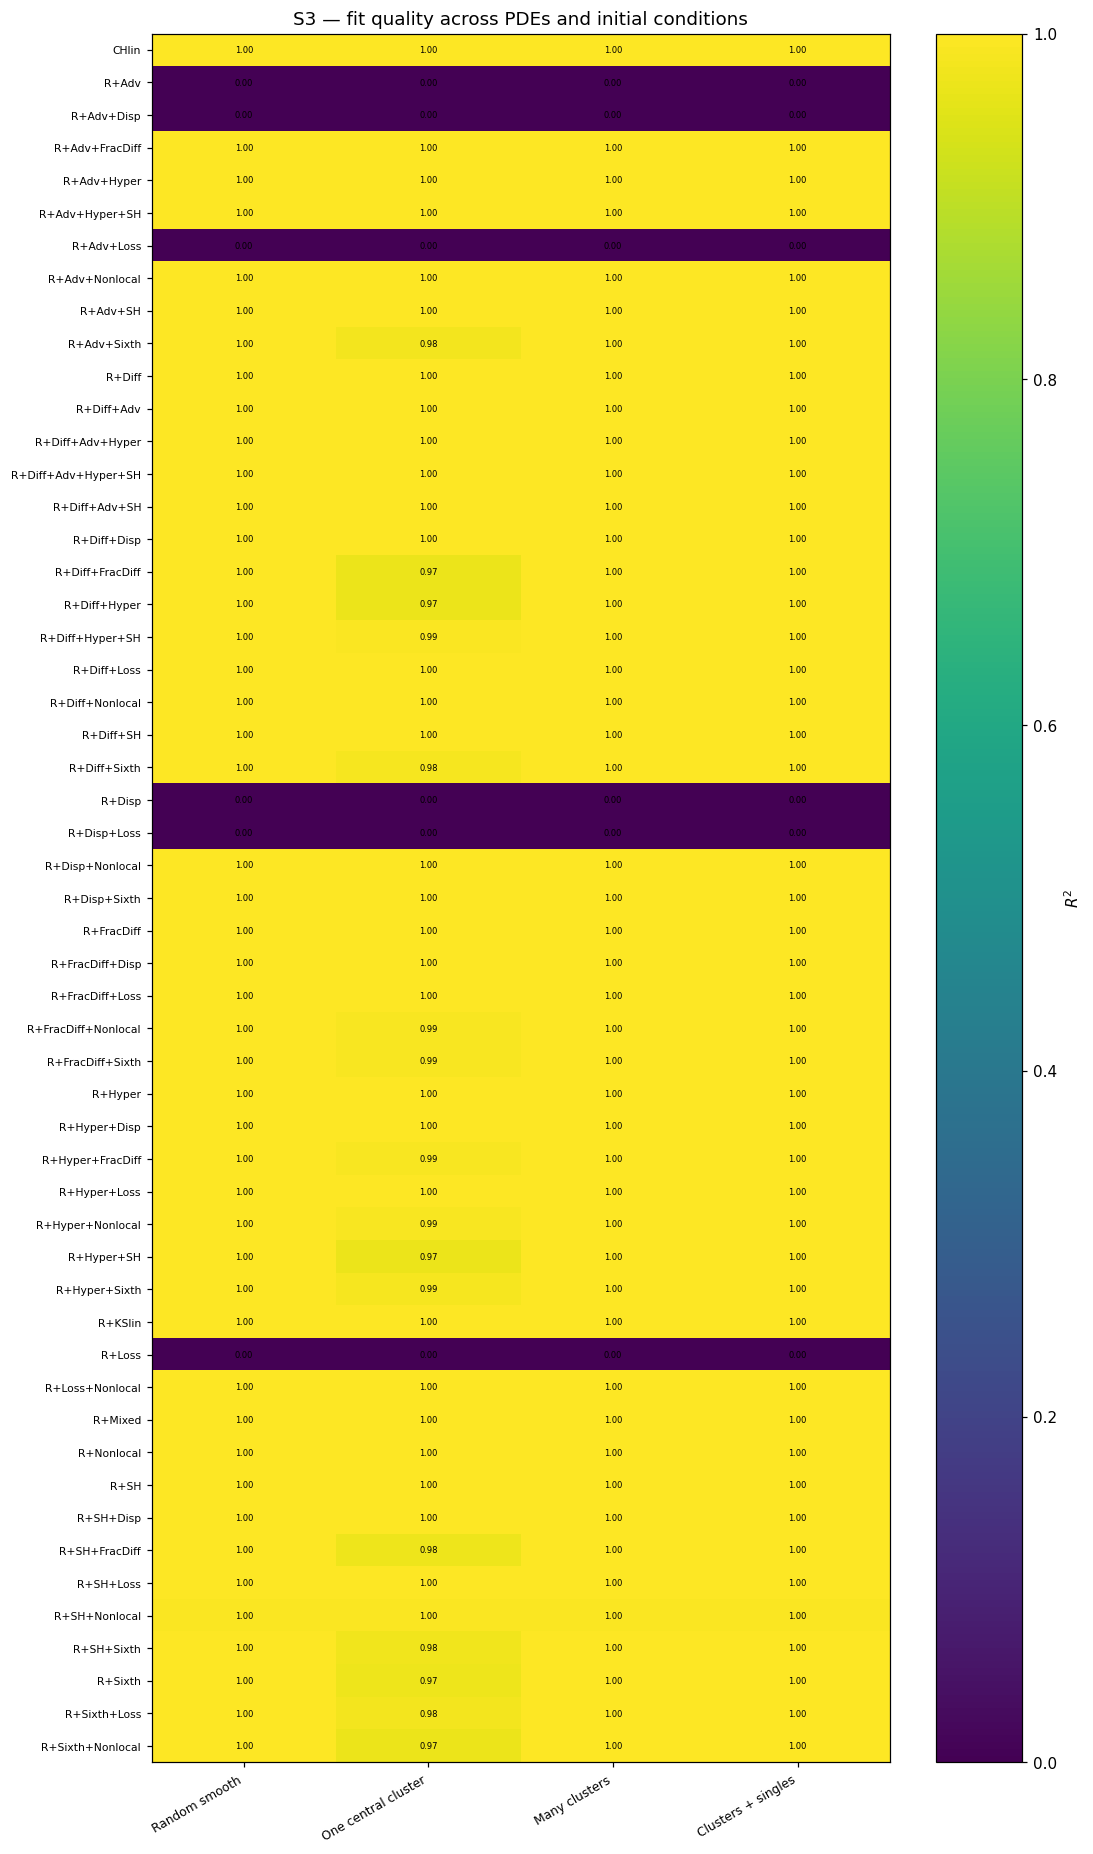

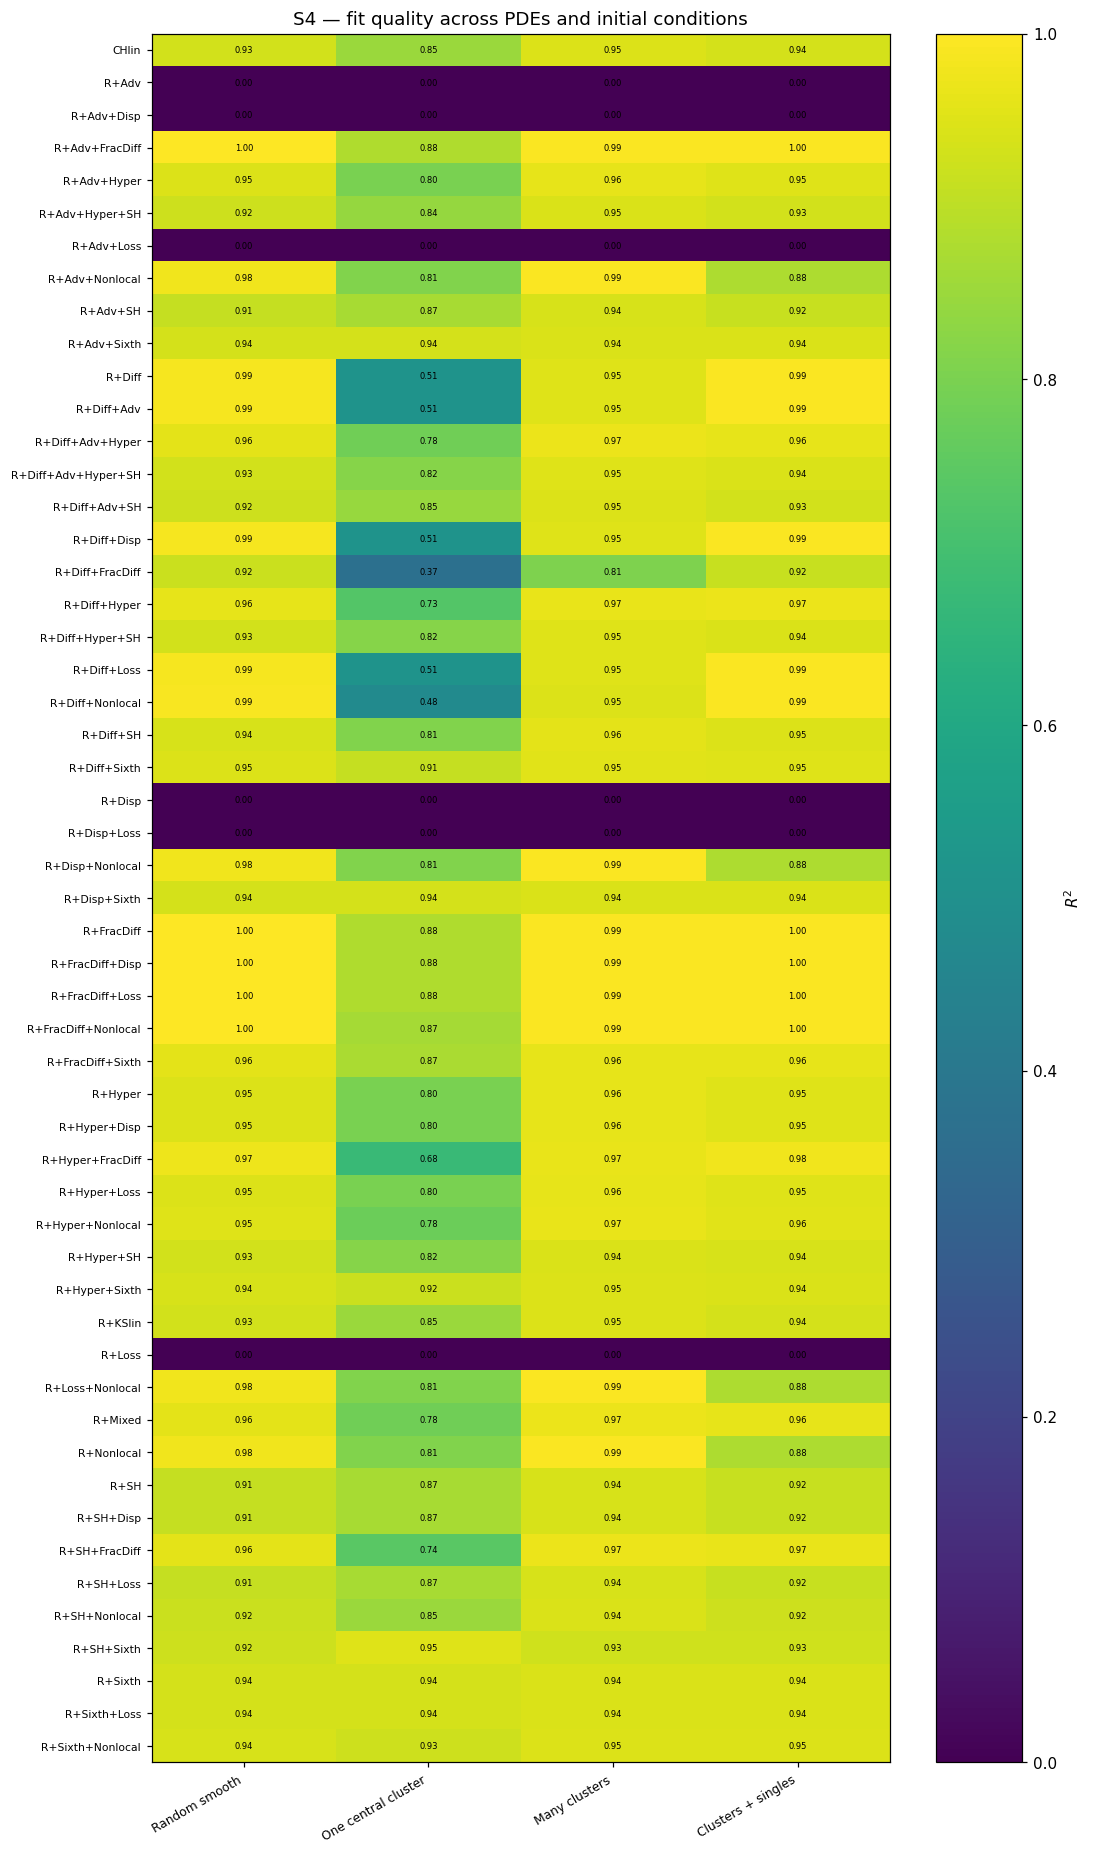

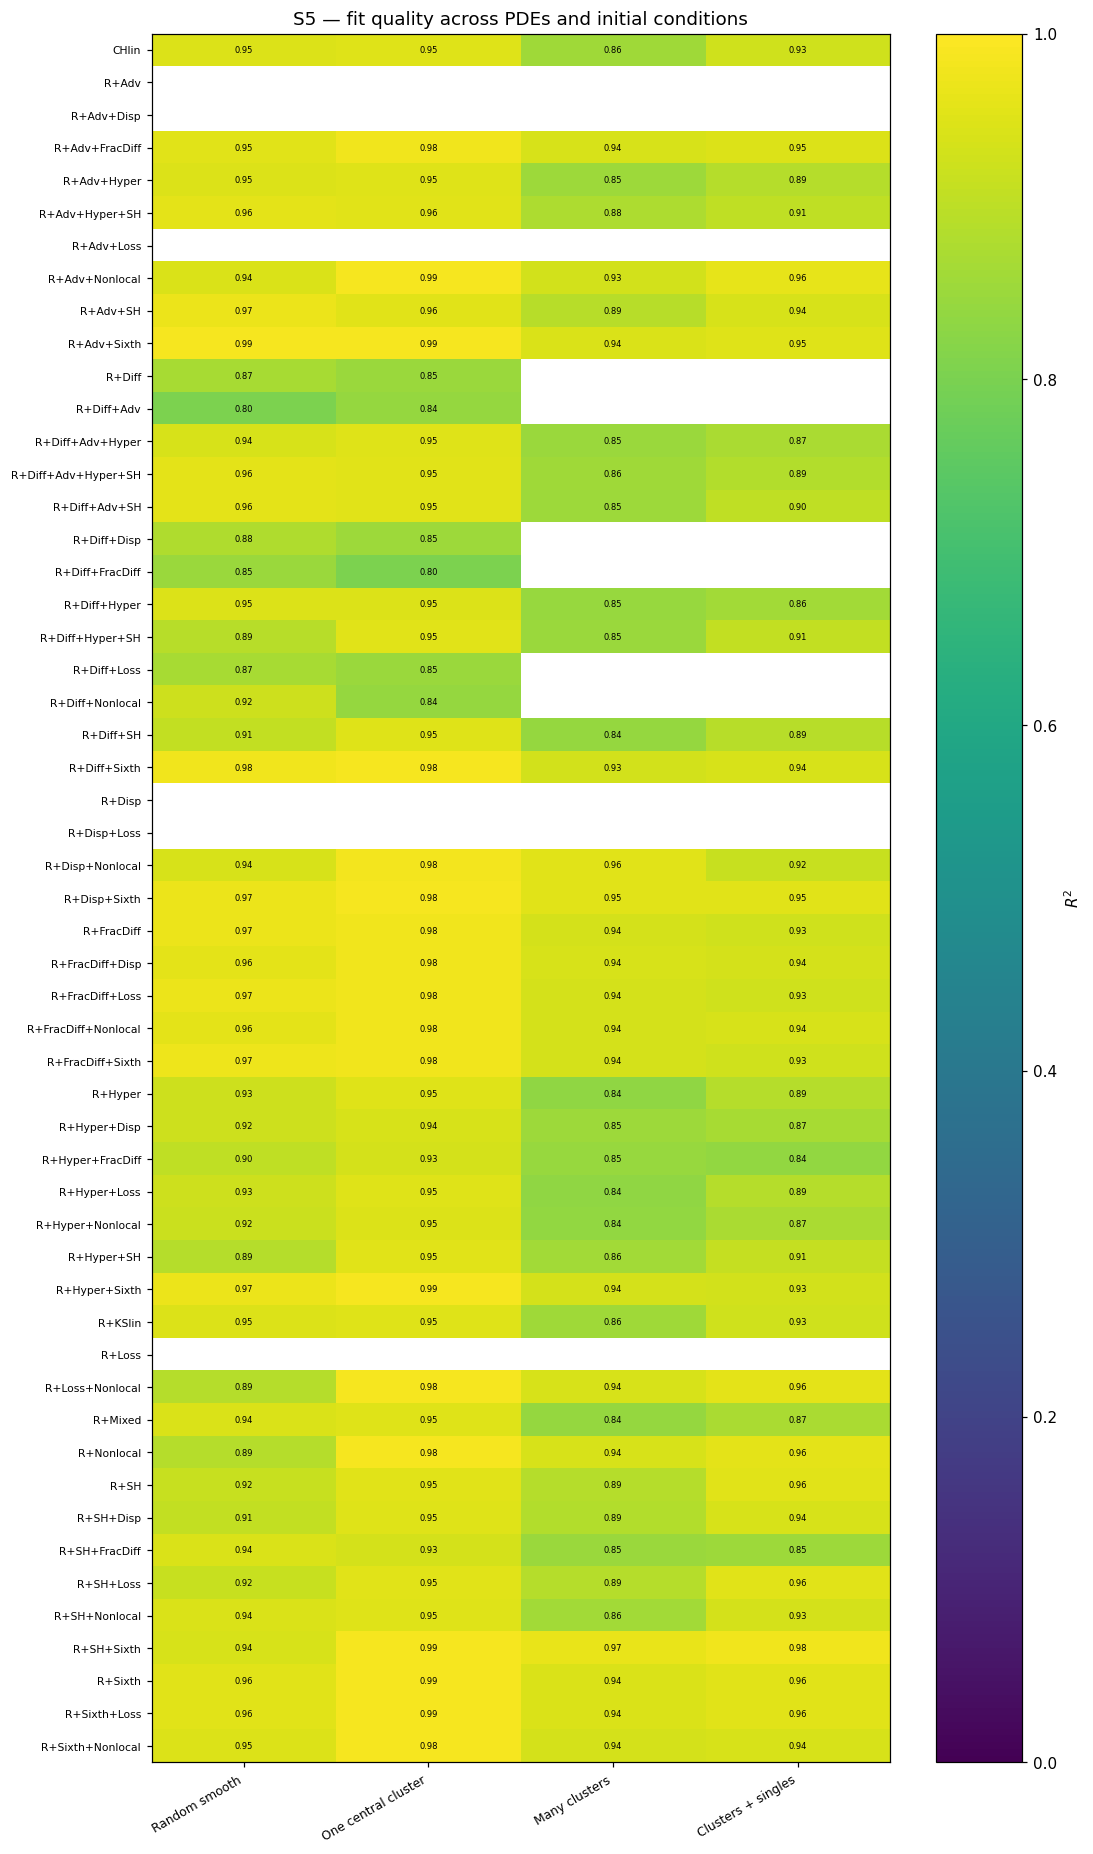

In [19]:

# ============================================================
# FINAL COMPARISON 4 — ONE HEATMAP PER SCENARIO
# ============================================================

for scen in ["S1","S2","S3","S4","S5"]:
    pivot = (
        MASTER_SUMMARY_DF[MASTER_SUMMARY_DF["Scenario"]==scen]
        .pivot(index="PDE",columns="Initial condition",values="R2")
        .reindex(columns=list(ICs.keys()))
    )

    fig,ax = plt.subplots(figsize=(10,max(10,.32*len(pivot))))
    im = ax.imshow(pivot.values,aspect="auto",vmin=0,vmax=1)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns,rotation=30,ha="right",fontsize=8)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index,fontsize=7)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v=pivot.iloc[i,j]
            if np.isfinite(v):
                ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=5.5)

    fig.colorbar(im,ax=ax,label=r"$R^2$")
    ax.set_title(f"{scen} — fit quality across PDEs and initial conditions")
    plt.tight_layout()
    plt.show()


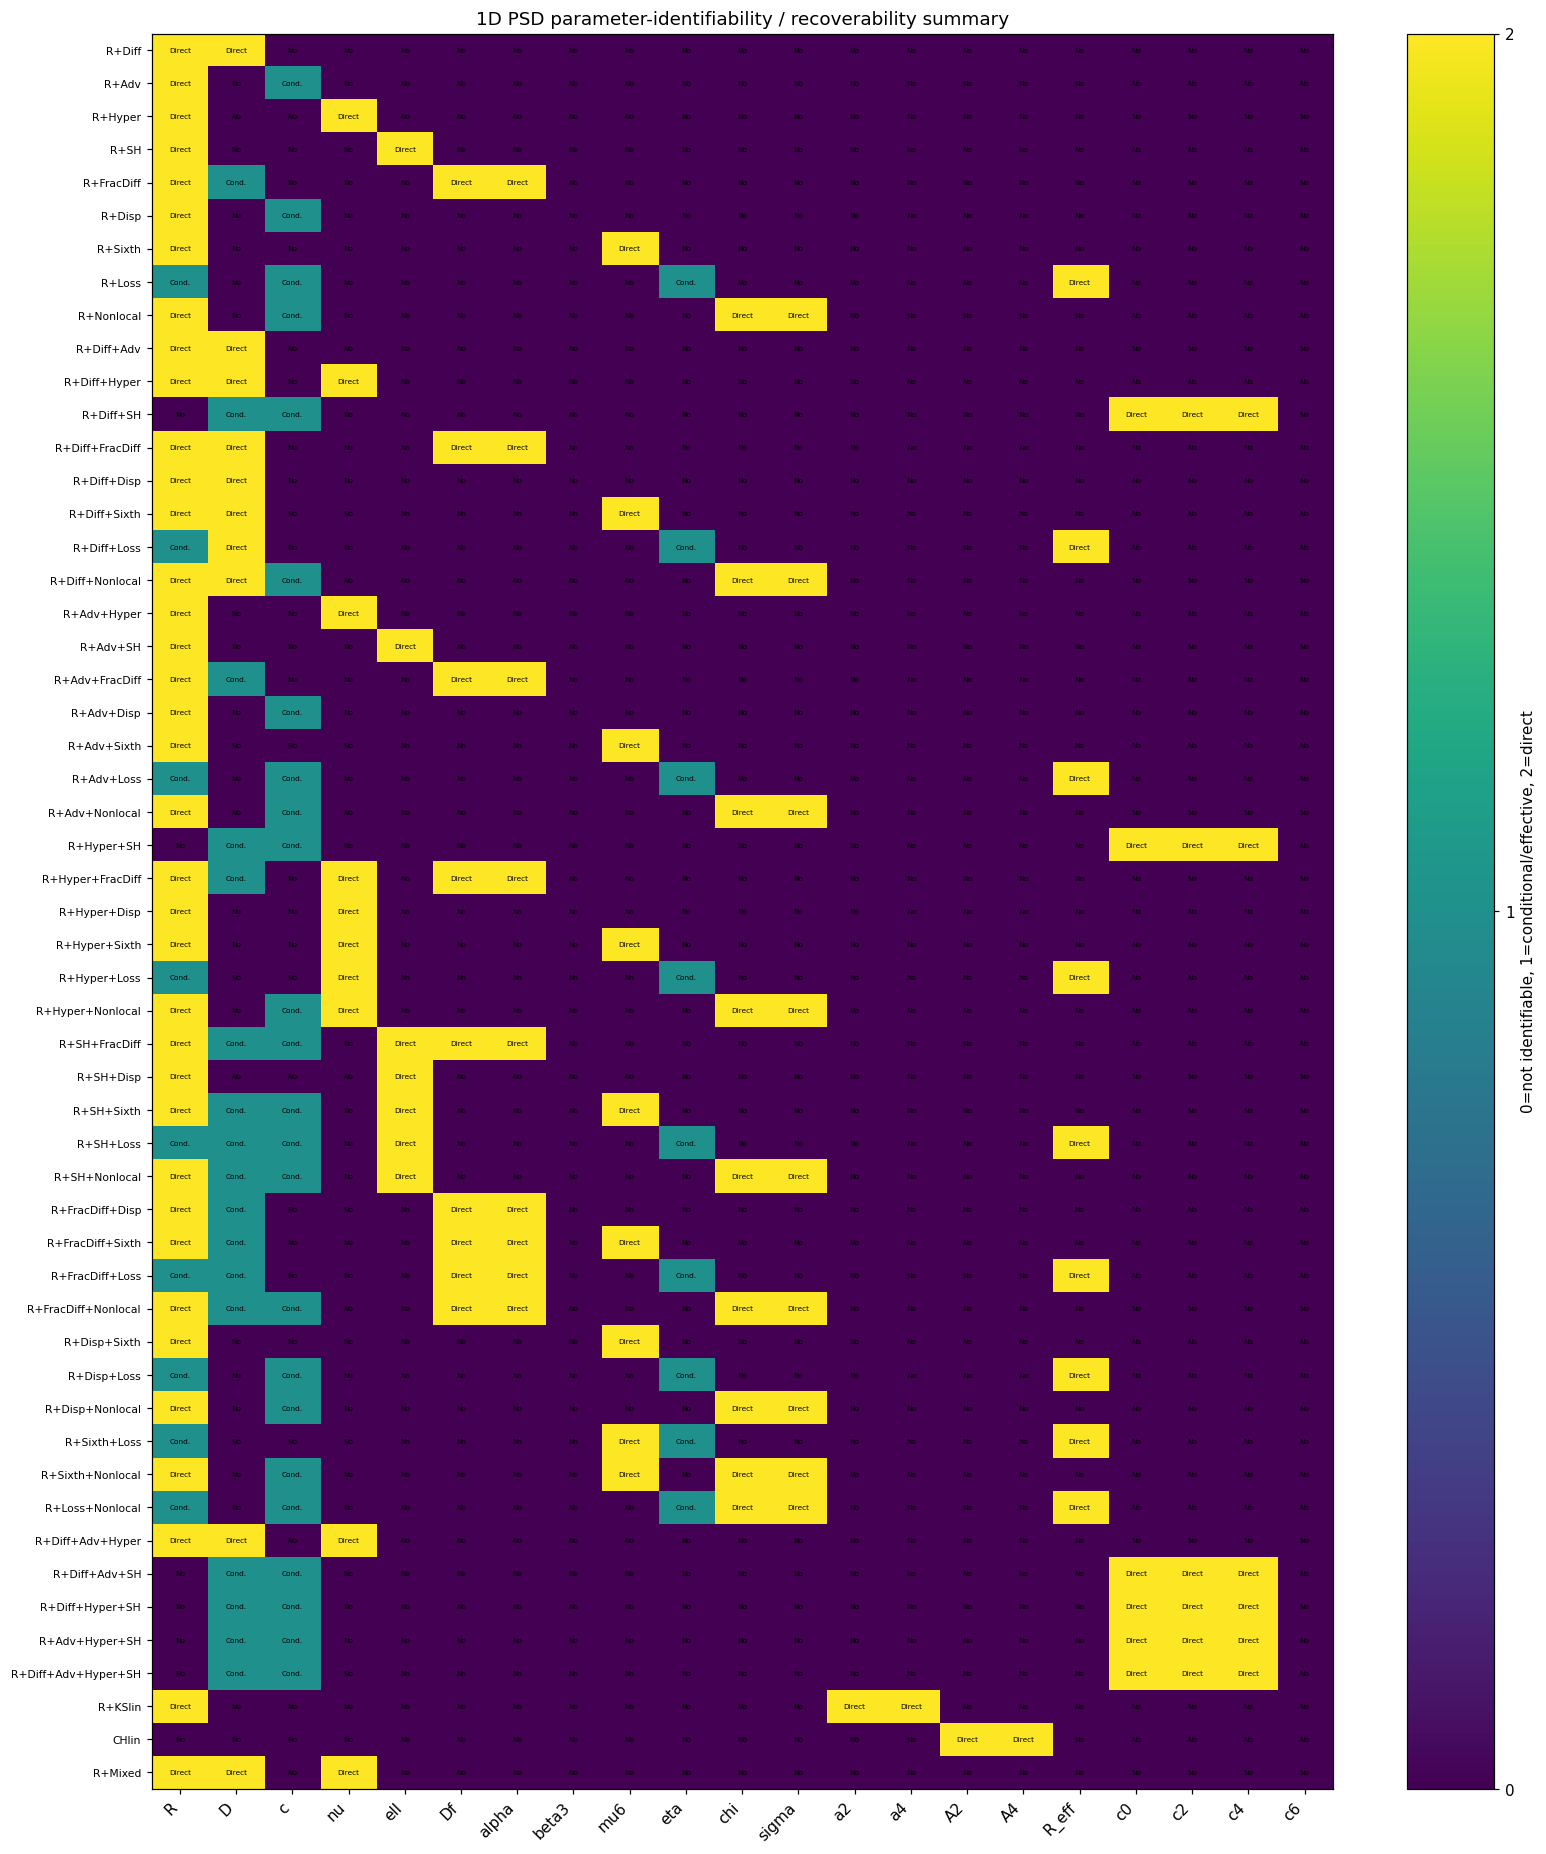

In [20]:

# ============================================================
# FINAL COMPARISON 5 — IDENTIFIABILITY / RECOVERABILITY MAP
# ============================================================

PARAM_ORDER = [
    "R","D","c","nu","ell","Df","alpha","beta3",
    "mu6","eta","chi","sigma","a2","a4","A2","A4",
    "R_eff","c0","c2","c4","c6"
]

mat = np.zeros((len(MODEL_VARIANTS),len(PARAM_ORDER)))

for i,tag in enumerate(MODEL_VARIANTS):
    direct = set(identifiable_names(tag))
    invisible = set(invisible_names(tag))
    s3_text = " ".join(identifiable_combinations_S3(tag))

    for j,p in enumerate(PARAM_ORDER):
        status = 0

        if p in direct:
            status = 2

        if p in invisible:
            status = 0

        # loss primitives only through R_eff
        if "Loss" in MODEL_LIBRARY[tag]["ops"] and p in ("R","eta"):
            status = max(status,1)

        # S3 conditional / ratio recovery
        if p in s3_text and status==0:
            status = 1

        mat[i,j]=status

fig,ax = plt.subplots(figsize=(15,max(10,.32*len(MODEL_VARIANTS))))
im = ax.imshow(mat,aspect="auto",vmin=0,vmax=2)

ax.set_xticks(np.arange(len(PARAM_ORDER)))
ax.set_xticklabels(PARAM_ORDER,rotation=45,ha="right")
ax.set_yticks(np.arange(len(MODEL_VARIANTS)))
ax.set_yticklabels(MODEL_VARIANTS,fontsize=7)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(
            j,i,
            {0:"No",1:"Cond.",2:"Direct"}[int(mat[i,j])],
            ha="center",va="center",fontsize=4.8
        )

fig.colorbar(
    im,ax=ax,ticks=[0,1,2],
    label="0=not identifiable, 1=conditional/effective, 2=direct"
)
ax.set_title("1D PSD parameter-identifiability / recoverability summary")
plt.tight_layout()
plt.show()


Initial condition,Random smooth,One central cluster,Many clusters,Clusters + singles
PDE,,,,
CHlin,0.500,1.000,0.500,0.875
R+Adv,0.000,0.000,0.000,0.000
R+Adv+Disp,0.000,0.000,0.000,0.000
R+Adv+FracDiff,0.750,1.000,1.000,1.000
R+Adv+Hyper,1.000,1.000,0.875,0.750
R+Adv+Hyper+SH,1.000,1.000,0.625,1.000
R+Adv+Loss,0.000,0.000,0.000,0.000
R+Adv+Nonlocal,0.750,1.000,1.000,0.875
R+Adv+SH,0.750,1.000,0.750,1.000


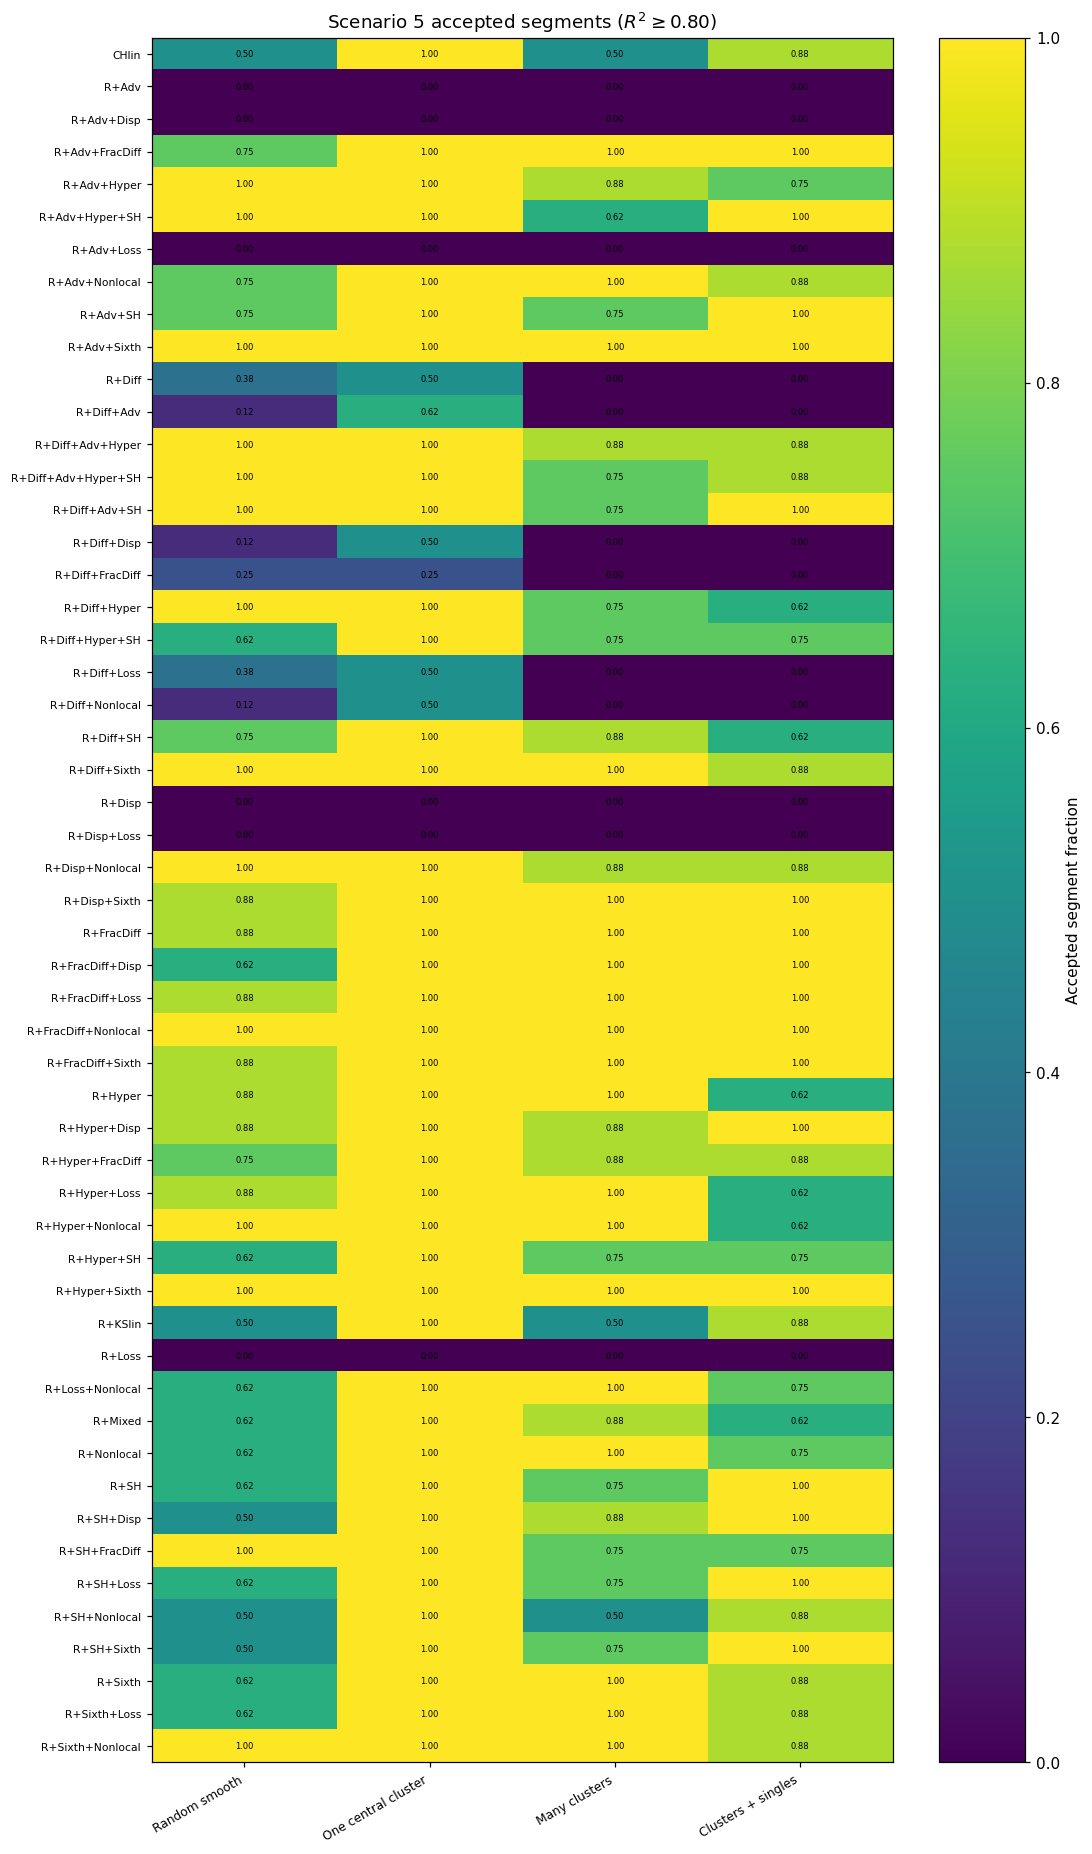

In [21]:

# ============================================================
# FINAL COMPARISON 6 — S5 ACCEPTED-SEGMENT FRACTION
# ============================================================

s5_accept_rows=[]

for tag,res in ALL_RESULTS.items():
    for ic,rr in res["S5"].items():
        if rr is None or rr.get("n_total",0)==0:
            frac=np.nan
        else:
            frac=rr["n_good"]/rr["n_total"]

        s5_accept_rows.append({
            "PDE":tag,
            "Initial condition":ic,
            "Accepted fraction":frac,
        })

S5_ACCEPT_DF=pd.DataFrame(s5_accept_rows)

pivot=S5_ACCEPT_DF.pivot(
    index="PDE",
    columns="Initial condition",
    values="Accepted fraction"
).reindex(columns=list(ICs.keys()))

display(pivot.round(3))

fig,ax=plt.subplots(figsize=(10,max(10,.32*len(pivot))))
im=ax.imshow(pivot.values,aspect="auto",vmin=0,vmax=1)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns,rotation=30,ha="right",fontsize=8)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index,fontsize=7)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v=pivot.iloc[i,j]
        if np.isfinite(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=5.5)

fig.colorbar(im,ax=ax,label="Accepted segment fraction")
ax.set_title(f"Scenario 5 accepted segments ($R^2 \\geq {R2_MIN:.2f}$)")
plt.tight_layout()
plt.show()


,Initial condition,Grid,Median log10(D/R),True log10(D/R),Error,Good segments,Total fitted segments
0,Random smooth,2,NaN,3.0621,NaN,0,2
1,Random smooth,4,NaN,3.0621,NaN,0,4
2,Random smooth,6,2.6908,3.0621,-0.3714,1,6
3,Random smooth,8,2.0305,3.0621,-1.0316,3,8
4,Random smooth,10,2.1147,3.0621,-0.9474,3,10
5,Random smooth,12,NaN,3.0621,NaN,0,0
6,Random smooth,16,NaN,3.0621,NaN,0,0
7,One central cluster,2,NaN,3.0621,NaN,0,2
8,One central cluster,4,1.9594,3.0621,-1.1027,2,4
9,One central cluster,6,1.9238,3.0621,-1.1383,2,6


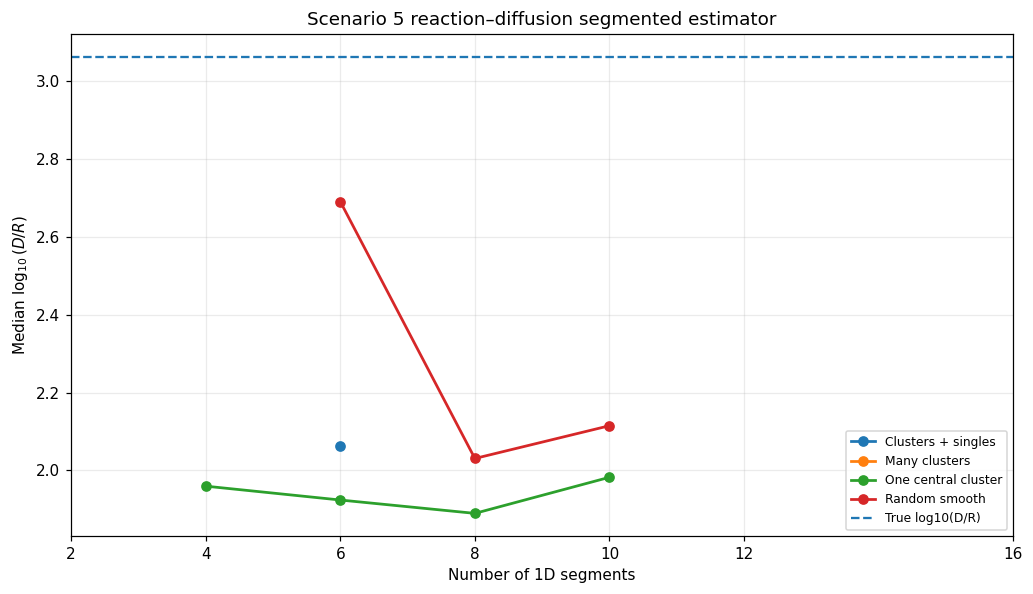

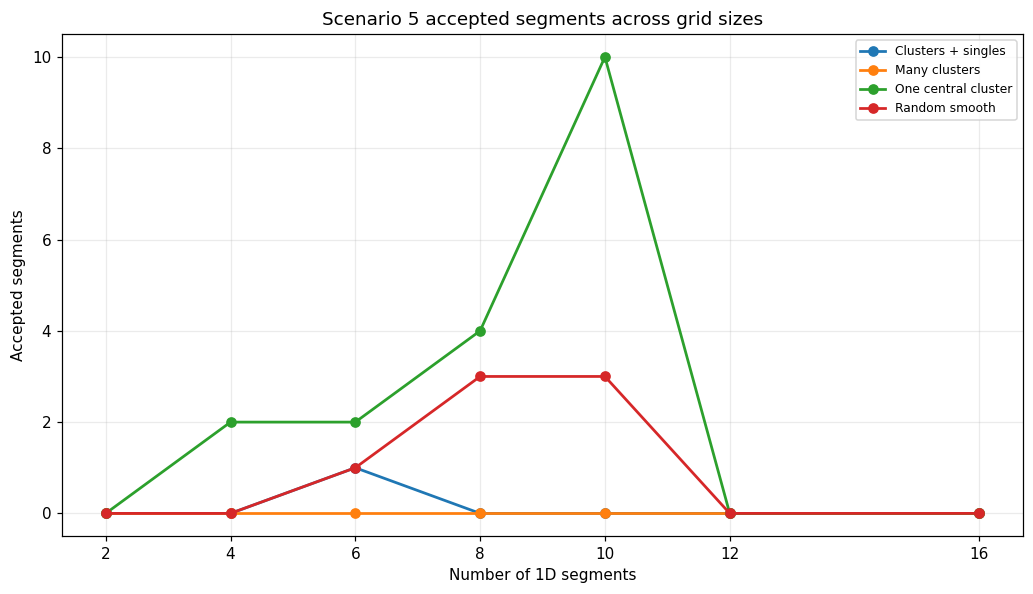

In [22]:

# ============================================================
# FINAL COMPARISON 7 — DETAILED S5 RD GRID SWEEP
# ============================================================

display(S5_RD_GRID_DF.round(4))

fig,ax=plt.subplots(figsize=(9.5,5.5))

for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    grp=grp.sort_values("Grid")
    ax.plot(
        grp["Grid"],
        grp["Median log10(D/R)"],
        marker="o",
        linewidth=1.8,
        label=ic
    )

ax.axhline(
    TRUE_LOG10_DR,
    linestyle="--",
    linewidth=1.5,
    label="True log10(D/R)"
)

ax.set_xlabel("Number of 1D segments")
ax.set_ylabel(r"Median $\log_{10}(D/R)$")
ax.set_xticks(GRID_LIST)
ax.grid(alpha=.25)
ax.legend(fontsize=8)
ax.set_title("Scenario 5 reaction–diffusion segmented estimator")
plt.tight_layout()
plt.show()

# Accepted-segment count by grid
fig,ax=plt.subplots(figsize=(9.5,5.5))

for ic,grp in S5_RD_GRID_DF.groupby("Initial condition"):
    grp=grp.sort_values("Grid")
    ax.plot(
        grp["Grid"],
        grp["Good segments"],
        marker="o",
        linewidth=1.8,
        label=ic
    )

ax.set_xlabel("Number of 1D segments")
ax.set_ylabel("Accepted segments")
ax.set_xticks(GRID_LIST)
ax.grid(alpha=.25)
ax.legend(fontsize=8)
ax.set_title("Scenario 5 accepted segments across grid sizes")
plt.tight_layout()
plt.show()


In [23]:

# ============================================================
# FINAL COMPARISON 8 — SCENARIO-SPECIFIC RANKING TABLES
# ============================================================

SCENARIO_RANKINGS={}

for scen in ["S1","S2","S3","S4","S5"]:
    rank = (
        MASTER_SUMMARY_DF[MASTER_SUMMARY_DF["Scenario"]==scen]
        .groupby("PDE",as_index=False)["R2"]
        .median()
        .rename(columns={"R2":"Median_R2"})
        .sort_values("Median_R2",ascending=False)
        .reset_index(drop=True)
    )

    rank["Rank"]=np.arange(1,len(rank)+1)
    SCENARIO_RANKINGS[scen]=rank[["Rank","PDE","Median_R2"]]

    print(f"\n{scen} ranking:")
    display(SCENARIO_RANKINGS[scen].head(20))

# Known-time recovery ranking using parameter error
KNOWN_TIME_RANKING = (
    PARAM_ERROR_DF
    .pivot(index="PDE",columns="Scenario",values="MedianAbsPercentError")
    .reindex(columns=["S1","S2"])
)

KNOWN_TIME_RANKING["MedianKnownTimeError"] = KNOWN_TIME_RANKING.median(axis=1)
KNOWN_TIME_RANKING = KNOWN_TIME_RANKING.sort_values("MedianKnownTimeError")

print("Known-time parameter-recovery ranking:")
display(KNOWN_TIME_RANKING.head(25).round(3))



S1 ranking:


,Rank,PDE,Median_R2
0,1,CHlin,1.0
1,2,R+Adv+FracDiff,1.0
2,3,R+Adv+Hyper,1.0
3,4,R+Adv+Hyper+SH,1.0
4,5,R+Adv+Nonlocal,1.0
5,6,R+Adv+SH,1.0
6,7,R+Adv+Sixth,1.0
7,8,R+Diff,1.0
8,9,R+Diff+Adv,1.0
9,10,R+Diff+Adv+Hyper,1.0



S2 ranking:


,Rank,PDE,Median_R2
0,1,CHlin,1.0
1,2,R+Adv+FracDiff,1.0
2,3,R+Adv+Hyper,1.0
3,4,R+Adv+Hyper+SH,1.0
4,5,R+Adv+Nonlocal,1.0
5,6,R+Adv+SH,1.0
6,7,R+Adv+Sixth,1.0
7,8,R+Diff,1.0
8,9,R+Diff+Adv,1.0
9,10,R+Diff+Adv+Hyper,1.0



S3 ranking:


...

,Rank,PDE,Median_R2
0,1,R+FracDiff,0.994994
1,2,R+FracDiff+Loss,0.994980
2,3,R+Adv+FracDiff,0.994945
3,4,R+FracDiff+Disp,0.994881
4,5,R+FracDiff+Nonlocal,0.994245
5,6,R+Diff+Loss,0.969772
6,7,R+Hyper+FracDiff,0.969629
7,8,R+Diff,0.969569
8,9,R+Diff+Adv,0.969482
9,10,R+Diff+Disp,0.969404



S5 ranking:


,Rank,PDE,Median_R2
0,1,R+SH+Sixth,0.972834
1,2,R+Adv+Sixth,0.969120
2,3,R+Disp+Sixth,0.962967
3,4,R+Diff+Sixth,0.957756
4,5,R+Sixth,0.955909
5,6,R+Sixth+Loss,0.955909
6,7,R+FracDiff+Sixth,0.955041
7,8,R+FracDiff,0.954339
8,9,R+FracDiff+Loss,0.954339
9,10,R+Hyper+Sixth,0.953658


Known-time parameter-recovery ranking:


Scenario,S1,S2,MedianKnownTimeError
PDE,,,
R+Adv+Disp,0.0,0.0,0.0
R+Adv+Nonlocal,0.0,0.0,0.0
R+Disp+Nonlocal,0.0,0.0,0.0
R+Adv,0.0,0.0,0.0
R+Disp+Loss,0.0,0.0,0.0
R+Disp,0.0,0.0,0.0
R+SH+Disp,0.0,0.0,0.0
R+Adv+Loss,0.0,0.0,0.0
R+Adv+SH,0.0,0.0,0.0



# 16. Final summary tables and exports

The notebook now ends with both numeric tables and the complete plotting set.

The main outputs are:

- `MASTER_SUMMARY_DF`: every PDE × scenario × IC;
- `MASTER_R2_MATRIX`: one row per PDE × IC with S1–S5 columns;
- `PDE_SCENARIO_MEDIAN_R2`: one row per PDE, median over the four ICs;
- `PARAM_ERROR_DF`: known-time S1/S2 recovery errors;
- `S5_ACCEPT_DF`: Scenario-5 accepted-segment fractions;
- `S5_RD_GRID_DF`: detailed reaction–diffusion segmentation sweep;
- `SCENARIO_RANKINGS`: separate PDE rankings for each scenario.

The scenario-specific rankings are kept separate because the meaning of \(R^2\) differs between S1–S3, S4, and S5.


In [24]:

# ============================================================
# FINAL EXPORT CELL
# ============================================================

MASTER_SUMMARY_DF.to_csv(
    "MASTER2_1D_ALL_PDEs_ALL_5_SCENARIOS_tidy.csv",
    index=False
)

MASTER_R2_MATRIX.to_csv(
    "MASTER2_1D_ALL_PDEs_R2_matrix.csv"
)

PDE_SCENARIO_MEDIAN_R2.to_csv(
    "MASTER2_1D_PDE_scenario_median_R2.csv"
)

PARAM_ERROR_DF.to_csv(
    "MASTER2_1D_known_time_parameter_error_long.csv",
    index=False
)

S5_ACCEPT_DF.to_csv(
    "MASTER2_1D_S5_accepted_segment_fraction.csv",
    index=False
)

S5_RD_GRID_DF.to_csv(
    "MASTER2_1D_S5_RD_grid_sweep.csv",
    index=False
)

for scen,df in SCENARIO_RANKINGS.items():
    df.to_csv(
        f"MASTER2_1D_{scen}_ranking.csv",
        index=False
    )

print("Complete 1D notebook outputs exported.")


Complete 1D notebook outputs exported.
